In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/Hp/Downloads/Regulatory Affairs of Road Accident Data 2020 India.csv")

In [3]:
df.head()

,Million Plus Cities,Cause category,Cause Subcategory,Outcome of Incident,Count
0,Agra,Traffic Control,Flashing Signal/Blinker,Greviously Injured,0.0
1,Agra,Traffic Control,Flashing Signal/Blinker,Minor Injury,0.0
2,Agra,Traffic Control,Flashing Signal/Blinker,Persons Killed,0.0
3,Agra,Traffic Control,Flashing Signal/Blinker,Total Injured,0.0
4,Agra,Traffic Control,Flashing Signal/Blinker,Total number of Accidents,0.0


In [4]:
df.shape

(9550, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9550 entries, 0 to 9549
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Million Plus Cities  9550 non-null   object 
 1   Cause category       9550 non-null   object 
 2   Cause Subcategory    9550 non-null   object 
 3   Outcome of Incident  9550 non-null   object 
 4   Count                9547 non-null   float64
dtypes: float64(1), object(4)
memory usage: 373.2+ KB


In [6]:
df["Outcome of Incident"].value_counts()

Outcome of Incident
Greviously Injured           2000
Minor Injury                 2000
Persons Killed               2000
Total number of Accidents    2000
Total Injured                1550
Name: count, dtype: int64

In [7]:
#Display all column names
df.columns

Index(['Million Plus Cities', 'Cause category', 'Cause Subcategory',
       'Outcome of Incident', 'Count'],
      dtype='object')

In [8]:
#Rename the columns
df.rename(columns= {"Million Plus Cities" : "million_plus_cities", "Cause category" : "cause_category", "Cause Subcategory" : "cause_subcategory", "Outcome of Incident" : "outcome_of_incident", "Count" : "count"}, inplace=True)

In [9]:
df.columns

Index(['million_plus_cities', 'cause_category', 'cause_subcategory',
       'outcome_of_incident', 'count'],
      dtype='object')

In [10]:
#Select only categorical columns
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['million_plus_cities', 'cause_category', 'cause_subcategory',
       'outcome_of_incident'],
      dtype='object')

In [11]:
#Display their uniqye values and their count
for column in cat_cols:
    print(column, ": ", len(df[column].unique()), df[column].unique())

million_plus_cities :  50 ['Agra' 'Ahmedabad' 'Allahabad(Prayagraj)' 'Amritsar' 'Asansol Durgapur'
 'Aurangabad' 'Bengaluru' 'Bhopal' 'Chandigarh' 'Chennai' 'Coimbatore'
 'Delhi' 'Dhanbad' 'Faridabad' 'Ghaziabad' 'Gwalior' 'Hyderabad' 'Indore'
 'Jabalpur' 'Jaipur' 'Jamshedpur' 'Jodhpur' 'Kannur' 'Kanpur' 'Khozikode'
 'Kochi' 'Kolkata' 'Kollam' 'Kota' 'Lucknow' 'Ludhiana' 'Madurai'
 'Mallapuram' 'Meerut' 'Mumbai' 'Nagpur' 'Nashik' 'Patna' 'Pune' 'Raipur'
 'Rajkot' 'Srinagar' 'Surat' 'Thiruvanthapuram' 'Thrissur'
 'Tiruchirapalli' 'Vadodra' 'Varanasi' 'Vijaywada city' 'Vizaq']
cause_category :  6 ['Traffic Control' 'Junction' 'Traffic Violation' 'Road Features'
 'Impacting Vehicle/Object' 'Weather']
cause_subcategory :  35 ['Flashing Signal/Blinker' 'Others' 'Police Controlled' 'Stop Sign'
 'Traffic Light Signal' 'Uncontrolled' 'Four arm Junction'
 'Round about Junction' 'Staggered Junction' 'T' 'Y'
 'Driving on Wrong side'
 'Drunken Driving/ Consumption of alcohol and drug' 'Jumping Red

Handling Missing Values

In [12]:
#check for null values
df.isnull().sum()

million_plus_cities    0
cause_category         0
cause_subcategory      0
outcome_of_incident    0
count                  3
dtype: int64

In [13]:
#Display the data with null values
df[df['count'].isnull()]

,million_plus_cities,cause_category,cause_subcategory,outcome_of_incident,count
7056,Gwalior,Impacting Vehicle/Object,Other Non,Greviously Injured,NaN
7057,Gwalior,Impacting Vehicle/Object,Other Non,Persons Killed,NaN
7058,Gwalior,Impacting Vehicle/Object,Other Non,Minor Injury,NaN


In [14]:
df.loc[df['count'].isnull(), 'count'] = 0

In [15]:
df.to_csv("Regulatory_Affairs_of Road_Accident_Data_2020_India.csv", index=False)

Data Analysis and Visualisation

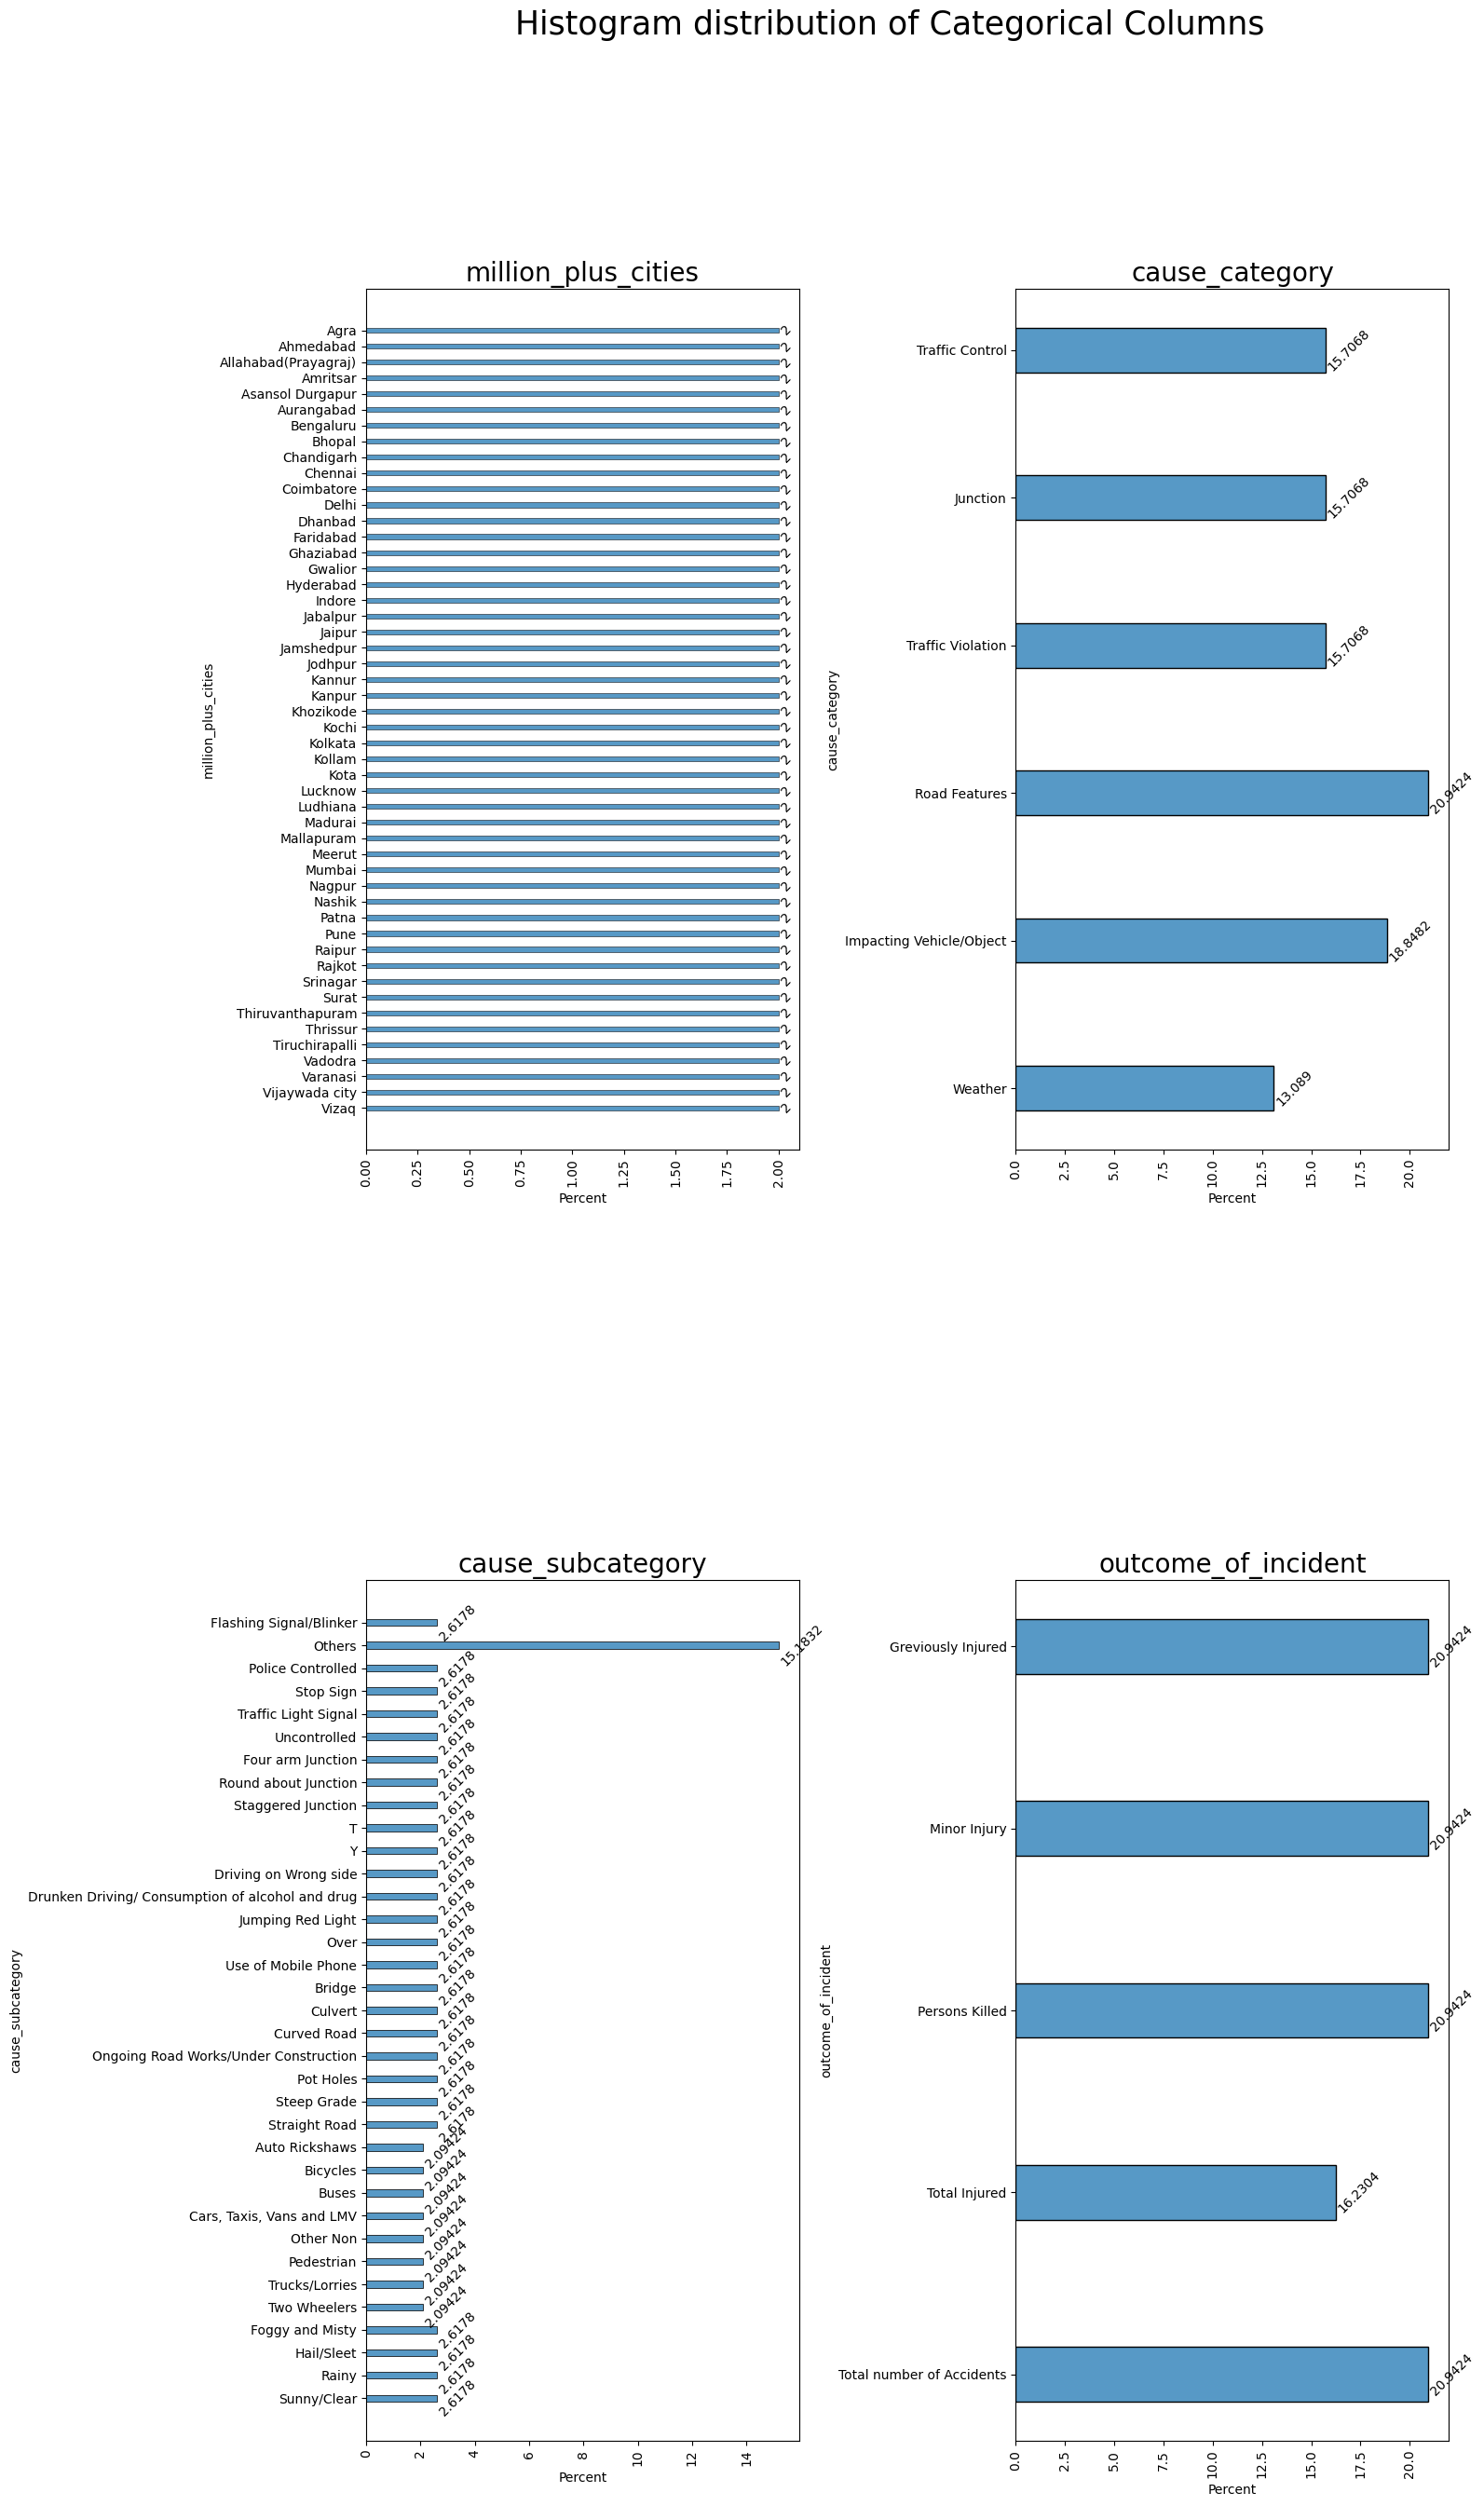

In [16]:
plt.figure(figsize=(15,30))
plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.suptitle("Histogram distribution of Categorical Columns", fontsize = 25)

#we want to have 2 columns
ncols = 2

#Calculate number of rows
nrows = len(cat_cols) // ncols + (1 if len(cat_cols) % ncols > 0 else 0)

#plot histogarm distribution of the categorical columns
for n, column in enumerate(cat_cols):
    ax = plt.subplot(nrows, ncols, n+1)
    ax.set_title(column, fontsize=20)

    sns.histplot(data=df, y=column, multiple="dodge", shrink=0.3, ax=ax, stat="percent")

    for container in ax.containers:
        #Display labels for each container/bar
        ax.bar_label(container, rotation=45)

    #set x labels rotation for each plot
    plt.xticks(rotation=90)

Analysis : Total number of Accidents

In [17]:
#Category count - Total number of Accidents w.r.t Location
total_accidents_mask = df[df['outcome_of_incident'] =="Total number of Accidents"]

Bar Chart Distribution of total number of accidents in India

<Figure size 5000x1500 with 0 Axes>

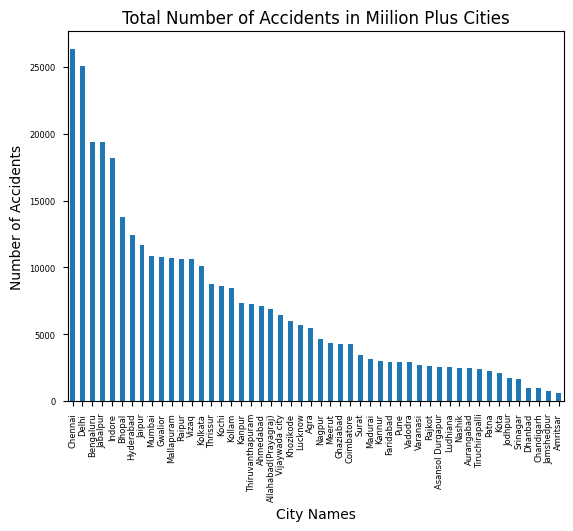

In [18]:
plt.figure(figsize=(50,15))

#Group by cities w.r.t outcome : Total number of Accidents
cat_grp_accidents = total_accidents_mask.groupby(['million_plus_cities']).agg('sum')[['count']].sort_values(by='count', ascending=False)

#Create a Barplot of Total Number of Accidents w.r.t cities
cat_grp_accidents.plot(kind="bar", legend=False, title="Total Number of Accidents in Miilion Plus Cities", xlabel='City Names', ylabel="Number of Accidents")

plt.tick_params(pad=5, labelsize=6)
plt.show()



Percentage Distribution of total number of accidents across cities 

In [19]:
#Calculate % of accidents w.r.t cities
cat_grp_accidents = cat_grp_accidents.reset_index()
cat_grp_accidents['percentage'] = (cat_grp_accidents['count'] / cat_grp_accidents['count'].sum()) * 100
cat_grp_accidents

,million_plus_cities,count,percentage
0,Chennai,26334.0,7.472419
1,Delhi,25068.0,7.113184
2,Bengaluru,19398.0,5.504290
3,Jabalpur,19356.0,5.492373
4,Indore,18216.0,5.168891
5,Bhopal,13770.0,3.907314
6,Hyderabad,12384.0,3.514029
7,Jaipur,11640.0,3.302915
8,Mumbai,10872.0,3.084990
9,Gwalior,10794.0,3.062858


Study w.r.t cause category and subcategory


In [20]:
accidents_subcat_labels = total_accidents_mask['cause_subcategory'].unique()

<Figure size 5000x2000 with 0 Axes>

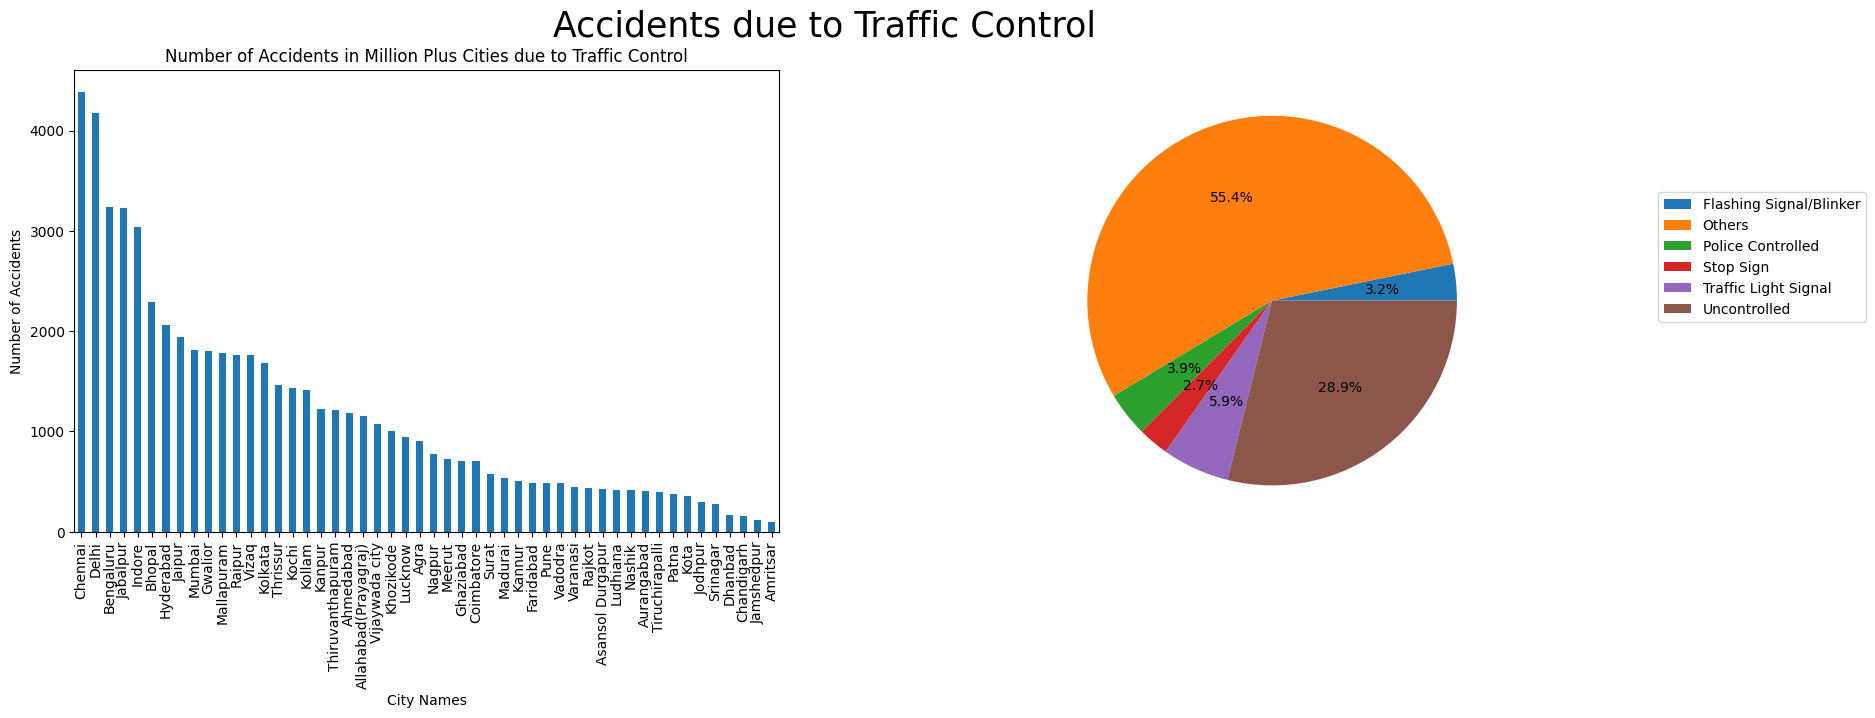

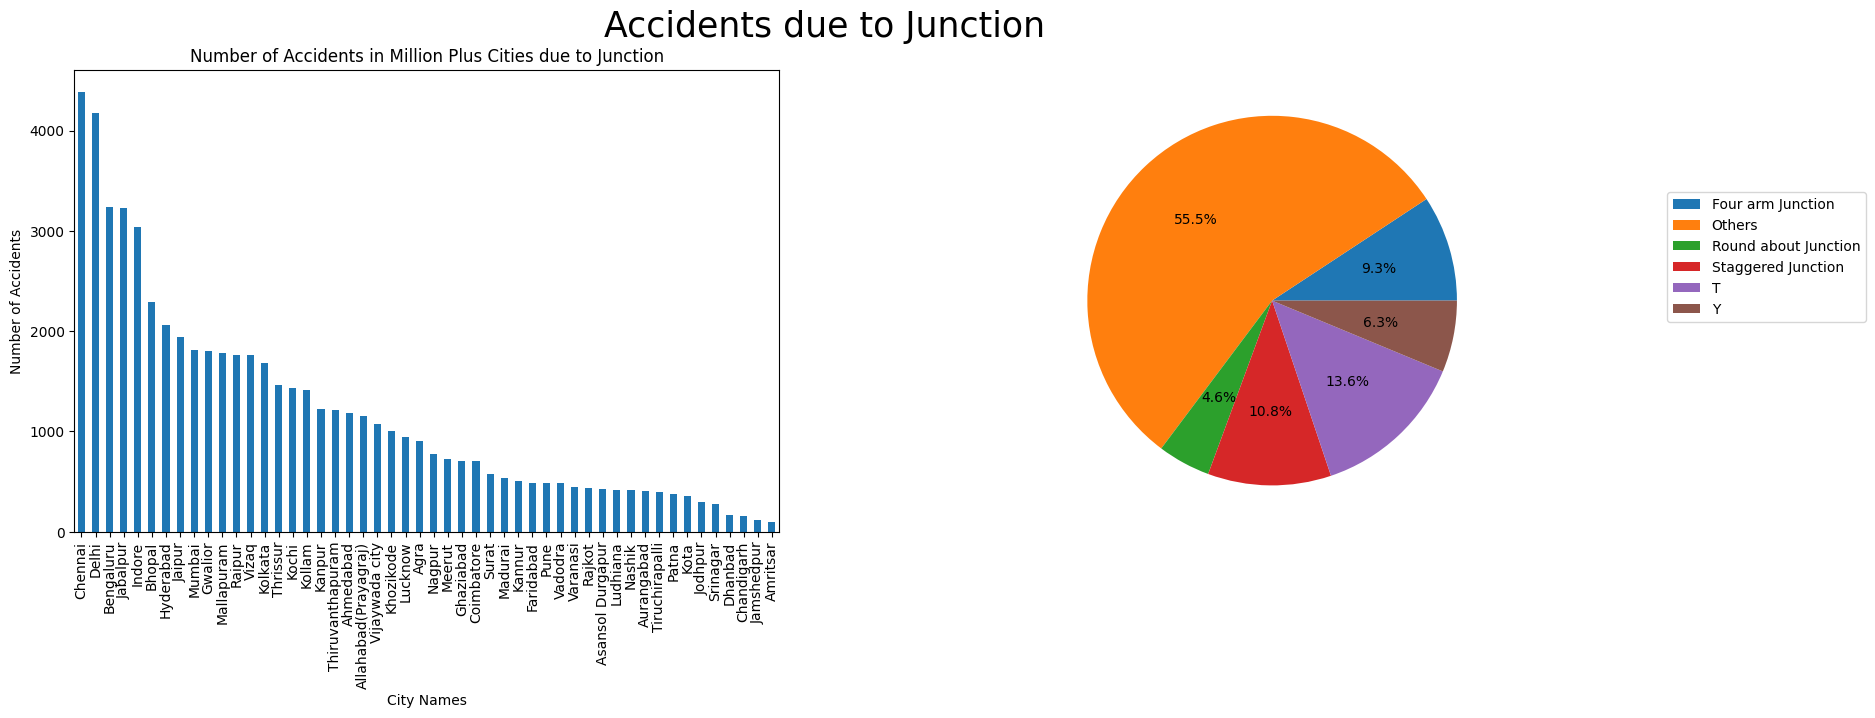

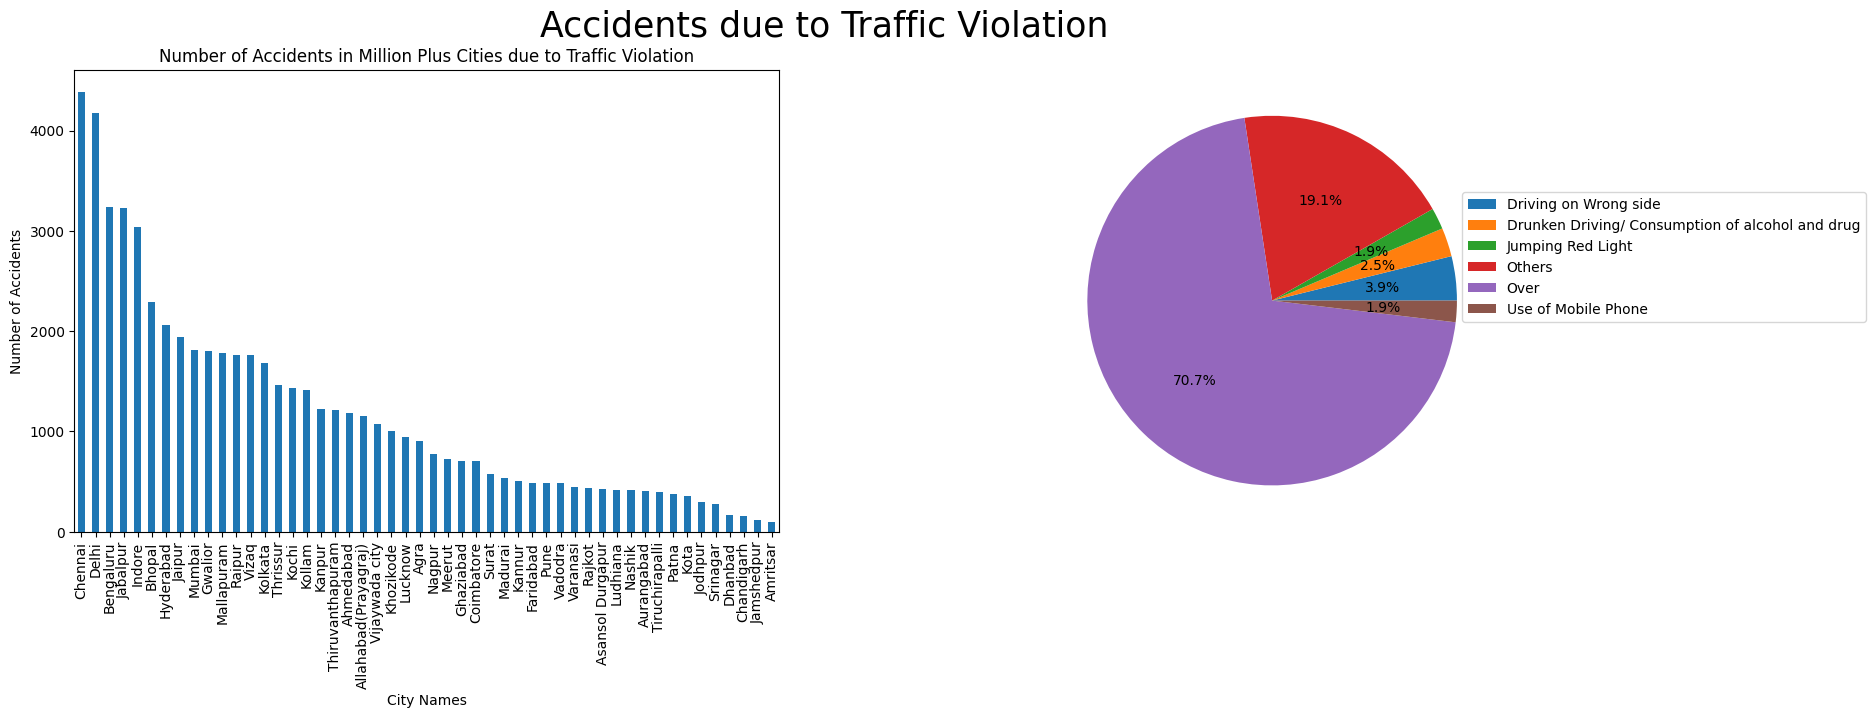

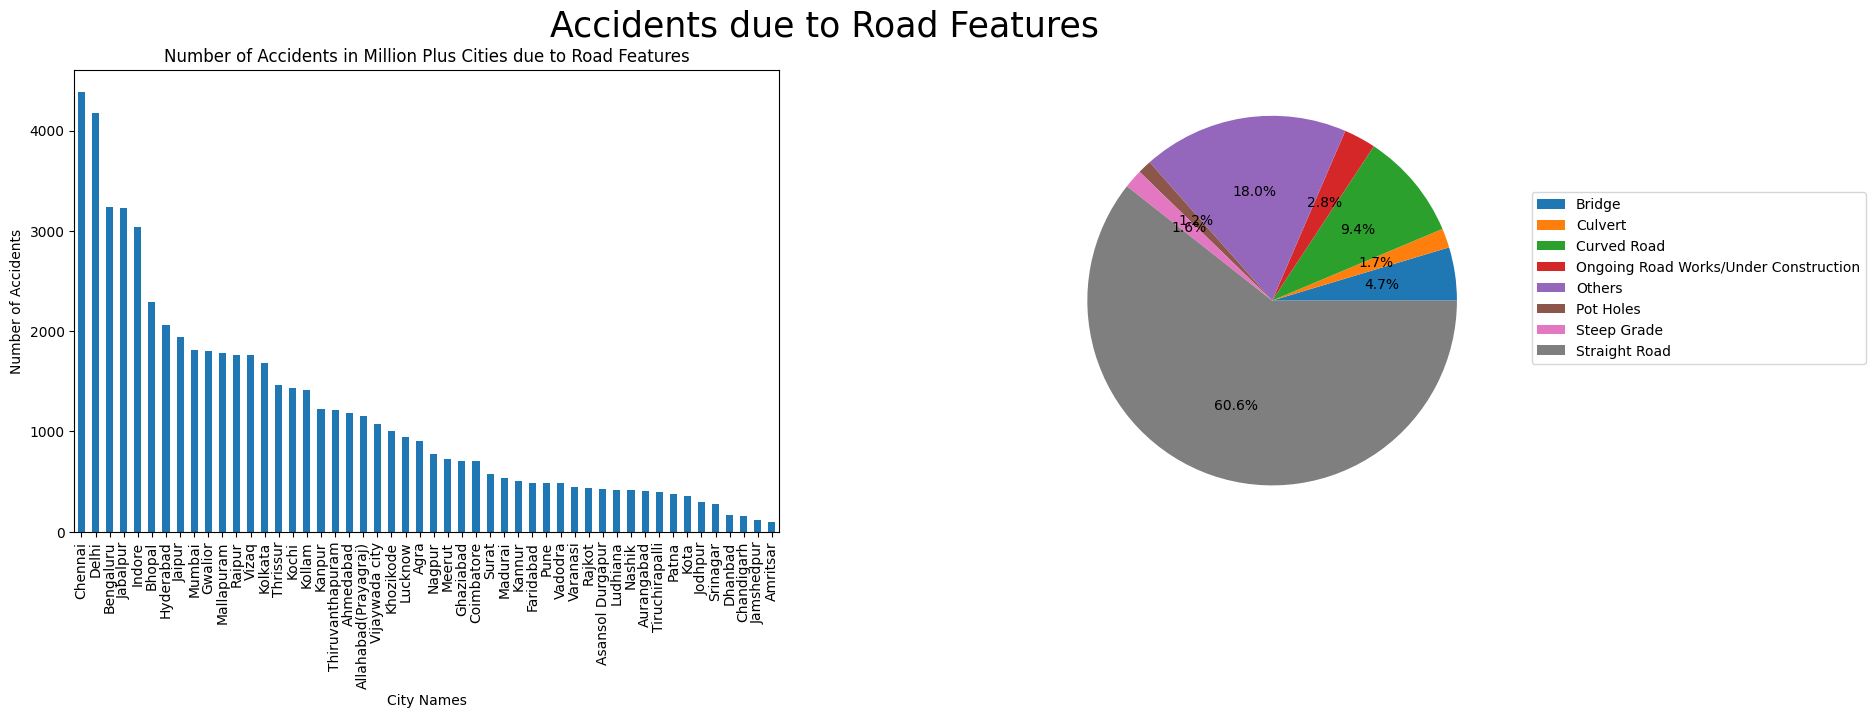

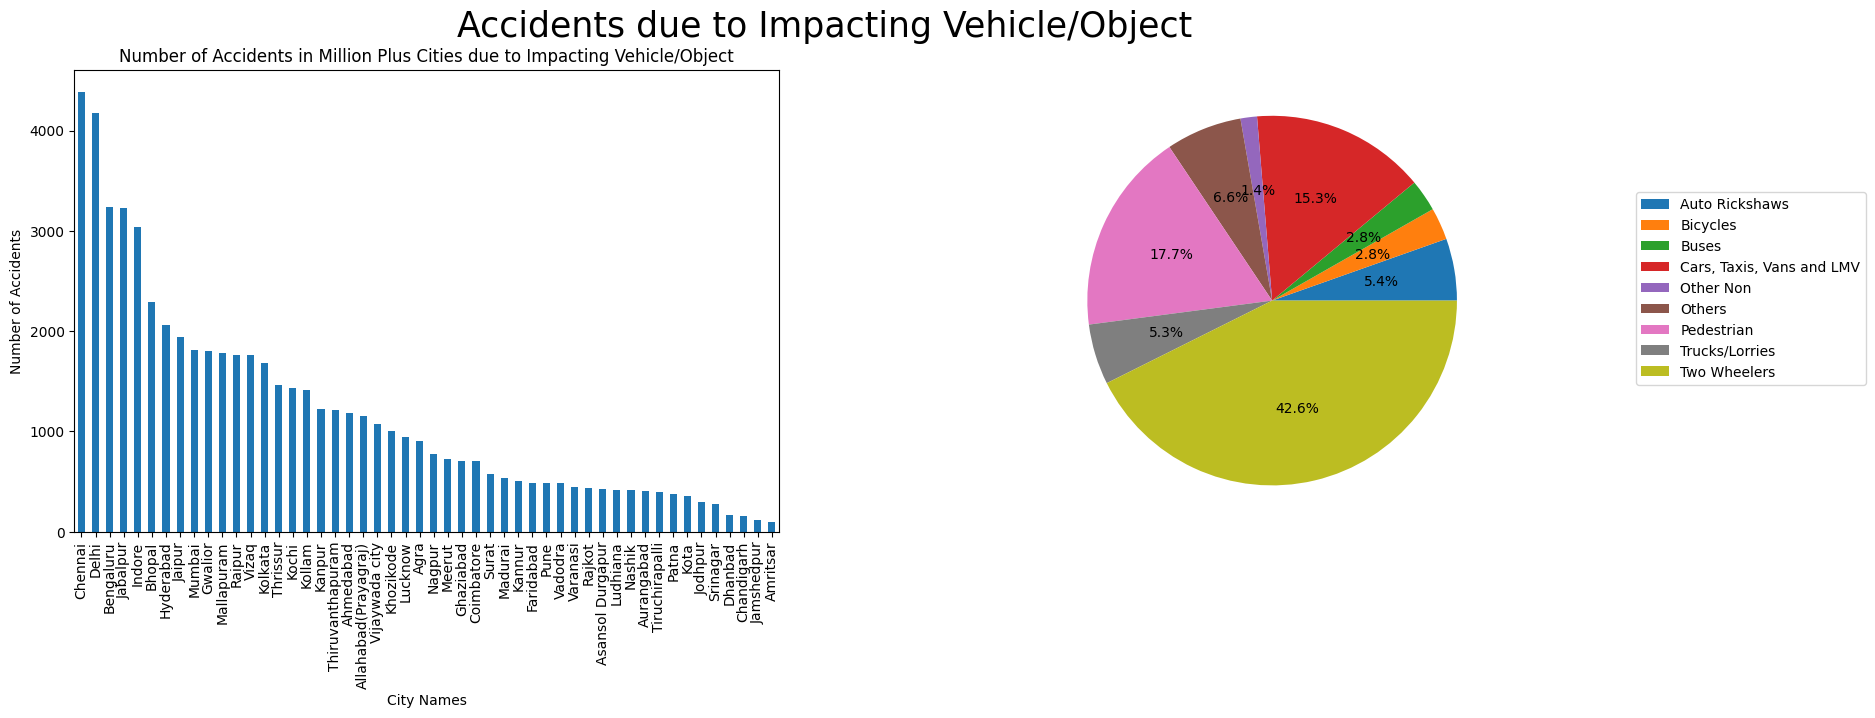

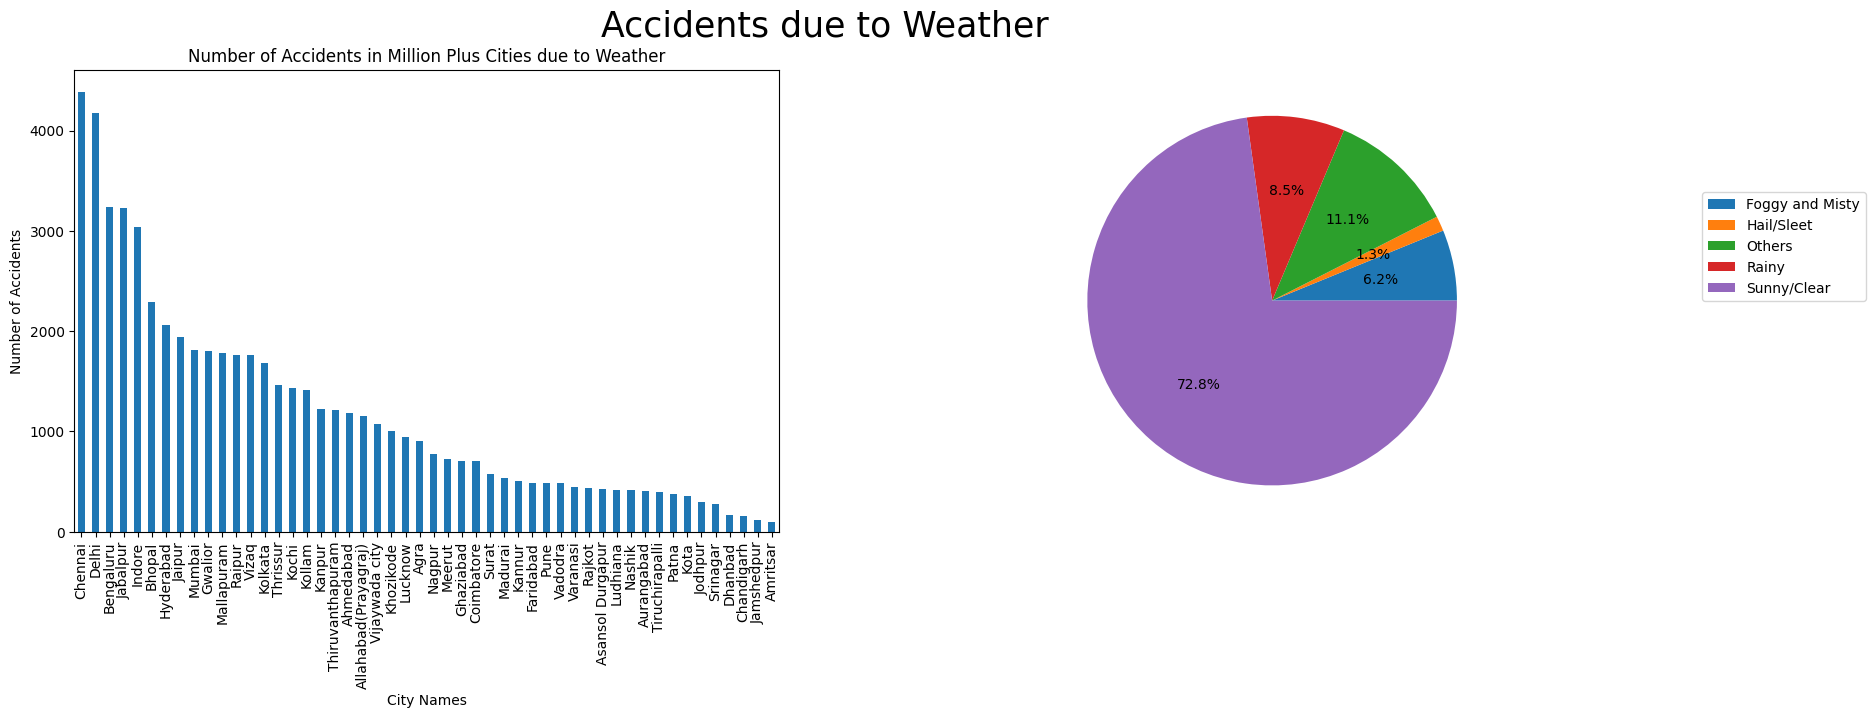

In [21]:
#Create a list of the unique cause categories for the outcome : 'Total number of Accidents'
accidents_cat_labels = total_accidents_mask['cause_category'].unique()

plt.figure(figsize=(50, 20))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

#for each cause category create plots
for label in accidents_cat_labels:
    #Create a figure for each cause category with 2 axes
    fig, axes = plt.subplots(1, 2, figsize=(20,6))
    #Add title to the figure
    plt.suptitle("Accidents due to "+label, fontsize=25, horizontalalignment='center')

    #Create a mask to filter data for each cause category
    label_mask = total_accidents_mask[total_accidents_mask['cause_category']==label]

    #Group by locations and create a bar chart based on each cause category
    cat__accidents = label_mask.groupby(['million_plus_cities']).agg('sum')[['count']].sort_values(by='count', ascending=False)
    cat__accidents.plot(kind='bar', legend=False,
                        title="Number of Accidents in Million Plus Cities due to " + label,
                        xlabel='City Names', ylabel='Number of Accidents', ax=axes[0])

    #Improve spacing of labels in the plotted bar chart
    plt.tick_params(pad=5, labelsize=6)

    #Group by related subcategories of the cause category and create a pie chart of the cause sub-category
    subcat_labels_grp = label_mask.groupby(['cause_subcategory']).agg('sum')[['count']]
    subcat_labels_grp.plot(kind='pie', subplots=True, ylabel='', labeldistance=None, ax=axes[1], autopct='%1.1f%%')

    #Adjust spacing of legends in the pie chart
    plt.legend(bbox_to_anchor=(1.8, .75), loc="upper right")
    plt.show()




List of cause sub-categories with top 3 cities for total number of accidents

In [22]:
accidents_cause_city_df = pd.DataFrame(columns = ['cause_sub_category', 'top_cities'])

for label in accidents_subcat_labels:
    label_mask = total_accidents_mask[total_accidents_mask['cause_subcategory']==label]
    
    subcat_label_mask = total_accidents_mask[total_accidents_mask['cause_subcategory']==label]
    subcat_accidents = subcat_label_mask.groupby(['million_plus_cities']).agg('sum')[['count']].sort_values(by='count', ascending=False)
    # top 3 cities in subcategory
    top_3_cities = subcat_accidents.head(3).reset_index()[['million_plus_cities']]
    accidents_cause_city_row = top_3_cities.apply(", ".join)

    data = pd.DataFrame({
            'cause_sub_category' : [label],
            'top_cities' : accidents_cause_city_row['million_plus_cities']
    })
    accidents_cause_city_df = pd.concat([accidents_cause_city_df, data])

accidents_cause_city_df                                           


,cause_sub_category,top_cities
0,Flashing Signal/Blinker,"Chennai, Delhi, Allahabad(Prayagraj)"
0,Others,"Delhi, Jabalpur, Chennai"
0,Police Controlled,"Chennai, Kochi, Bengaluru"
0,Stop Sign,"Bhopal, Chennai, Delhi"
0,Traffic Light Signal,"Chennai, Delhi, Bengaluru"
0,Uncontrolled,"Mumbai, Hyderabad, Jabalpur"
0,Four arm Junction,"Indore, Chennai, Bengaluru"
0,Round about Junction,"Chennai, Hyderabad, Indore"
0,Staggered Junction,"Mumbai, Hyderabad, Chennai"
0,T,"Jabalpur, Indore, Delhi"


Total Number of Accidents : Bar Chart for each subcategory across cities

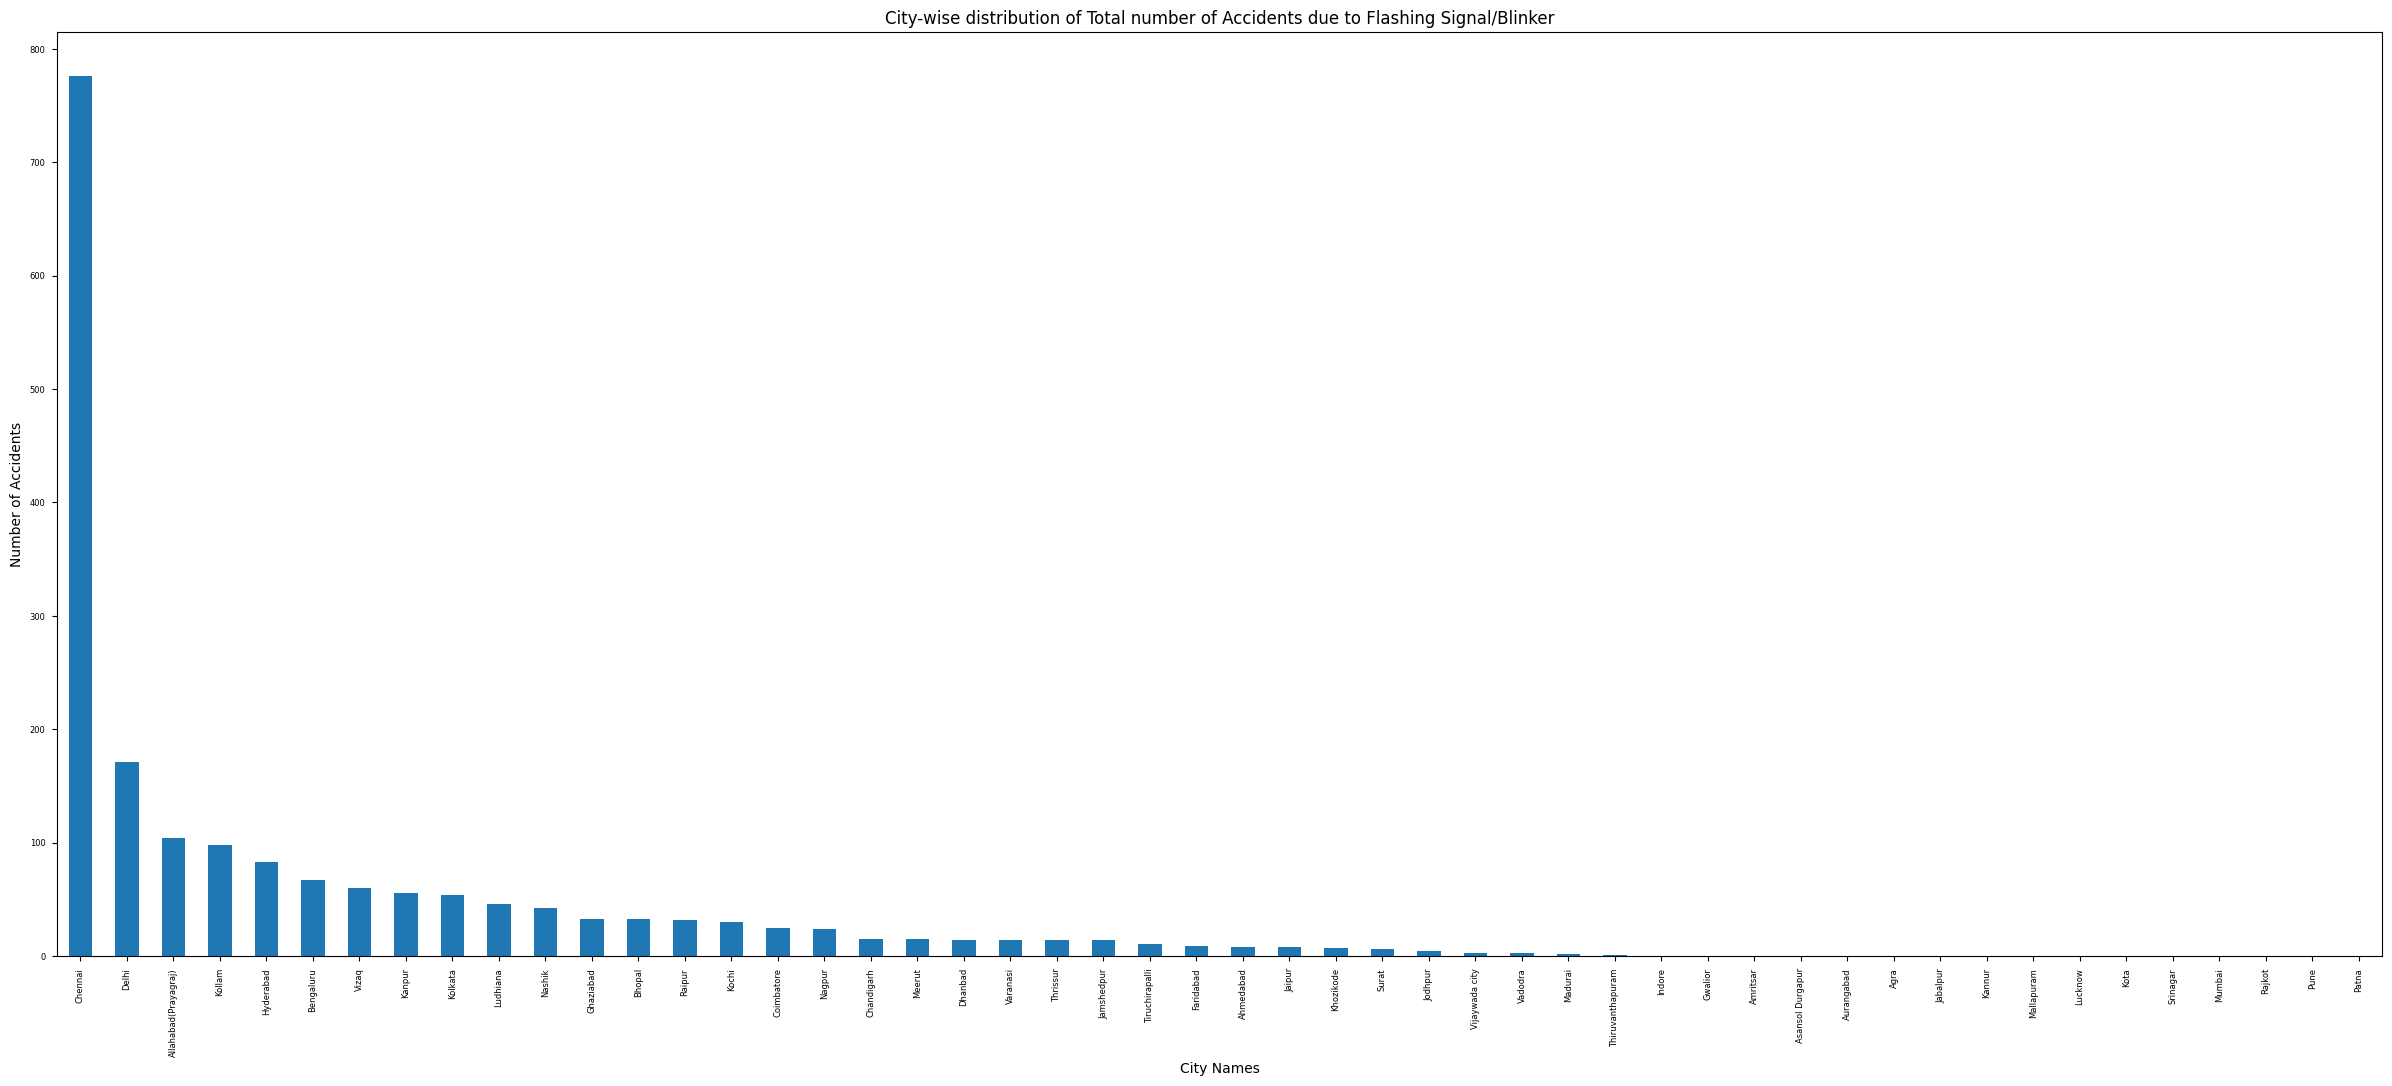

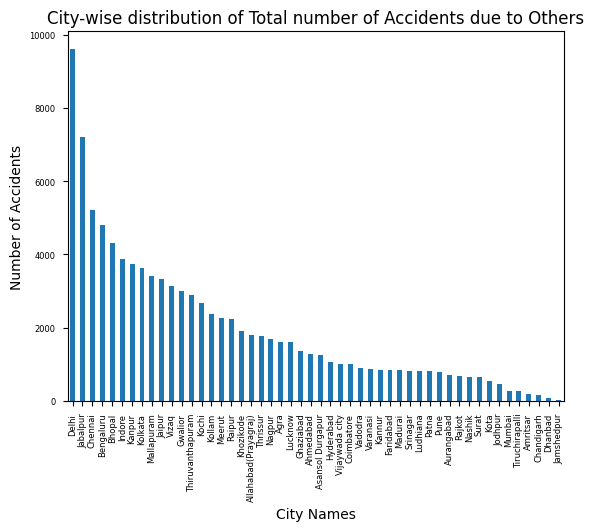

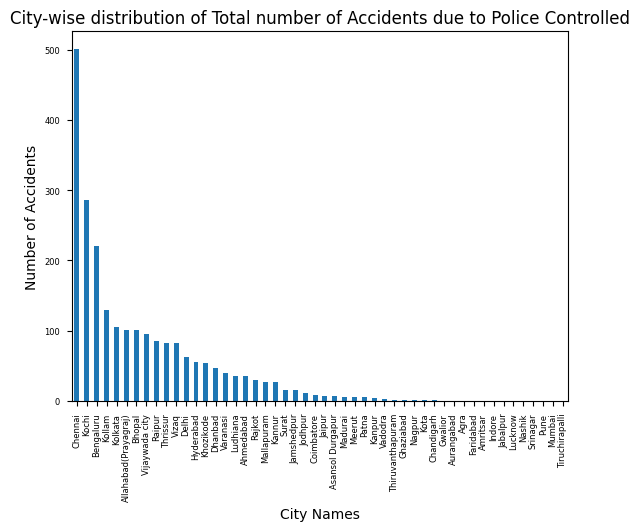

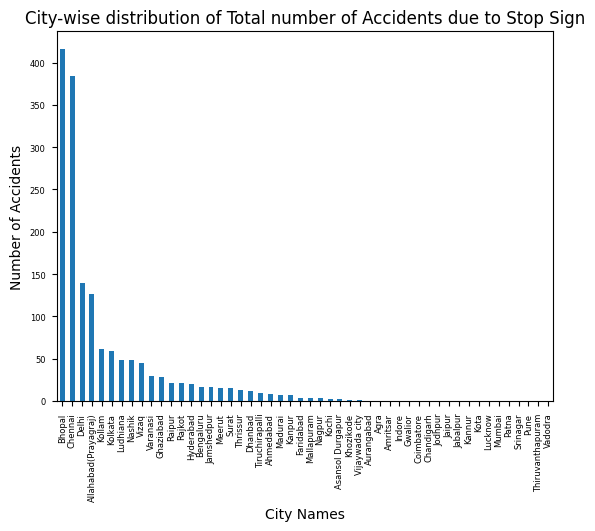

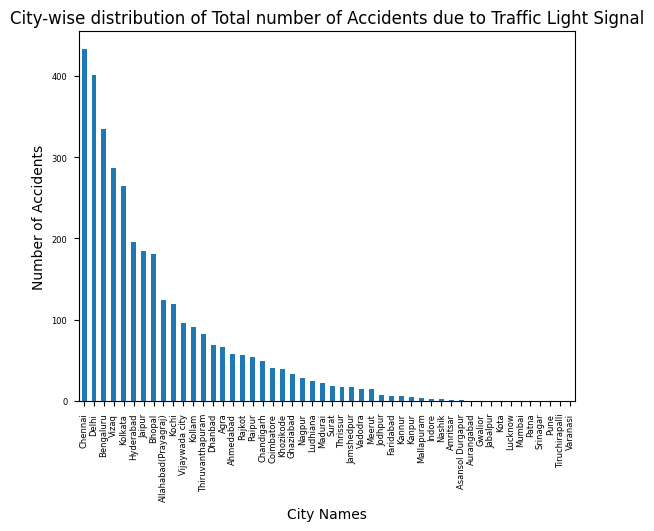

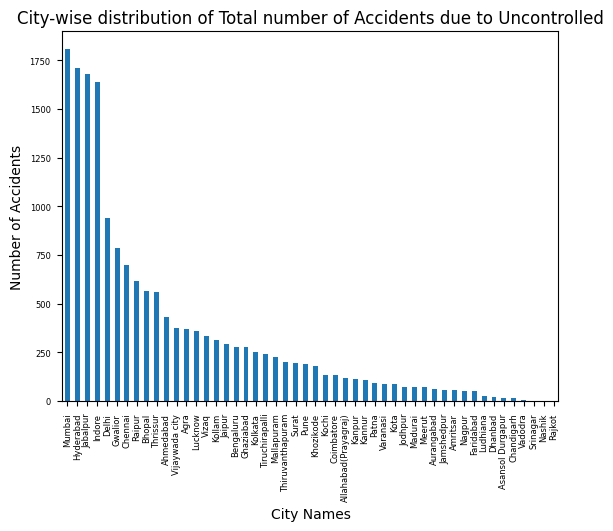

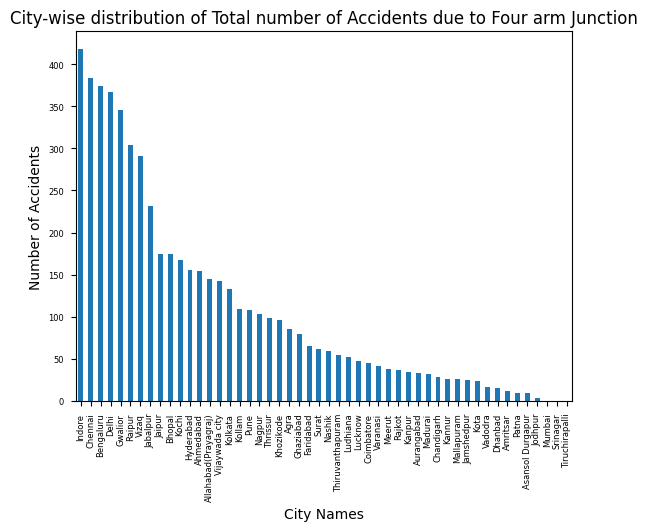

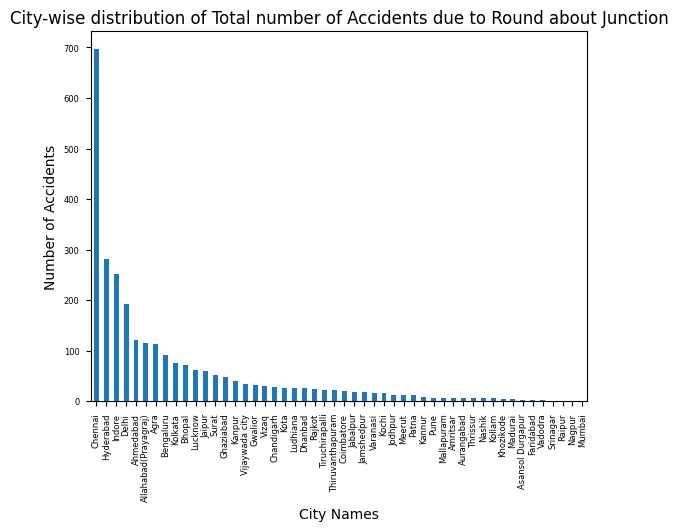

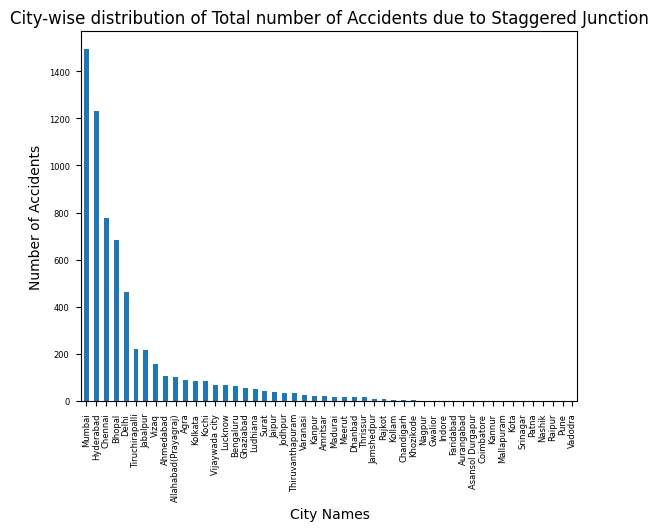

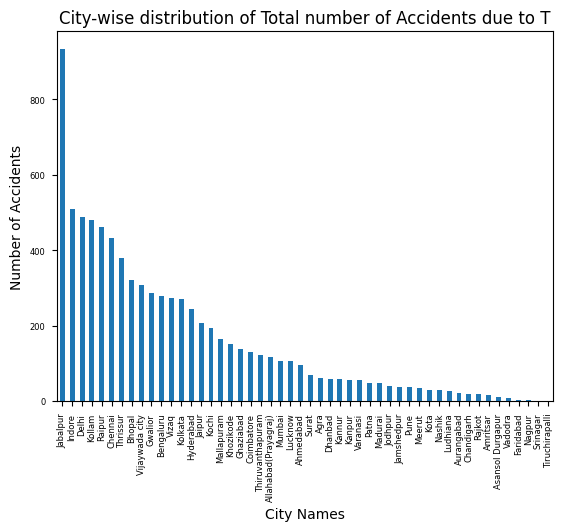

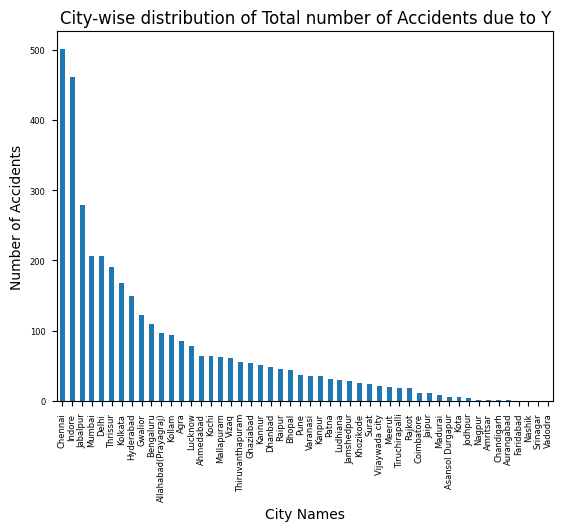

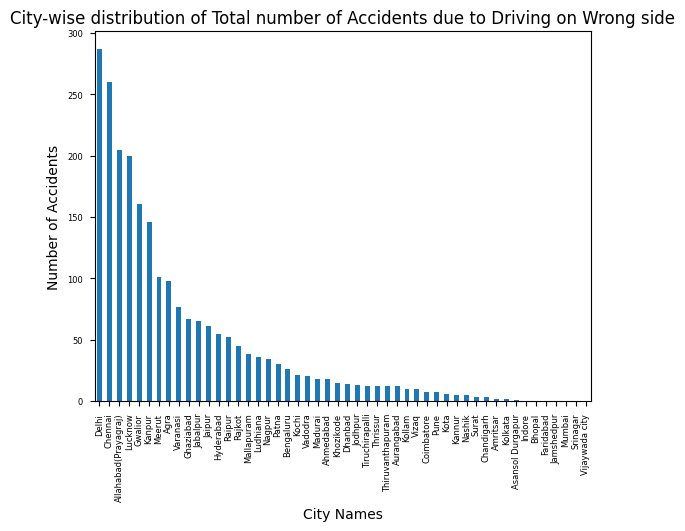

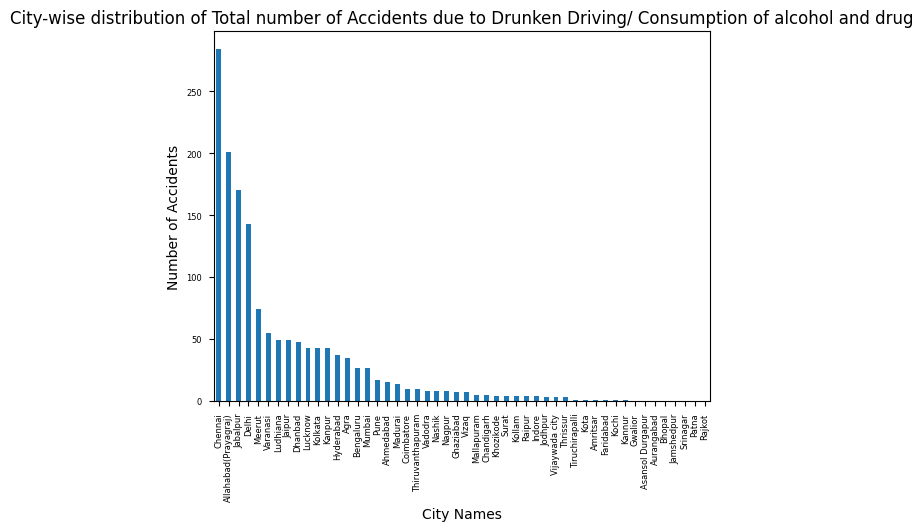

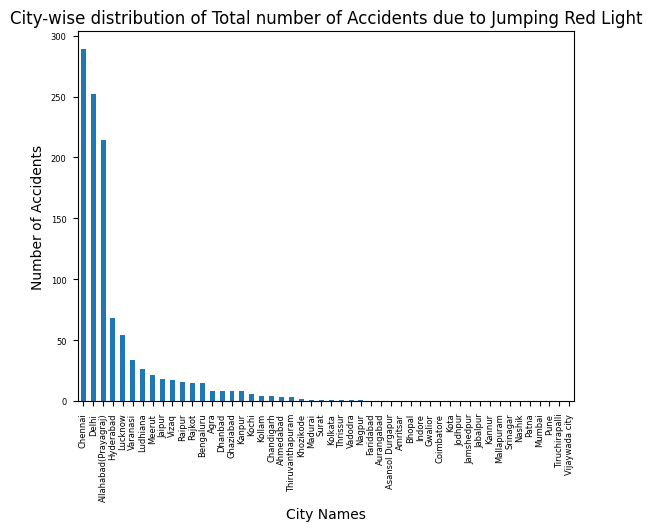

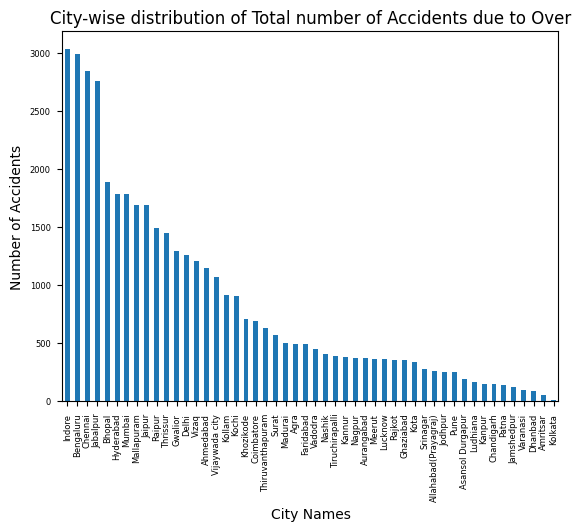

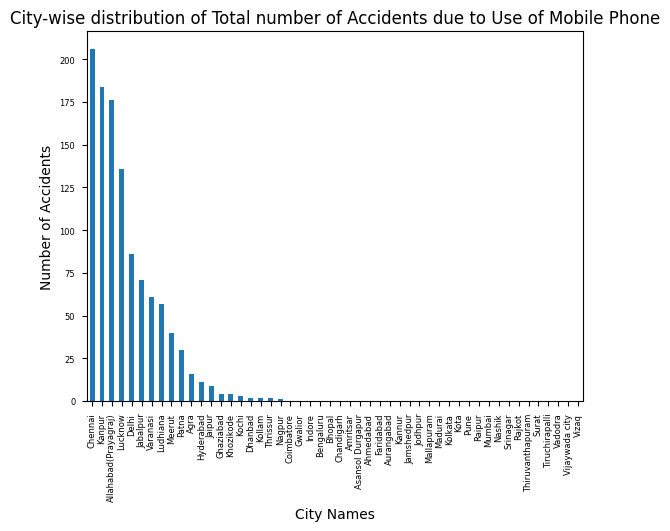

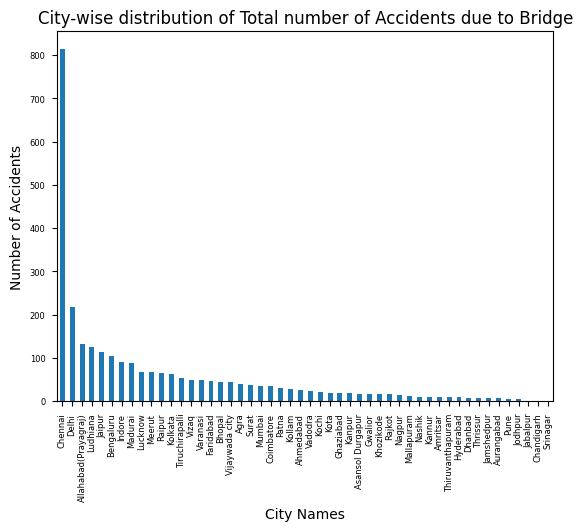

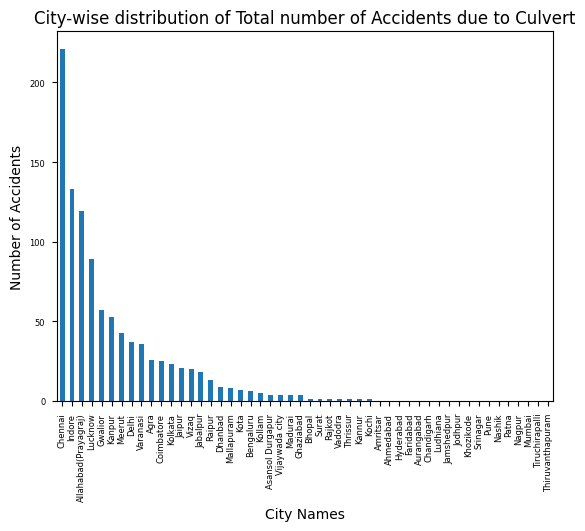

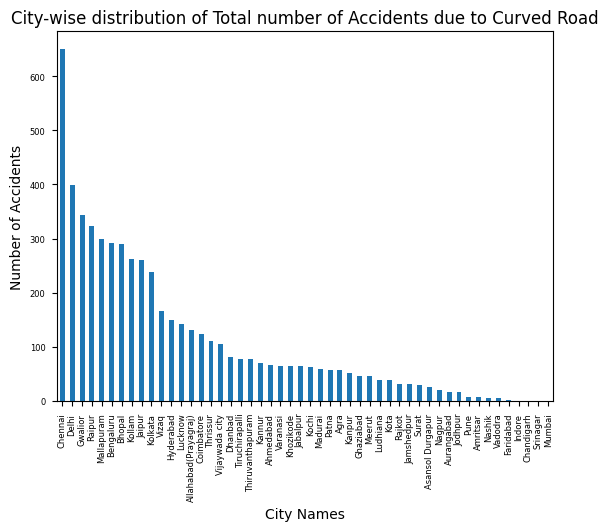

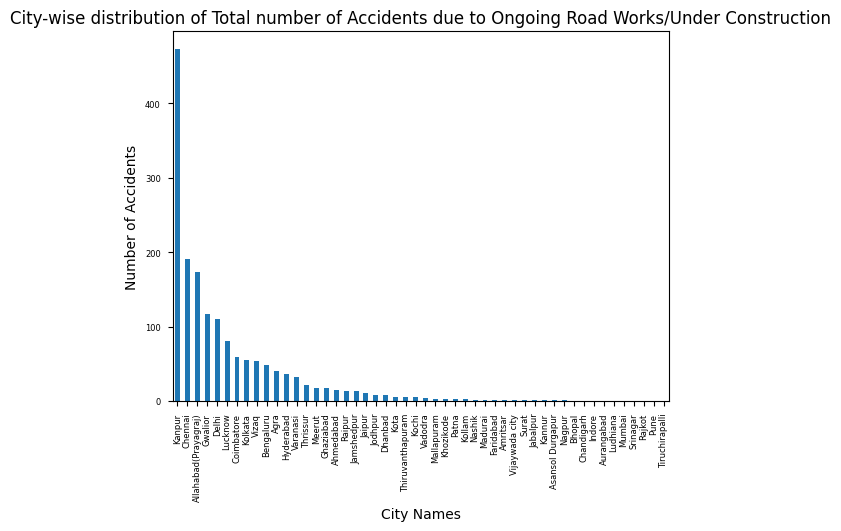

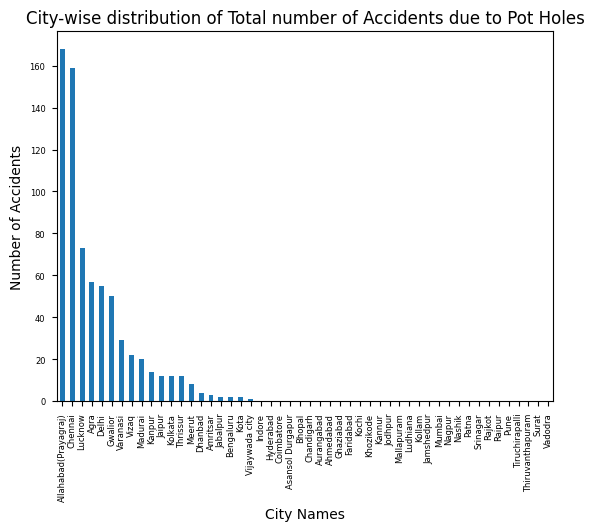

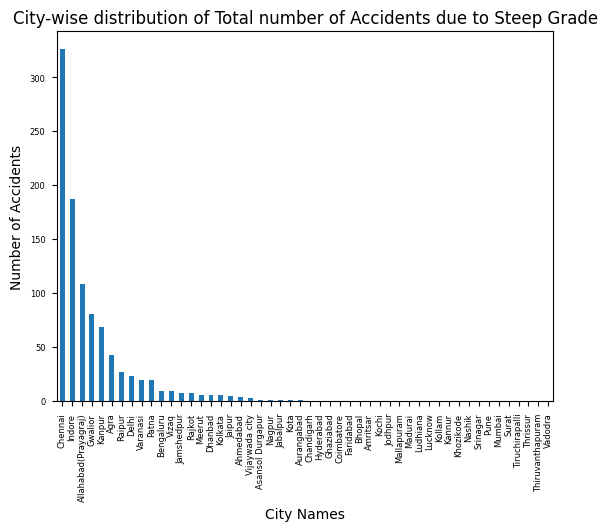

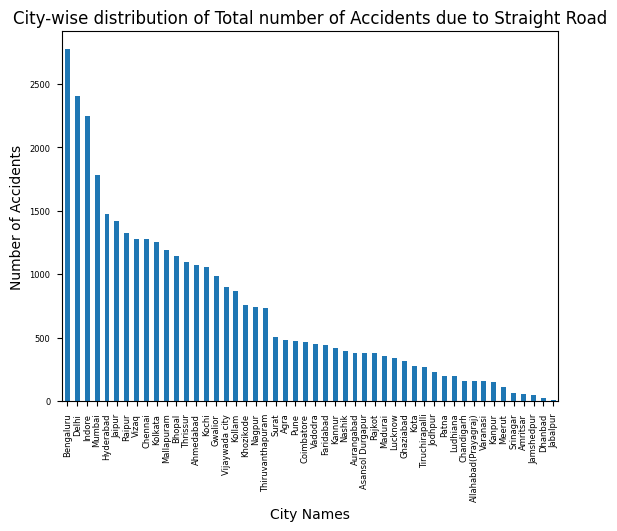

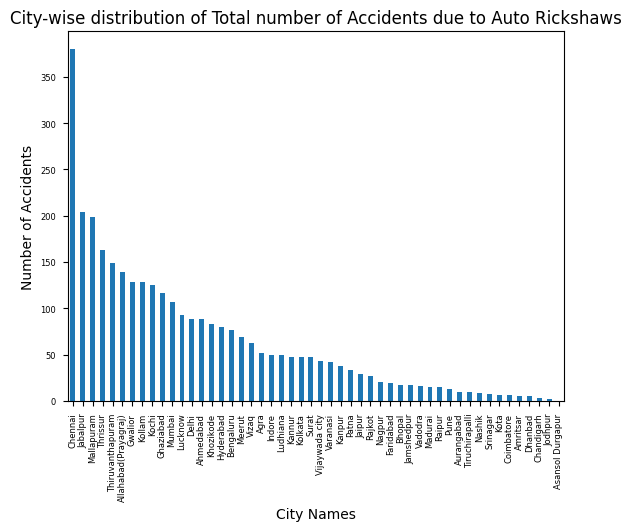

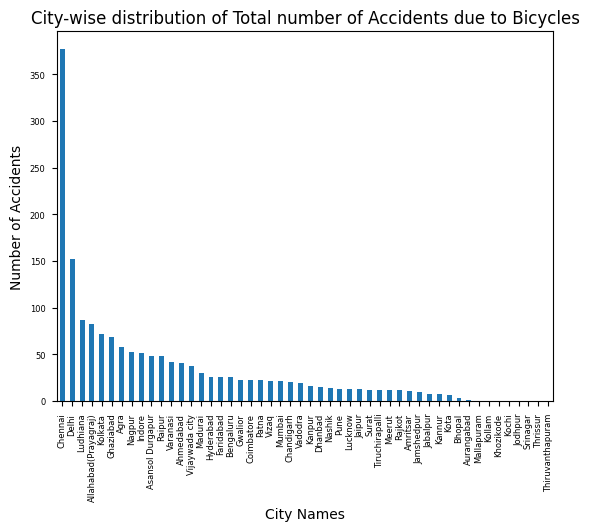

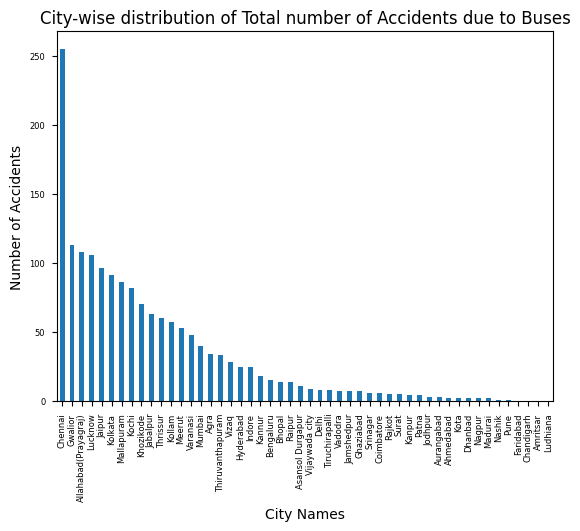

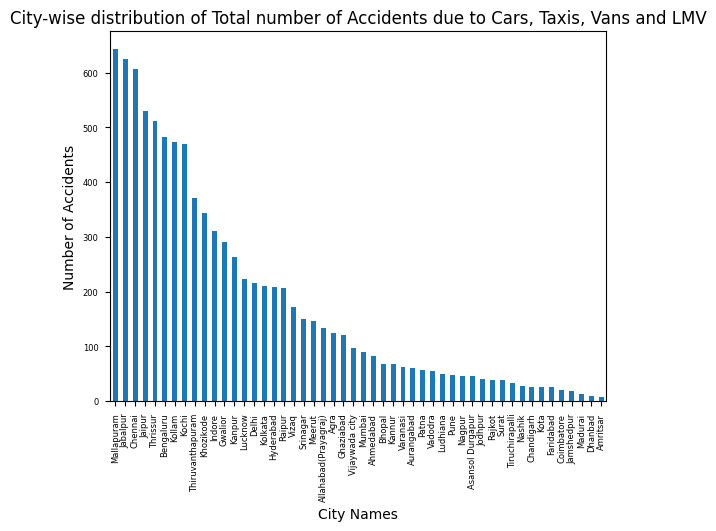

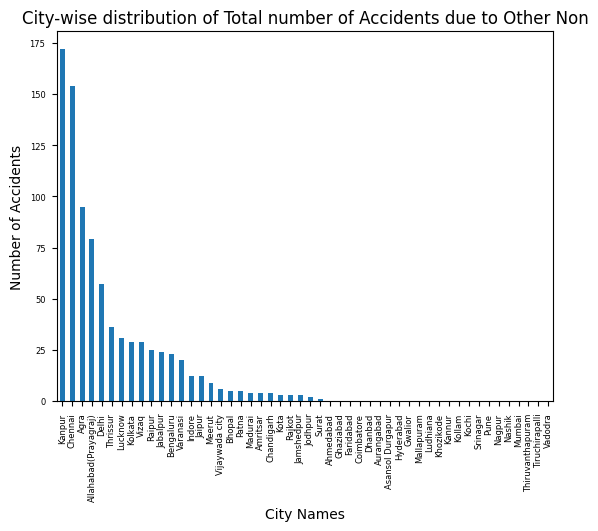

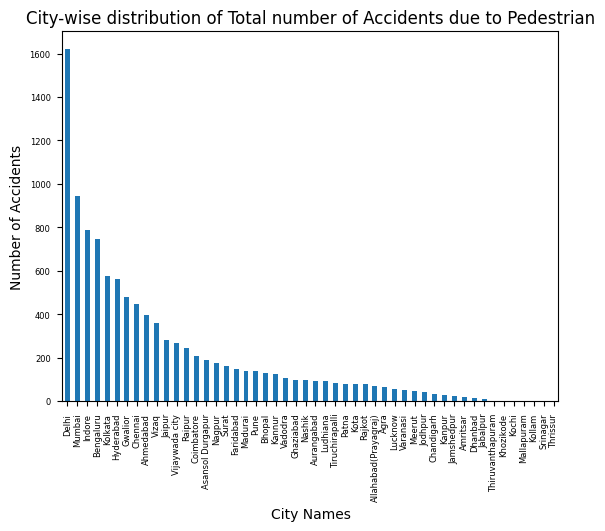

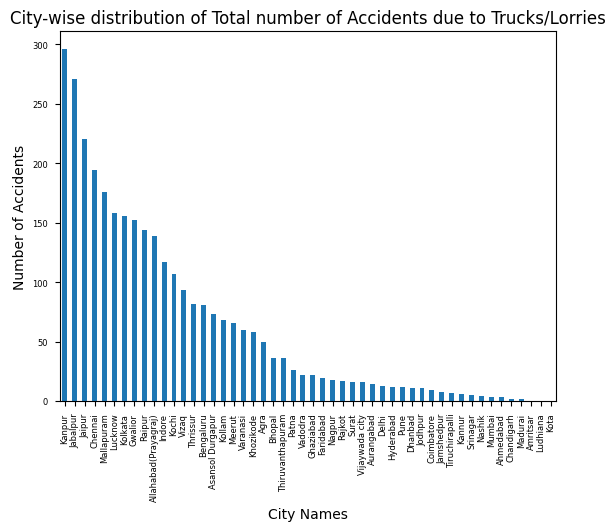

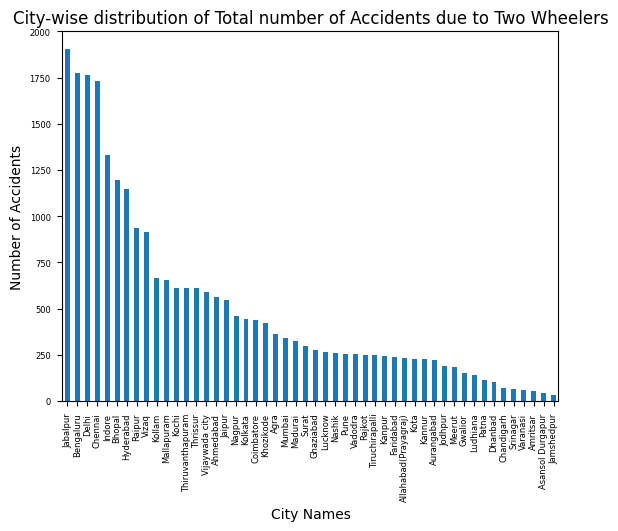

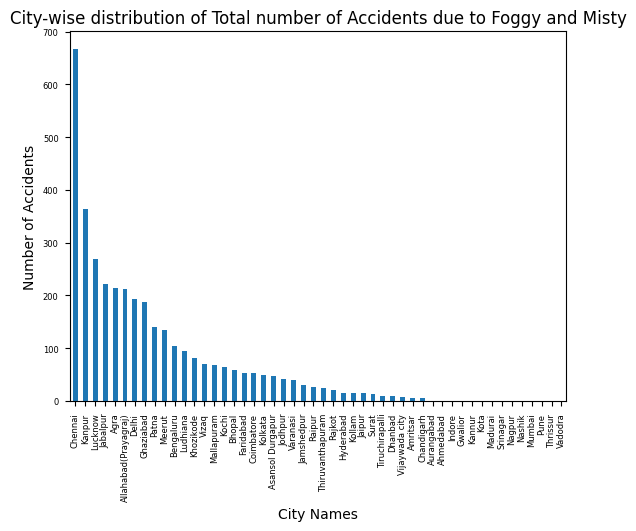

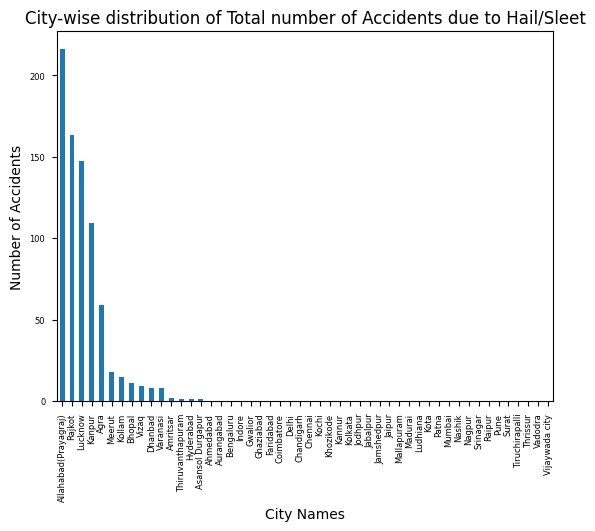

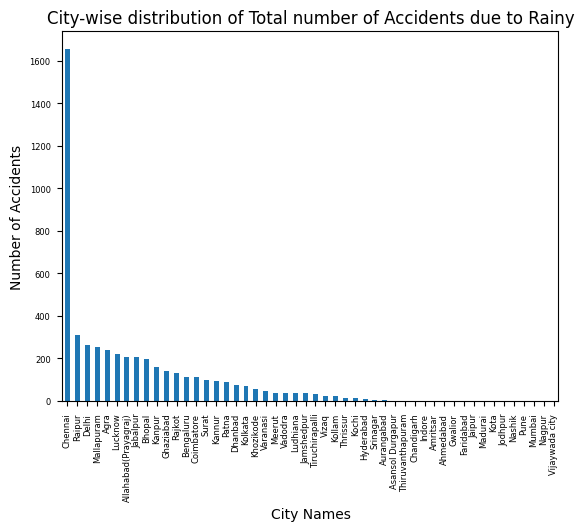

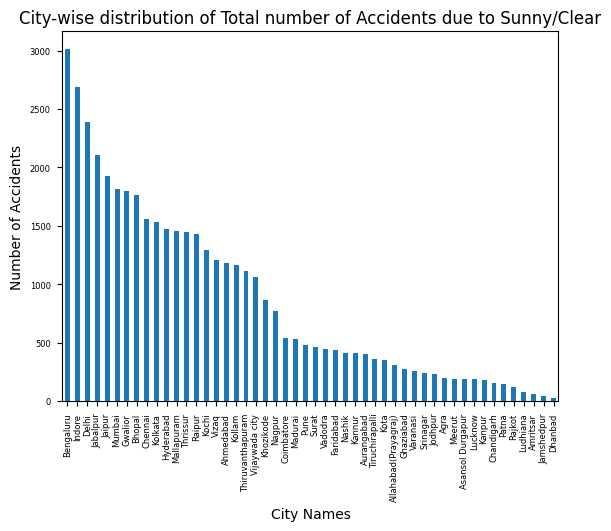

In [23]:
plt.figure(figsize=(30, 12))
plt.subplots_adjust(hspace=0.5, wspace= 0.3)

for label in accidents_subcat_labels:
    label_mask = total_accidents_mask[total_accidents_mask['cause_subcategory'] ==label]
    subplot_label_mask = total_accidents_mask[total_accidents_mask['cause_subcategory']==label]
    subcat_accidents = label_mask.groupby('million_plus_cities')['count'] \
                             .sum() \
                             .sort_values(ascending=False)

    subcat_accidents.plot(kind='bar', title="City-wise distribution of Total number of Accidents due to "+ label, xlabel="City Names", ylabel="Number of Accidents", legend=False)

    plt.tick_params(pad=5, labelsize=6)
    plt.show()

Observations

Chennai tops the list in highest total number of Accidents, followed by Delhi, Bengaluru, Jabalpur, and Indore.

Amritsar recorded the least number of accidents across all categories.

Second and third least number of accidents occur in Jamshedpur and Chandigarh.

Total Number of Accidents count reported is the highest on Sunny/Clear weather days.

Accidents occur most frequently on Straight Roads and most commonly for Two Wheelers as the Impacting Vehicle.

Over(overspeeding) takes up a big chunk of space as the cause of accidents due to Traffic Violation.

T, Staggered Junction, and Four arm Junction have almost equal distributions in count of people injured due to accidents at Junctions.


City-wise observations of causes of accidents (Top 3 Cities)
Delhi topped the list of cities in most number of accidents due to : Pedestrian and Driving on Wrong side. Some more reasons were : Bicycles, Bridge, Straight Road, Curved Road, Jumping Red Light, Traffic Light Signal, Flashing Signal/Blinker, Stop Sign, T junction, Sunny/Clear, Rainy weather, and Two Wheelers.

Chennai topped the list of cities in most number of accidents due to 11 such causes/sub-categories : Rainy, Foggy/Misty, weather, vehicles such as Buses, Bicycles, Auto Rickshaws, Steep Grade, Culvert, Curved Road, Bridge, due to Use of Mobile Phone, Drunken Driving/ Consumption of alcohol and drug, Jumping Red Light, Y Junction, Round about Junction, Police Controlled, and Flashing Signal/Blinker.

Most common reasons for accidents in Allahabad(Prayagraj) were : Hail/Sleet and Pot Holes. Some of the other reasons were Drunken Driving/ Consumption of alcohol and drug, Buses, roads with Ongoing Road Works/Under Construction, Steep Grade, Culvert, Bridge, due to Drunken Driving/ Consumption of alcohol and drug, Jumping Red Light, Driving on Wrong Side and Flashing Signal/Blinker.

Mumbai topped the list of most accidents due to : Y Junction, Uncontrolled Traffic. Some of the other reasons : Pedestrian.

Common reason for accidents in Raipur were : T Junction, Rainy weather.

Common reason for accidents in Jaipur were : Truck Lorries.

Kanpur topped list of most accident due to : Truck Lorries, Ongoing Road Works,/Under Construction. Some of the other reasons were Foggy/Misty weather.

Most common reason for accidents in Indore were : Over and Four arm Junction. Some of the other reasons were Sunny/Clear weather, Steep Grade, Culvert, Y and T junction, Pedestrian, Straight Road and Round about Junction.

Most common reasons for accidents in Bengaluru were : Sunny/Clear weather and Straight Road. Some of the other reasons were : Two Wheelers, Over, Four arm Junction, Traffic Light Signal and Police Controlled.

Common reason for accidents in Rajkot : Hail/Sleet.

Most common reason for accidents in Jabalpur were : Two Wheelers and T Junction. Some other reasons were : Trucks/Lorries, Cars, Taxis, Vans and LMV, Auto Rickshaws, Drunken Driving/ Consumption of alcohol and drug, Y junction and Uncontrolled traffic.

Most common reason for accidents in Lucknow were : Hail/Sleet, Foggy/Misty weather and Potholes.

Common reason for accidents in Mallapuram were : Cars, Taxis, Vans and LMV and Auto Rickshaws

Common reason for accidents in Gwalior were : Buses and Curved Roads.

Most common reasons for accidents in Ludhiana were : Bicycles.

Most common reasons for accidents in Hyderabad were : Staggered Junction, Round about Junction and Uncontrolled traffic.

Common reason for accidents in Bhopal were : Stop sign

Common reason for accidents in Kochi were : Police Controlled traffic.

Total Injured - Analysis

In [24]:
#Create a Mask with outcome : 'Total Injured'
total_injured_mask = df[df['outcome_of_incident'] == "Total Injured"]

Bar Chart Distribution of Total injured in accidents across cities

<Figure size 5000x1500 with 0 Axes>

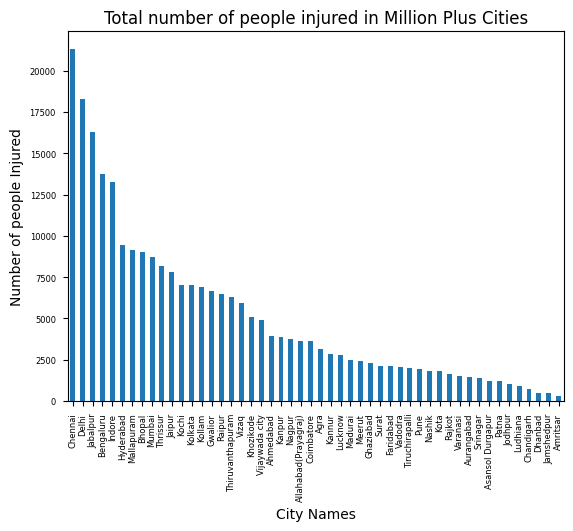

In [25]:
plt.figure(figsize=(50, 15))

#Group by cities w.r.t outcome = Total Injured
cat_grp_injured = total_injured_mask.groupby(['million_plus_cities']).agg('sum')[['count']]\
    .sort_values(by='count', ascending=False)

#Create a Barplot of Total Injured w.r.t cities
cat_grp_injured.plot(kind="bar", title="Total number of people injured in Million Plus Cities", legend=False, xlabel="City Names", ylabel="Number of people Injured")
plt.tick_params(pad=5, labelsize=6)
plt.show()

Total Injured : Percentage distribution of total injured in accidenrs across cities

In [26]:
#Calculate % of injured people w.r.t cities
cat_grp_injured['percentage'] = (cat_grp_injured['count'] / cat_grp_injured['count'].sum()) * 100
cat_grp_injured

,count,percentage
million_plus_cities,,
Chennai,21315.0,8.439078
Delhi,18310.0,7.249332
Jabalpur,16285.0,6.447590
Bengaluru,13755.0,5.445907
Indore,13240.0,5.242007
Hyderabad,9460.0,3.745422
Mallapuram,9140.0,3.618727
Bhopal,9035.0,3.577155
Mumbai,8700.0,3.444521


Total Injured - Study w.r.t each Cause Category and subcategory

In [27]:
injured_subcat_labels = total_injured_mask['cause_subcategory'].unique()

<Figure size 5000x2000 with 0 Axes>

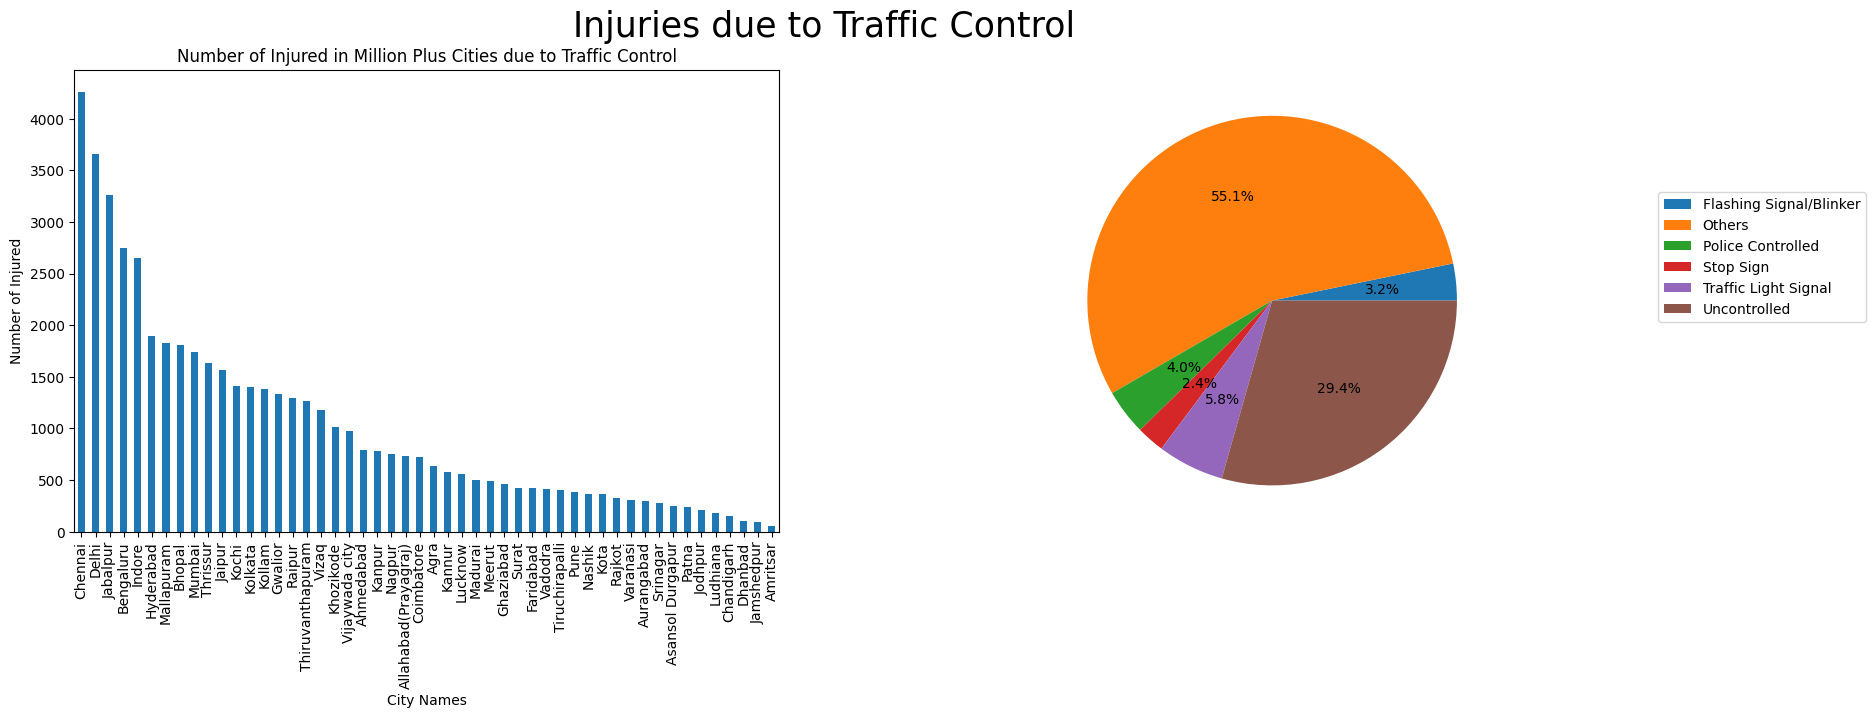

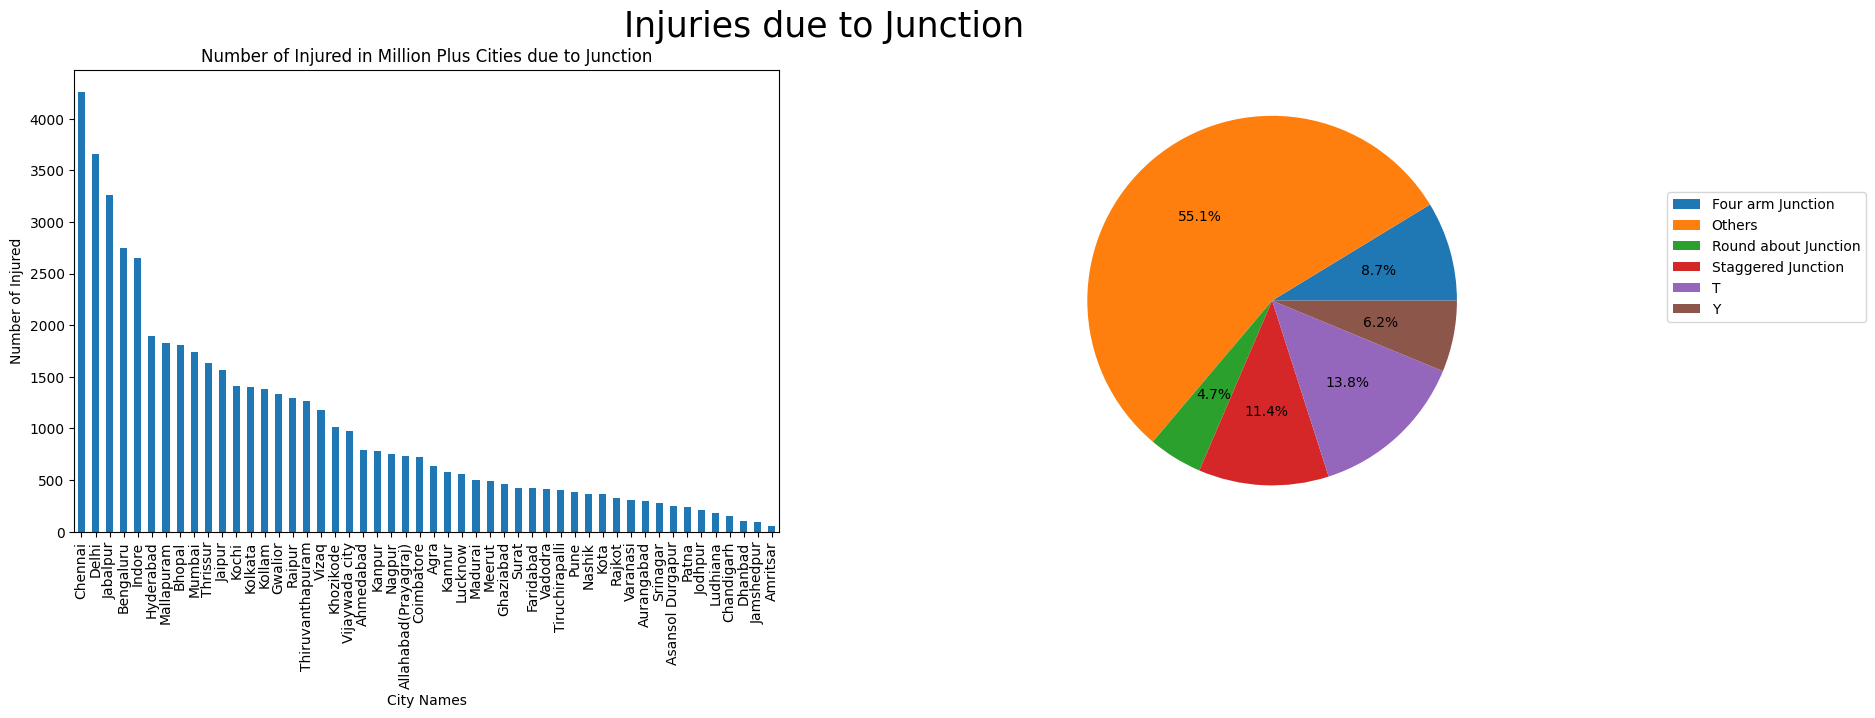

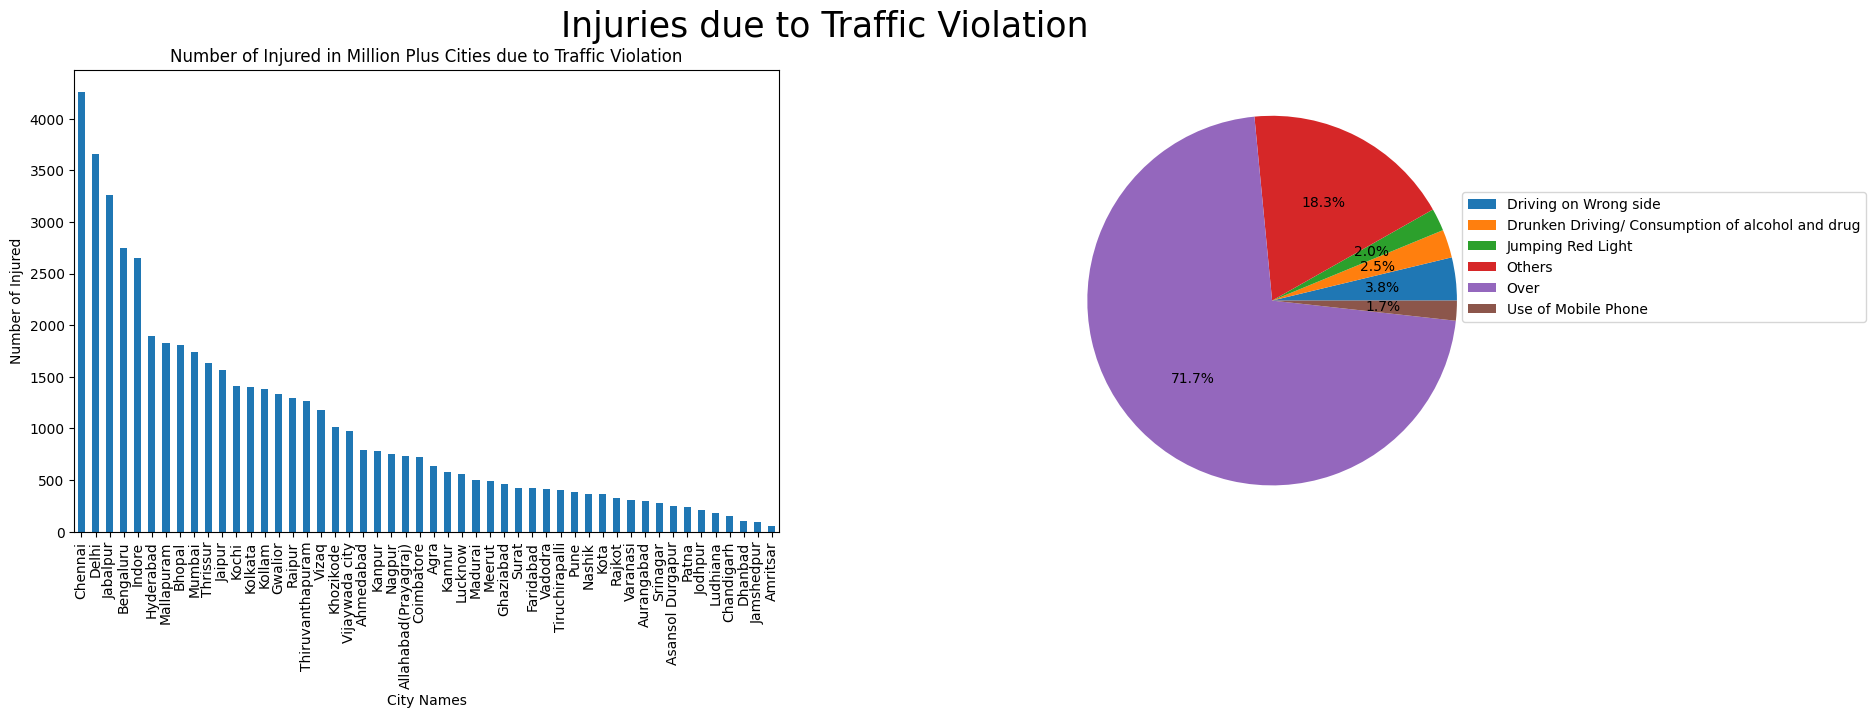

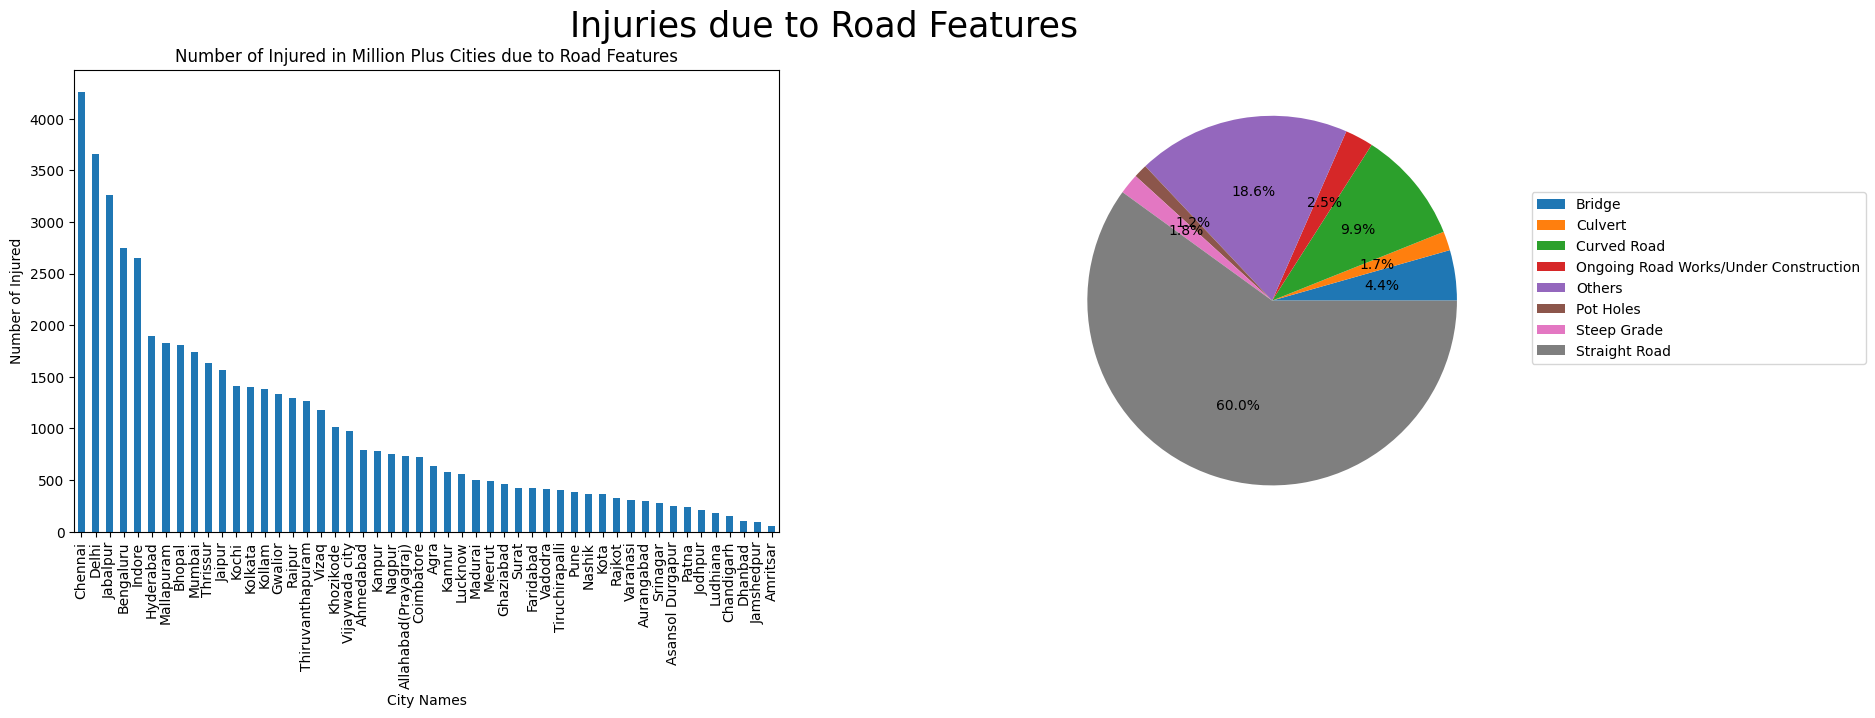

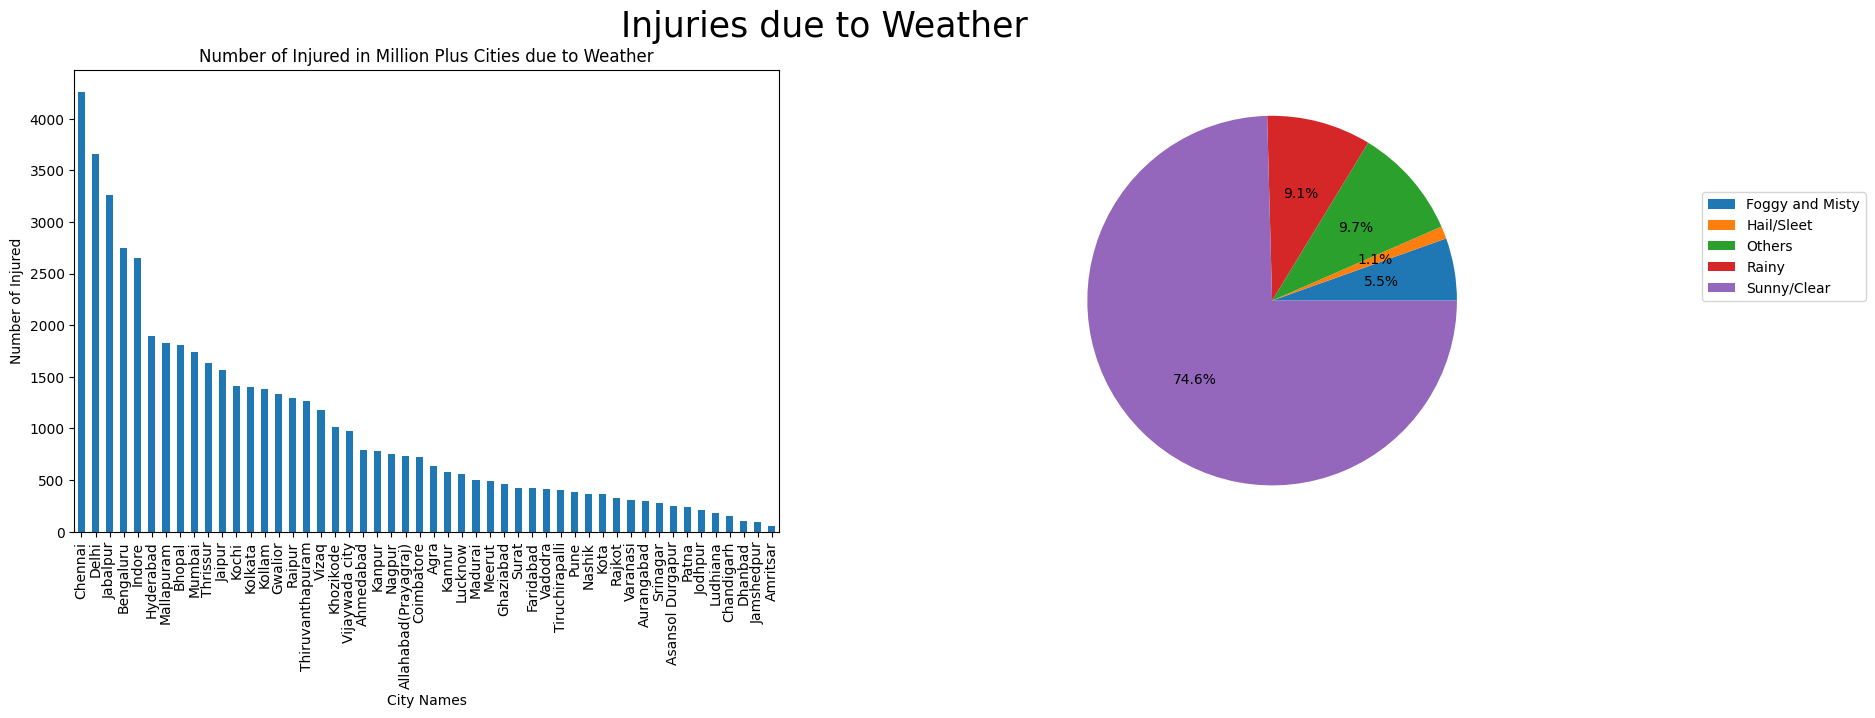

In [28]:
#Create a list of the unique cause categories for the outcome : 'Total Injured'
injured_cat_labels = total_injured_mask['cause_category'].unique()

plt.figure(figsize=(50, 20))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

#for each category create plots
for label in injured_cat_labels:
    #Create a figure for each cause category with 2 axes
    fig, axes = plt.subplots(1, 2, figsize=(20,6))
    #Add title to the figure
    plt.suptitle("Injuries due to "+label, fontsize=25, horizontalalignment='center')

    #Create a mask to filter data for each cause category
    label_mask = total_injured_mask[total_injured_mask['cause_category']==label]

    #Group by locations and create a bar chart based on each cause category
    cat_injured = label_mask.groupby(['million_plus_cities']).agg('sum')[['count']].sort_values(by='count', ascending=False)
    cat_injured.plot(kind='bar', legend=False,
                        title="Number of Injured in Million Plus Cities due to " + label,
                        xlabel='City Names', ylabel='Number of Injured', ax=axes[0])

    #Improve spacing of labels in the plotted bar chart
    plt.tick_params(pad=5, labelsize=6)

    #Group by related subcategories of the cause category and create a pie chart of the cause sub-category
    subcat_labels_grp = label_mask.groupby(['cause_subcategory']).agg('sum')[['count']]
    subcat_labels_grp.plot(kind='pie', subplots=True, ylabel='', labeldistance=None, ax=axes[1], autopct='%1.1f%%')

    #Adjust spacing of legends in the pie chart
    plt.legend(bbox_to_anchor=(1.8, .75), loc="upper right")
    plt.show()

List of cause sub-categories with top 3 cities

In [29]:
injured_cause_city_df = pd.DataFrame(columns = ['cause_sub_category', 'top_cities'])
for label in injured_subcat_labels:
    label_mask = total_injured_mask[total_injured_mask['cause_subcategory']==label]
    
    subcat_label_mask = total_injured_mask[total_injured_mask['cause_subcategory']==label]
    subcat_injured = subcat_label_mask.groupby(['million_plus_cities']).agg('sum')[['count']].sort_values(by='count', ascending=False)
    # top 3 cities in subcategory
    top_3_cities = subcat_injured.head(3).reset_index()[['million_plus_cities']]
    injured_cause_city_row = top_3_cities.apply(", ".join)

    data = pd.DataFrame({
            'cause_sub_category' : [label],
            'top_cities' : injured_cause_city_row['million_plus_cities']
    })
    injured_cause_city_df = pd.concat([injured_cause_city_df, data])
injured_cause_city_df

,cause_sub_category,top_cities
0,Flashing Signal/Blinker,"Chennai, Delhi, Kollam"
0,Others,"Delhi, Jabalpur, Chennai"
0,Police Controlled,"Chennai, Kochi, Bengaluru"
0,Stop Sign,"Bhopal, Chennai, Delhi"
0,Traffic Light Signal,"Chennai, Delhi, Bengaluru"
0,Uncontrolled,"Jabalpur, Mumbai, Hyderabad"
0,Four arm Junction,"Indore, Bengaluru, Chennai"
0,Round about Junction,"Chennai, Indore, Hyderabad"
0,Staggered Junction,"Mumbai, Hyderabad, Chennai"
0,T,"Jabalpur, Kollam, Chennai"


Bar chart for each subcategory across cities

<Figure size 3000x1200 with 0 Axes>

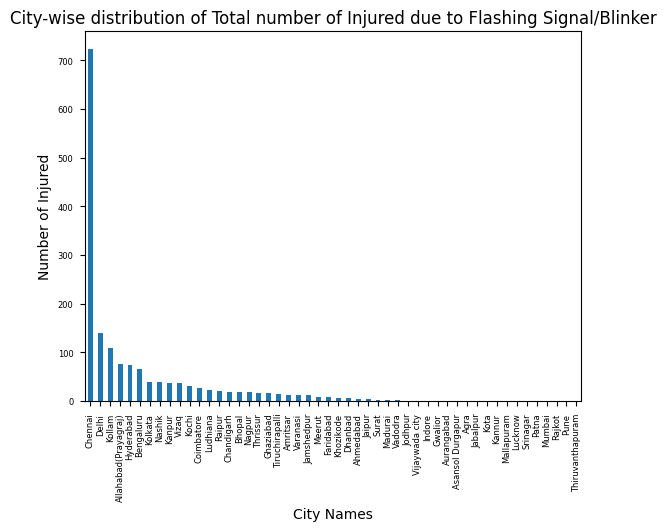

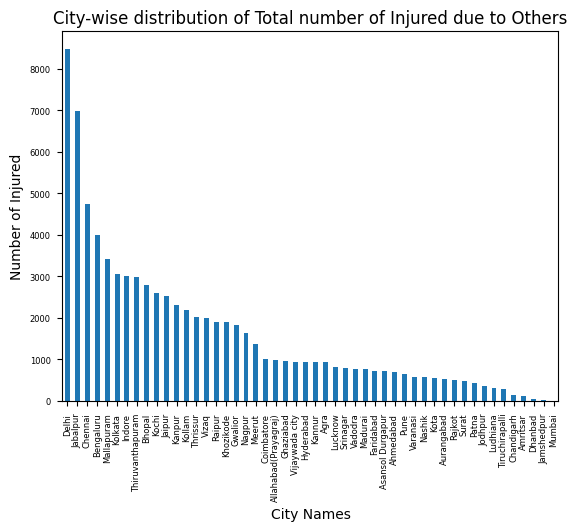

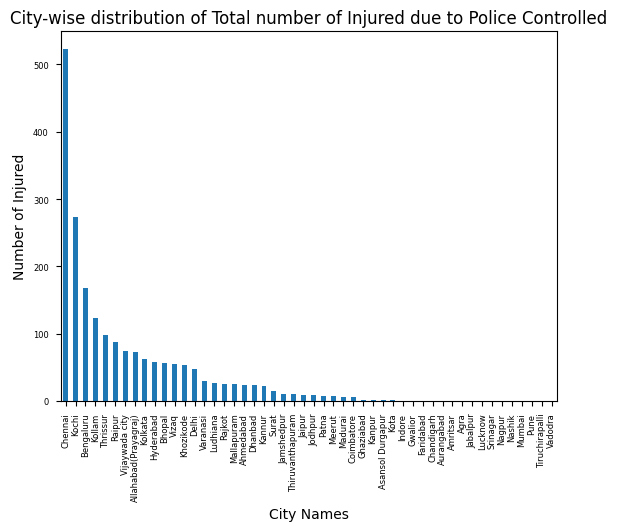

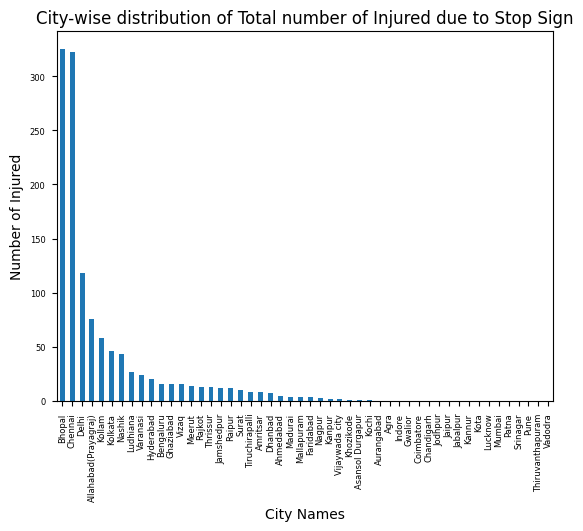

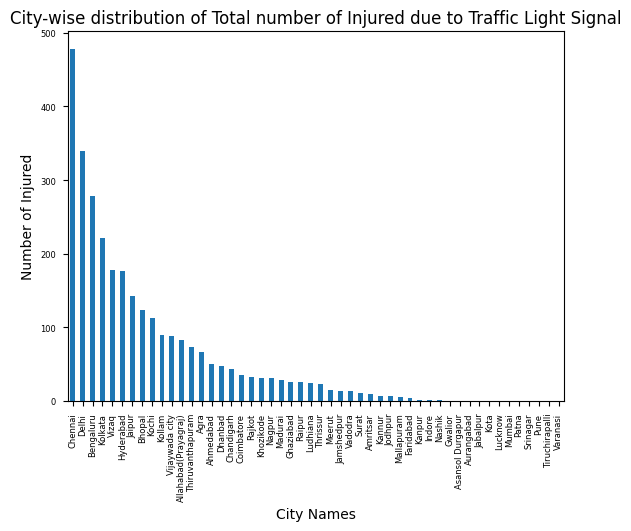

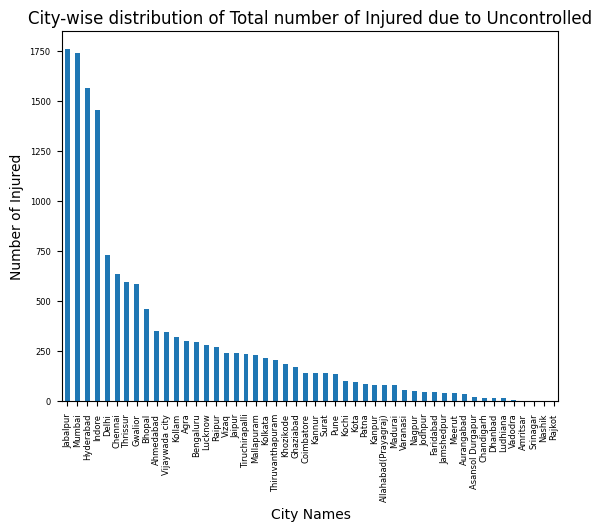

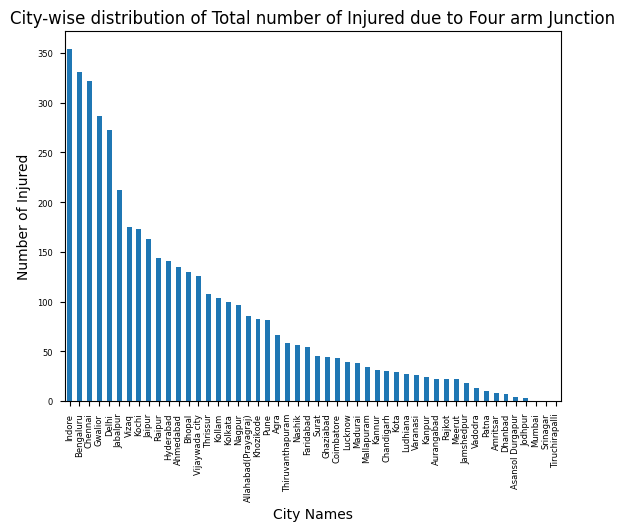

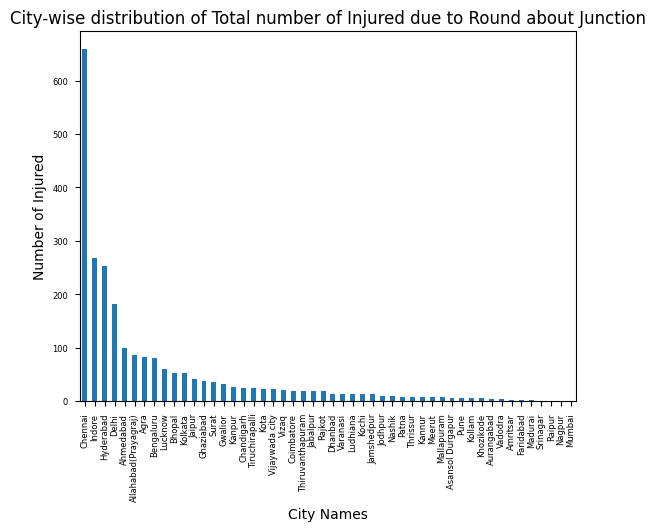

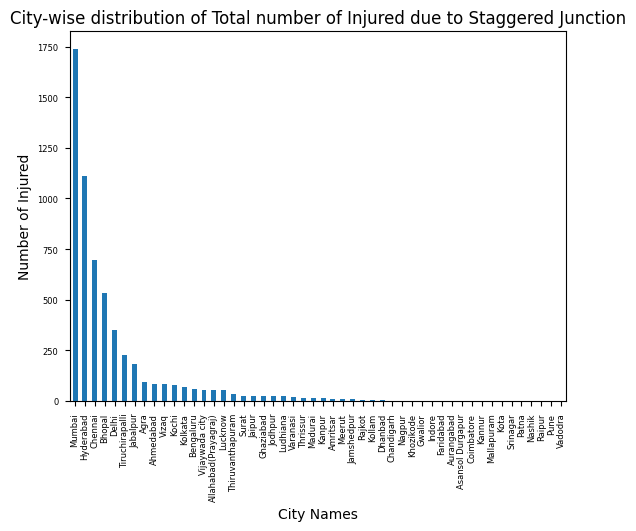

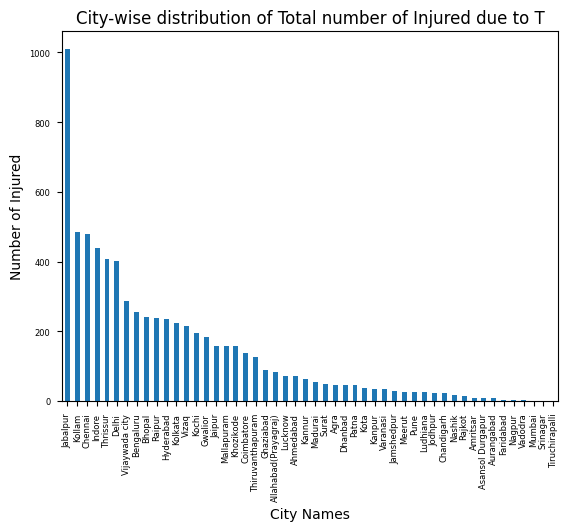

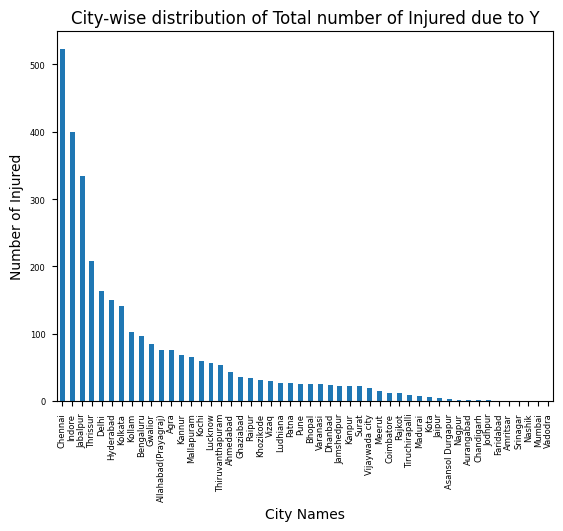

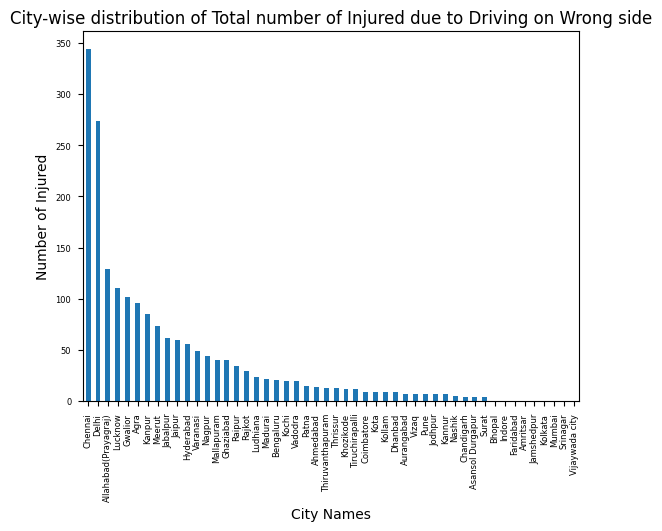

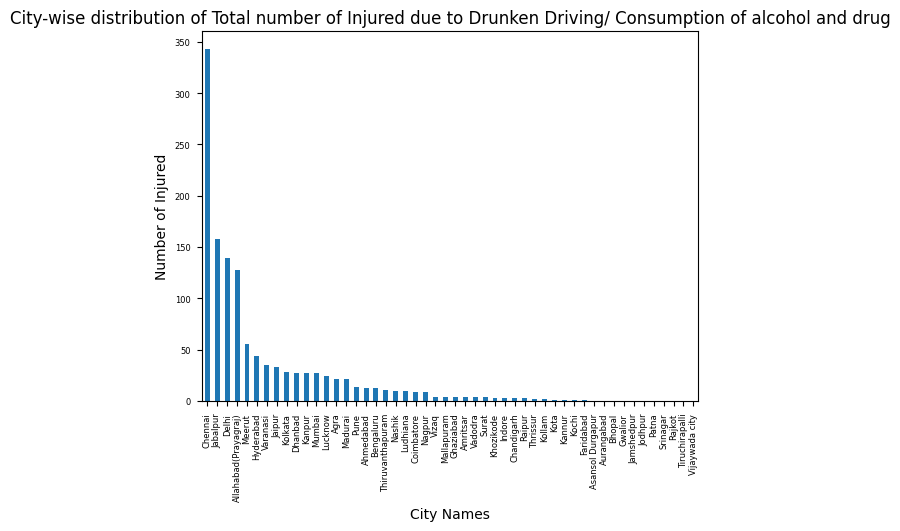

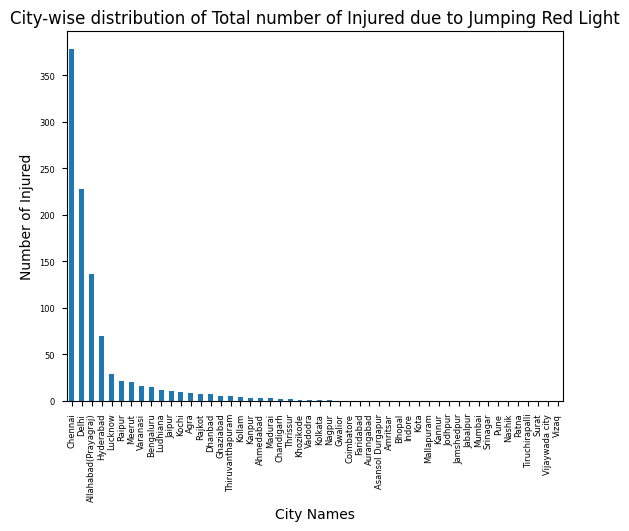

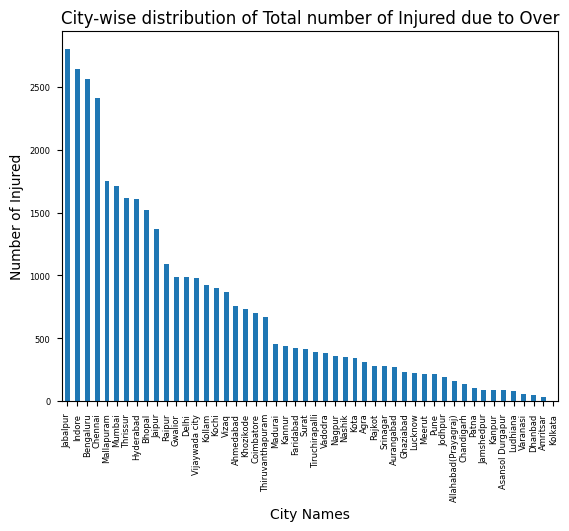

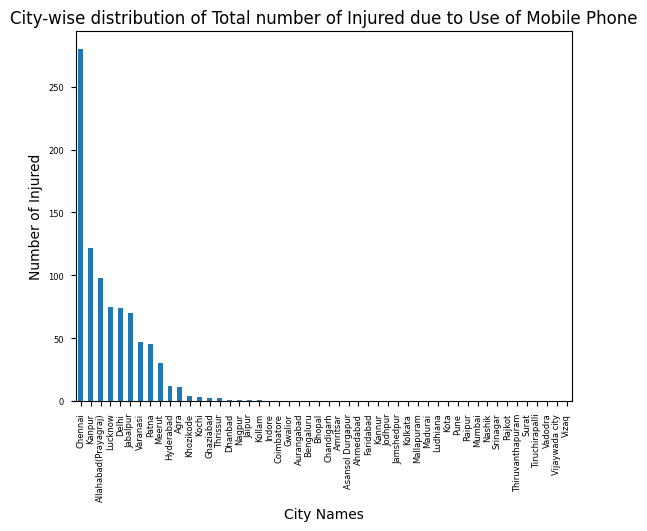

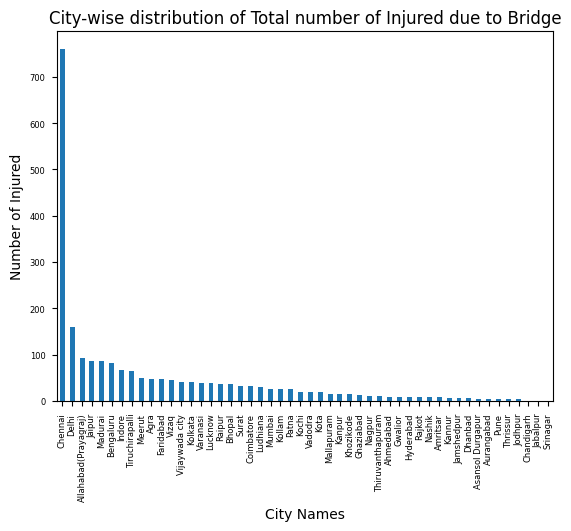

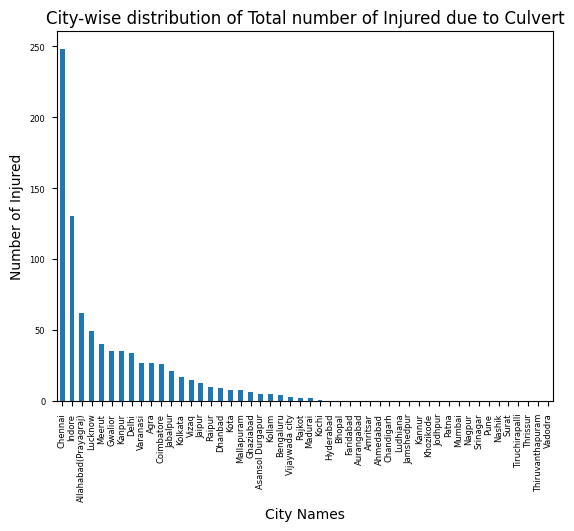

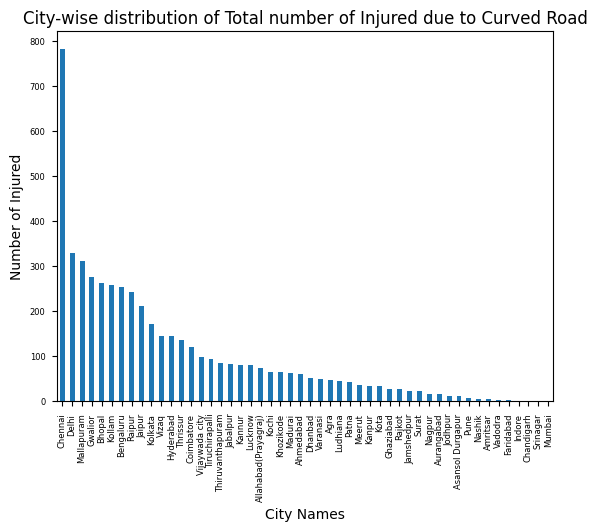

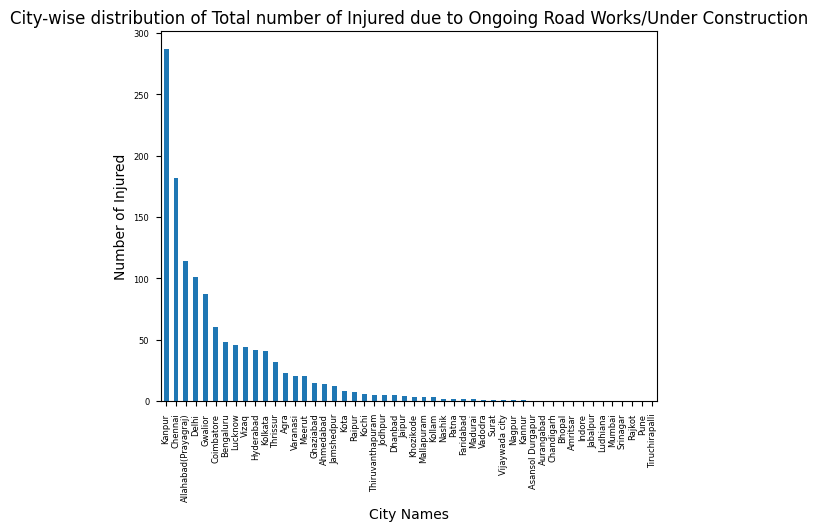

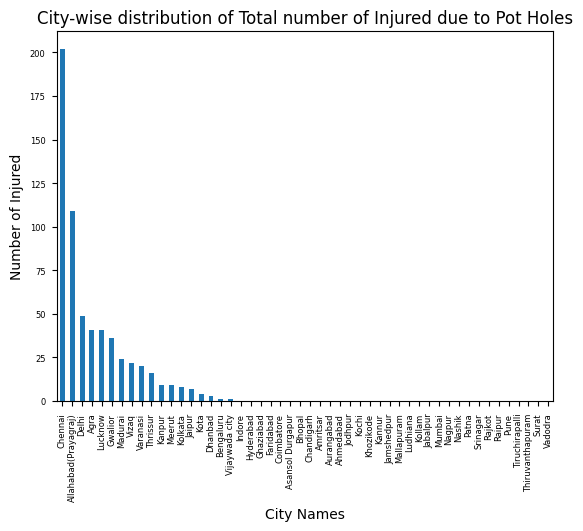

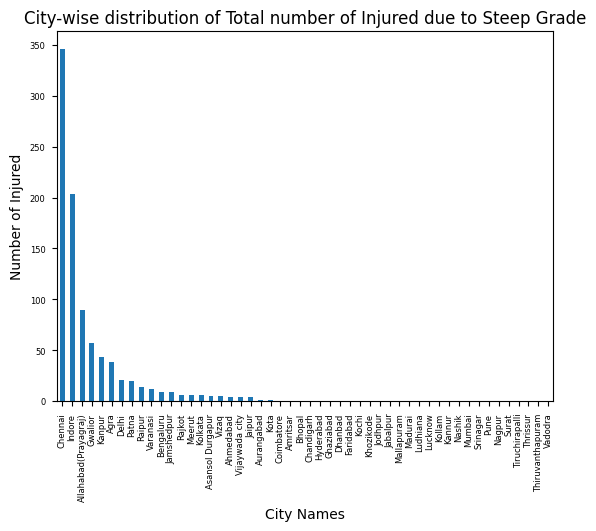

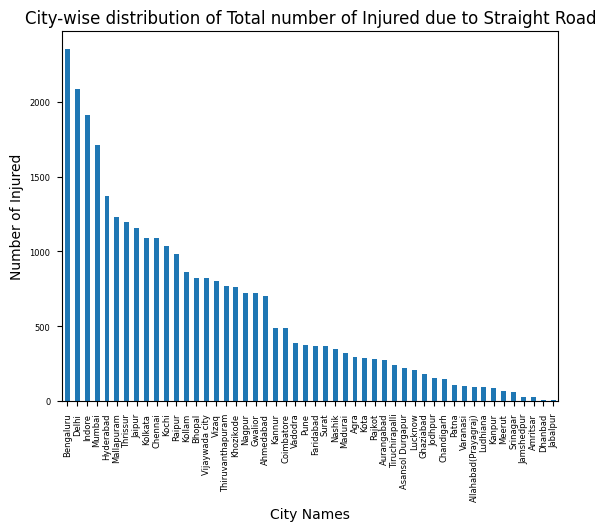

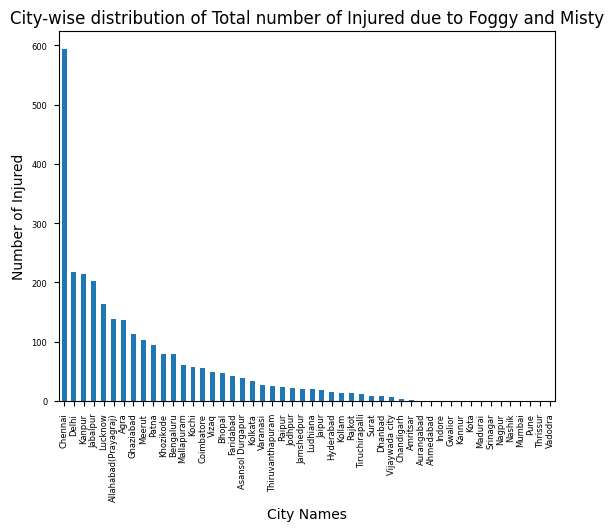

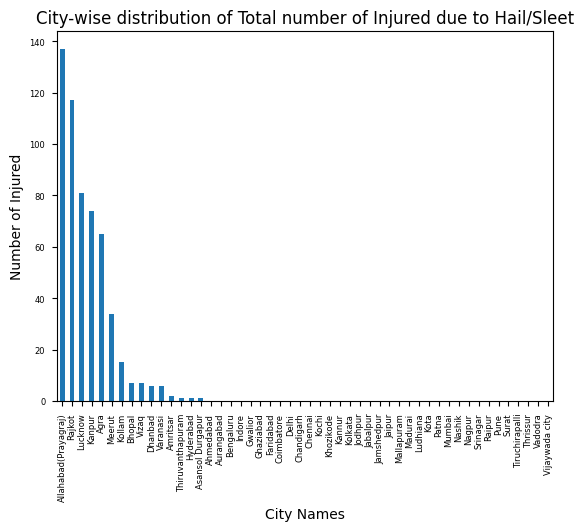

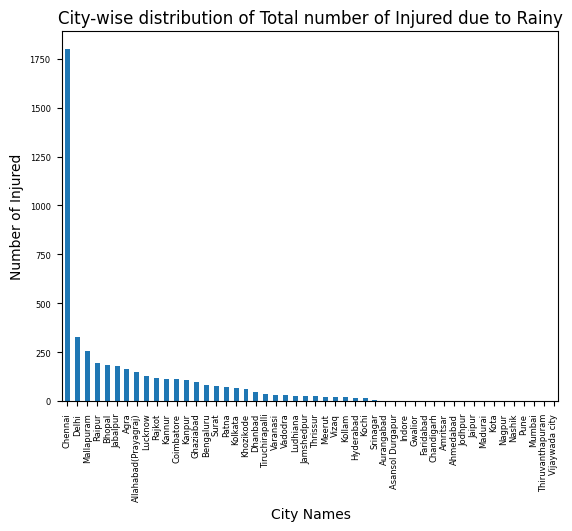

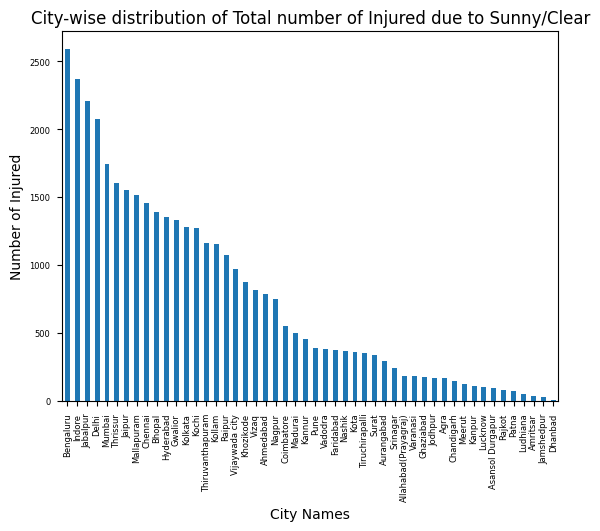

In [30]:
plt.figure(figsize=(30, 12))
plt.subplots_adjust(hspace=0.5, wspace= 0.3)

for label in injured_subcat_labels:
    label_mask = total_injured_mask[total_injured_mask['cause_subcategory'] ==label]
    subplot_label_mask = total_injured_mask[total_injured_mask['cause_subcategory']==label]
    subcat_injured = label_mask.groupby(['million_plus_cities']).agg('sum')[['count']].sort_values(by='count', ascending=False)
    #Create bar plot for each subcategory across cities
    subcat_injured.plot(kind='bar', title="City-wise distribution of Total number of Injured due to "+ label, xlabel="City Names", ylabel="Number of Injured", legend=False)
    plt.tick_params(pad=5, labelsize=6)
    plt.show()

Observations :
Chennai once again ranks highest in the total number of people injured, followed by Delhi, Jabalpur, Bengaluru, and Indore.

Amritsar reported the lowest number of injuries. The second- and third-lowest figures were recorded in Jamshedpur and Dhanbad, respectively.

Interestingly, although Bengaluru had more accidents than Jabalpur, their positions reverse when it comes to total injuries. Jabalpur recorded more injured individuals than Bengaluru during the same year.

Most injuries occurred on sunny/clear weather days, and predominantly on straight roads.

Overspeeding appears to be a major traffic violation contributing to accident-related injuries.

At junctions, T-junctions, staggered junctions, and four-arm junctions show nearly equal distributions in the number of people injured.

City-wise observations of accident injury causes (Top 3 Cities)

Some of the main reasons for accident injuries in Delhi are : Rainy, Foggy/Misty weathers, Straight Road, Curved Road, Bridge, due to Jumping Red Light, Driving on Wrong Side, Traffic Light Signal, and Flashing Signal/Blinker. Pot Hole, Stop Sign and Drunken Driving/ Consumption of alcohol and drug is another relatively important cause of Delhi accidents.

Chennai topped the list of cities in most number of people injured in accidents due to most of the causes/sub-categories. Some of the main causes are Rainy, Foggy/Misty weather, on roads with Steep Grade, Pot Holes, Curved Road, Culvert, Bridge, due to Use of Mobile Phone, Jumping Red Light, Drunken Driving/consumption of alcohol and drug, Driving on Wrong Side, in Y, Round about Junction, Traffic Light Signal, Police Controlled, and Flashing Signal/Blinker. Some of the other reasons are Ongoing Road Works/Under Construction, Staggered Junction, T and Four arm Junction.

Allahabad/Prayagraj topped the list of most accident injuries due to : Hail sleet. Some of the other reasons are : roads with Pot Holes, Steep Grade, Ongoing Road Works/Under Construction, Culvert, Bridge, due to Use of Mobile Phone, Jumping Red Light, and Driving on Wrong Side.

Most common reasons for accident injuries in Mumbai were : Staggered Junction, Uncontrolled Traffic.

Some common reasons for accident injuries in Indore were : Four arm Junction, Y junction, Round about Junction, Over Sunny/Clear weather, and Straight Road.

Common reason for accident injuries in Rajkot were : Hail/Sleet.

Common reason for accident injuries in Bengaluru were : Sunny/Clear weather and Straight Road. Some of the other reasons are Four arm Junction, Traffic Light Signal, Police Controlled.

Common reason for accident injuries in Mallapuram were : Rainy weather, Curved Road.

Most common reason for accident injuries in Jabalpur were : Over, in T junctions, due to Uncontrolled traffic. Some other reasons were : Drunken Driving/ Consumption of alcohol and drug, and Sunny/Clear weather.

Most common reason for accident injuries in Kollam were : in T junctions and due to Flashing Signal/Blinker.

Most common reason for accident injuries in Kochi were : Police Controlled traffic.

Most common reason for accident injuries in Bhopal were : due to Stop Sign.

Most common reason for accident injuries in Hyderabad were : in Staggered Junction, Round about Junction, and due to Uncontrolled traffic.

Most common reason for accident injuries in Kanpur were : Ongoing Road Works/Under Construction, and Foggy/Misty weather.

Most common reason for accident injuries in Lucknow were : Hail/Sleet.

Person Killed Analysis

In [31]:
#Create a mask with outcome : 'Persons killed'
total_killed_mask = df[df['outcome_of_incident'] == "Persons killed"]

Bar chart distribution of ancient deaths across cities

In [32]:
# Basic checks on the raw dataframe (replace `df` with whatever your original dataframe is named)
print("df shape:", df.shape)
print("columns:", df.columns.tolist())

# Try several likely column names for 'outcome'
for col in ['Outcome of Incident', 'outcome_of_incident', 'outcome', 'Outcome', 'Outcome_of_Incident']:
    if col in df.columns:
        print(f"\nUnique values in '{col}':")
        print(df[col].value_counts(dropna=False).head(50))


df shape: (9550, 5)
columns: ['million_plus_cities', 'cause_category', 'cause_subcategory', 'outcome_of_incident', 'count']

Unique values in 'outcome_of_incident':
outcome_of_incident
Greviously Injured           2000
Minor Injury                 2000
Persons Killed               2000
Total number of Accidents    2000
Total Injured                1550
Name: count, dtype: int64


total_killed_mask shape: (2000, 5)

Value counts for million_plus_cities (top 30):
million_plus_cities
Agra                    40
Ahmedabad               40
Allahabad(Prayagraj)    40
Amritsar                40
Asansol Durgapur        40
Aurangabad              40
Bengaluru               40
Bhopal                  40
Chandigarh              40
Chennai                 40
Coimbatore              40
Delhi                   40
Dhanbad                 40
Faridabad               40
Ghaziabad               40
Gwalior                 40
Hyderabad               40
Indore                  40
Jabalpur                40
Jaipur                  40
Jamshedpur              40
Jodhpur                 40
Kannur                  40
Kanpur                  40
Khozikode               40
Kochi                   40
Kolkata                 40
Kollam                  40
Kota                    40
Lucknow                 40
Name: count, dtype: int64

Aggregated killed by million_plus_cities (top 20):
million_p

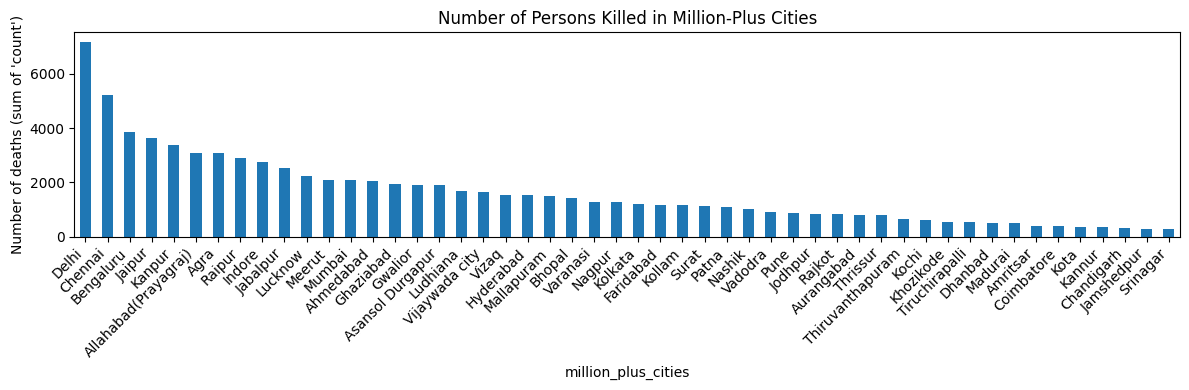

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) create mask for persons killed using the exact label found in your data
total_killed_mask = df[df['outcome_of_incident'].astype(str).str.strip() == 'Persons Killed'].copy()
print("total_killed_mask shape:", total_killed_mask.shape)

# 2) Inspect million_plus_cities column and normalize it
if 'million_plus_cities' not in total_killed_mask.columns:
    raise KeyError("'million_plus_cities' column not found in dataframe.")

# Normalize strings: strip whitespace and replace blanks with NaN
total_killed_mask['million_plus_cities'] = total_killed_mask['million_plus_cities'].astype(str).str.strip()
total_killed_mask.loc[total_killed_mask['million_plus_cities'].isin(['', 'nan', 'None', 'NoneType']), 'million_plus_cities'] = pd.NA

# Print value counts to ensure we have categories
print("\nValue counts for million_plus_cities (top 30):")
print(total_killed_mask['million_plus_cities'].value_counts(dropna=False).head(30))

# 3) Ensure 'count' exists and is numeric; if missing, create as 1 per row
if 'count' in total_killed_mask.columns:
    total_killed_mask['count'] = pd.to_numeric(total_killed_mask['count'], errors='coerce')
    # If every count is NaN, fall back to 1 per row
    if total_killed_mask['count'].dropna().empty:
        print("\nWarning: 'count' column present but all NaN — creating fallback counts = 1 per row.")
        total_killed_mask['count'] = 1
else:
    print("\nWarning: 'count' column missing — creating counts = 1 per row.")
    total_killed_mask['count'] = 1

# 4) Group and plot (safe)
cat_grp_killed = total_killed_mask.groupby('million_plus_cities')['count'].sum().sort_values(ascending=False)
print("\nAggregated killed by million_plus_cities (top 20):")
print(cat_grp_killed.head(20))

if cat_grp_killed.empty:
    print("\nNo data available to plot after filtering. Please check million_plus_cities values above.")
else:
    plt.figure(figsize=(12, 4))
    cat_grp_killed.plot(kind='bar', title="Number of Persons Killed in Million-Plus Cities", legend=False)
    plt.xlabel("million_plus_cities")
    plt.ylabel("Number of deaths (sum of 'count')")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


<Figure size 5000x1500 with 0 Axes>

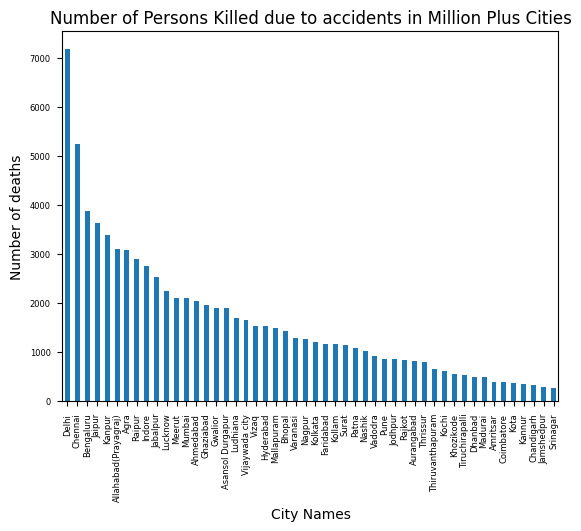

In [34]:
plt.figure(figsize=(50, 15))

# Group by cities w.r.t outcome : 'Persons Killed'
cat_grp_killed = total_killed_mask.groupby(['million_plus_cities']).agg('sum')[['count']]\
    .sort_values(by='count', ascending=False)

# Create a Barplot of Persons Killed w.r.t cities
cat_grp_killed.plot(kind="bar", title="Number of Persons Killed due to accidents in Million Plus Cities", legend=False, xlabel="City Names", ylabel="Number of deaths")

plt.tick_params(pad=5, labelsize=6)
plt.show()


Percentage Distribution of accidents deaths across cities

In [35]:
#Calculate % of killed w.r.t cities
cat_grp_killed['percentage'] = cat_grp_killed.transform(lambda x: (x / x.sum()) * 100)
cat_grp_killed

,count,percentage
million_plus_cities,,
Delhi,7176.0,8.831783
Chennai,5232.0,6.439226
Bengaluru,3876.0,4.770344
Jaipur,3636.0,4.474967
Kanpur,3378.0,4.157436
Allahabad(Prayagraj),3102.0,3.817752
Agra,3084.0,3.795599
Raipur,2892.0,3.559297
Indore,2754.0,3.389455


Study w.r.t Cause Category and Sub-category

In [36]:
killed_subcat_labels = total_killed_mask['cause_subcategory'].unique()

<Figure size 5000x2000 with 0 Axes>

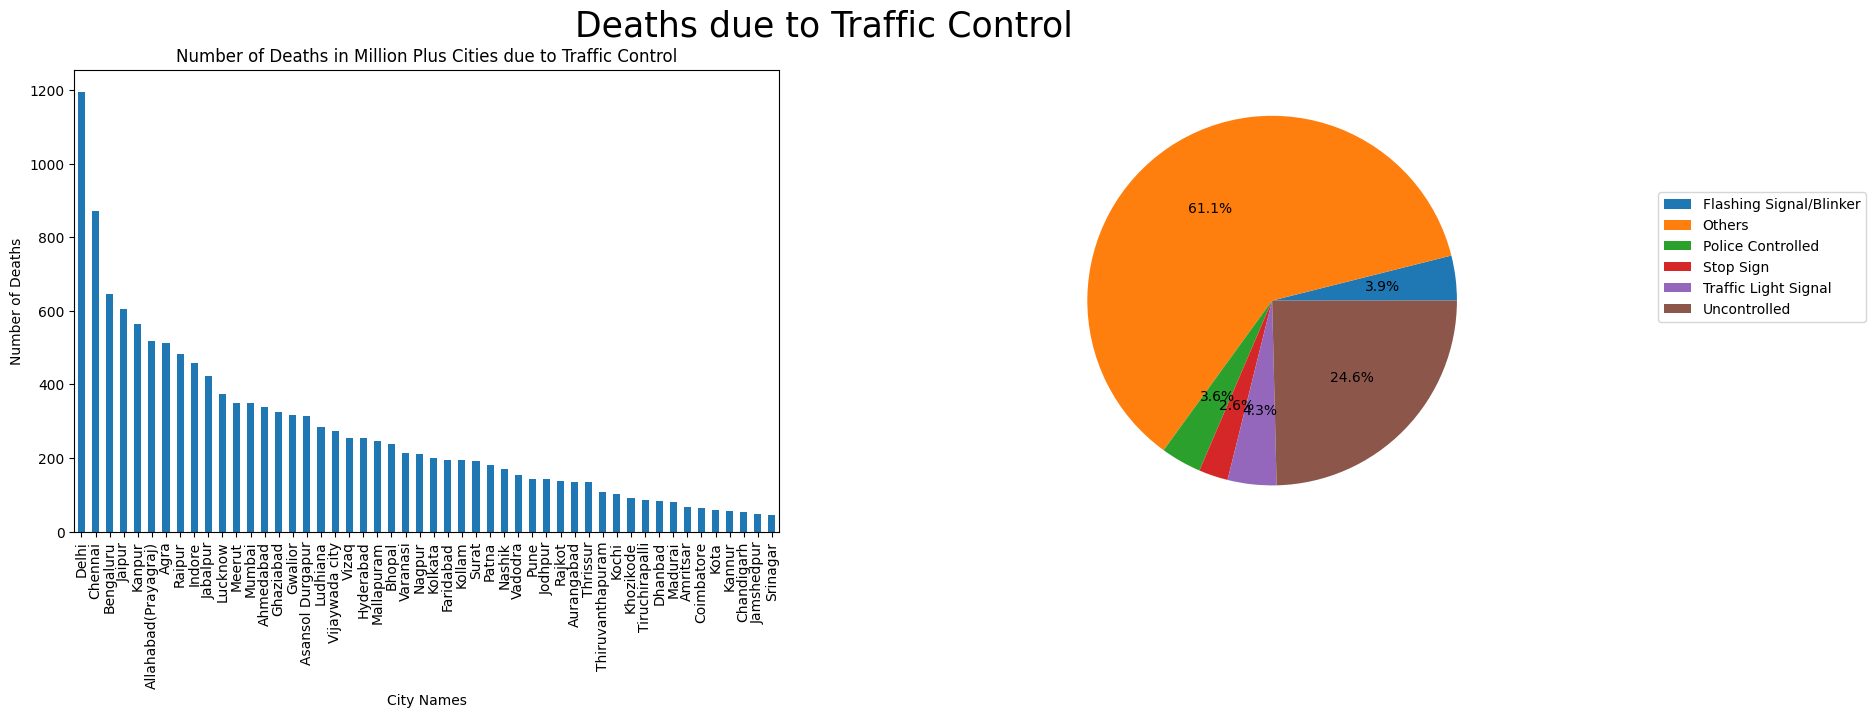

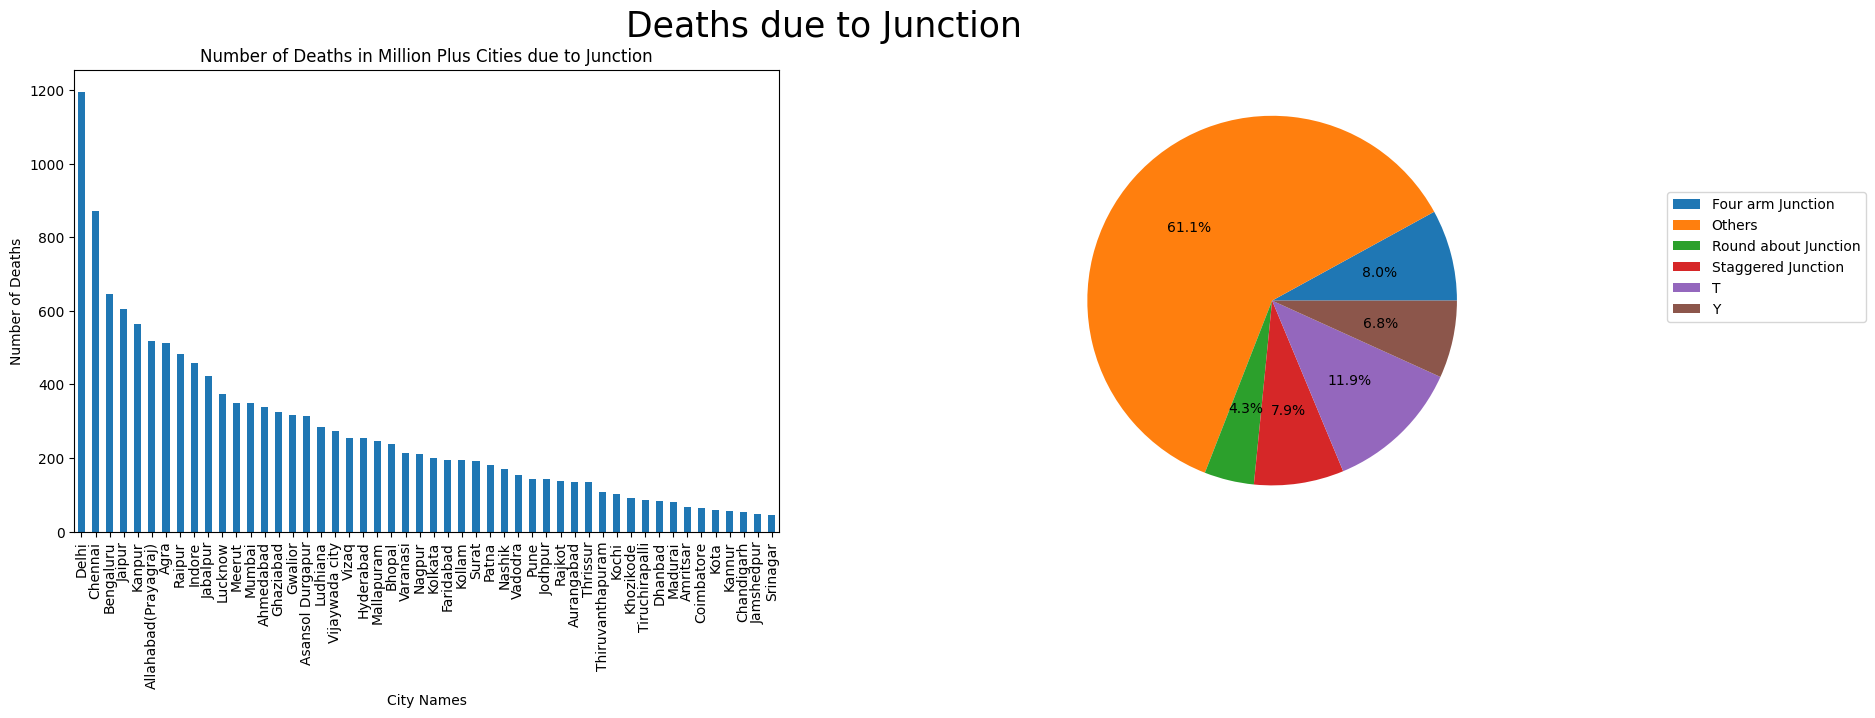

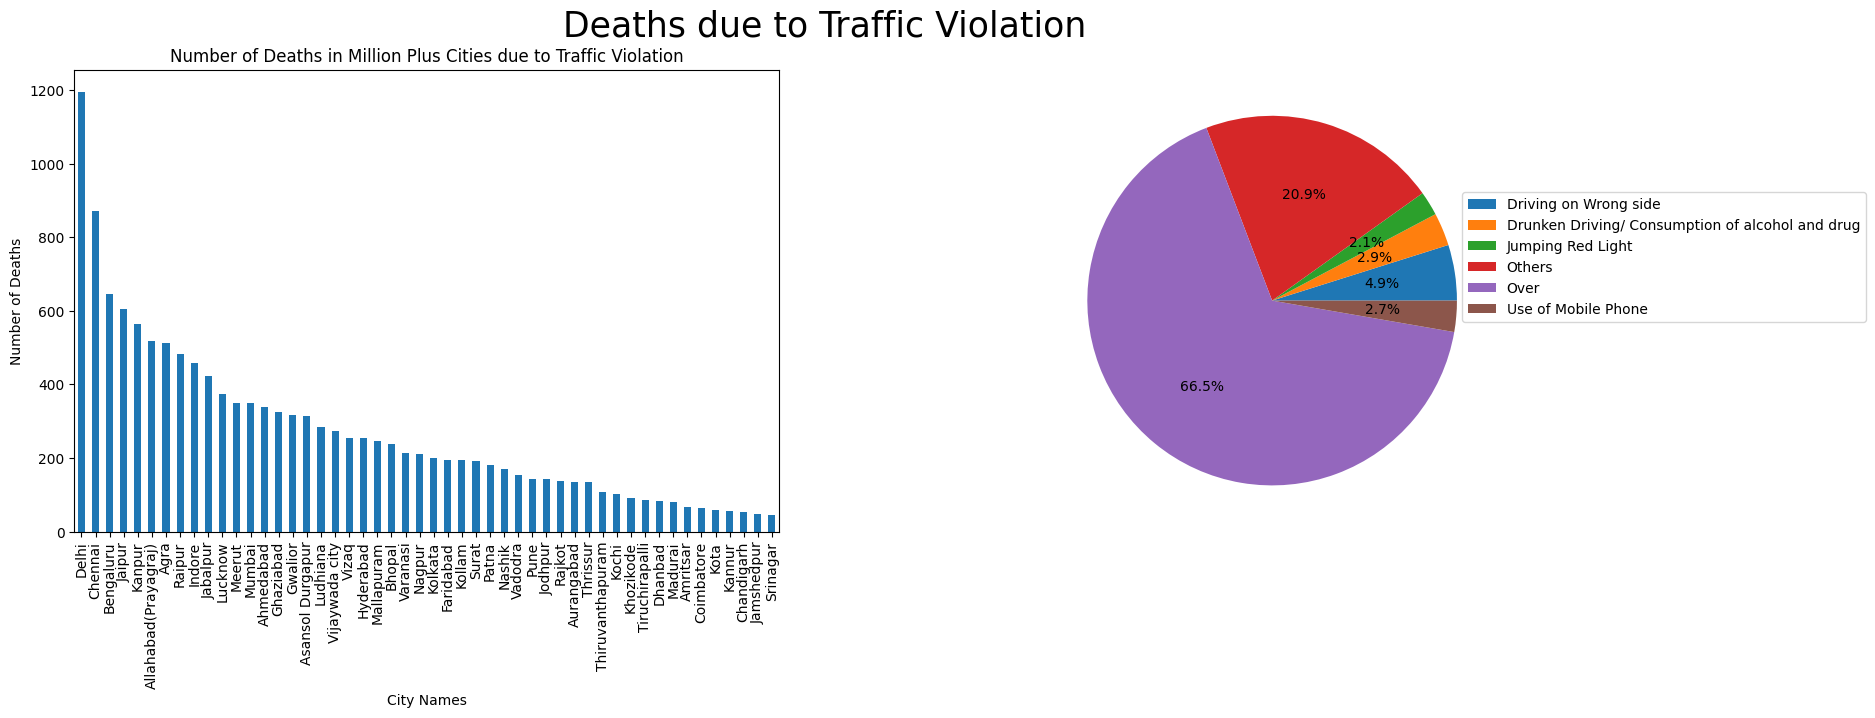

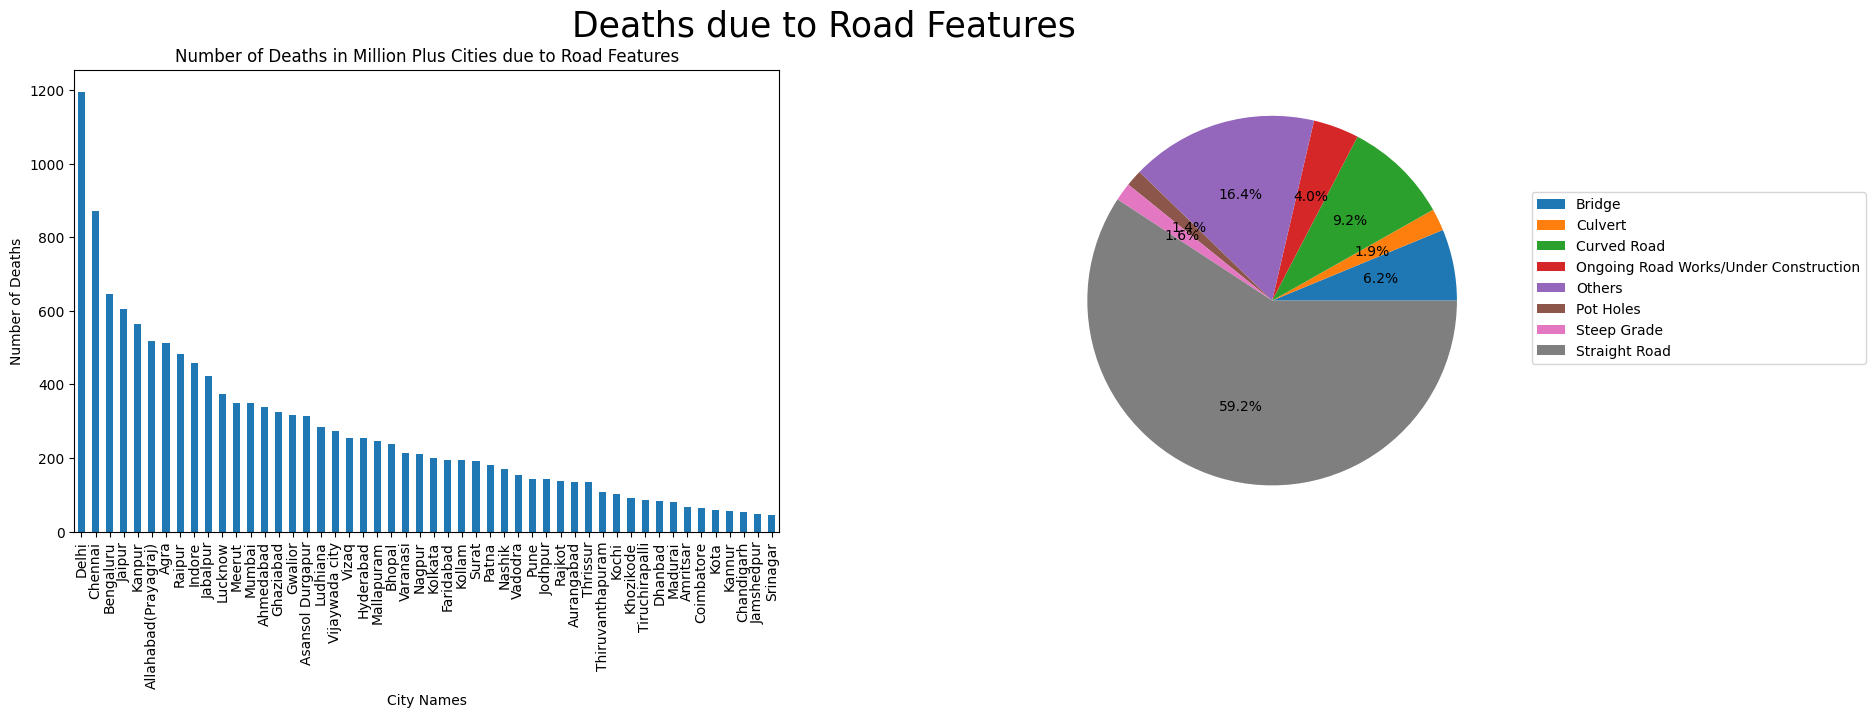

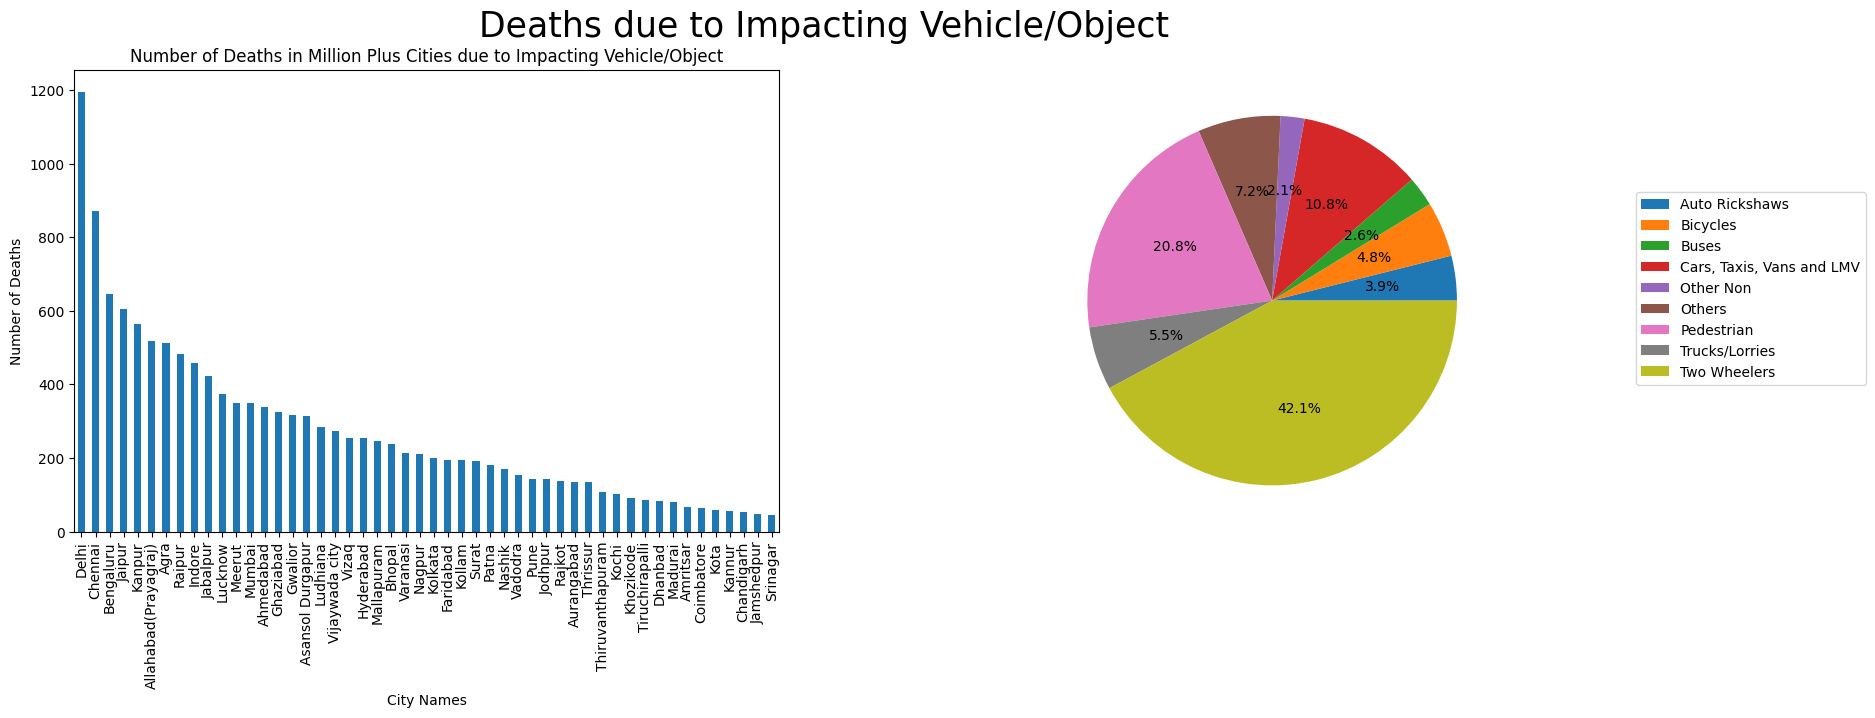

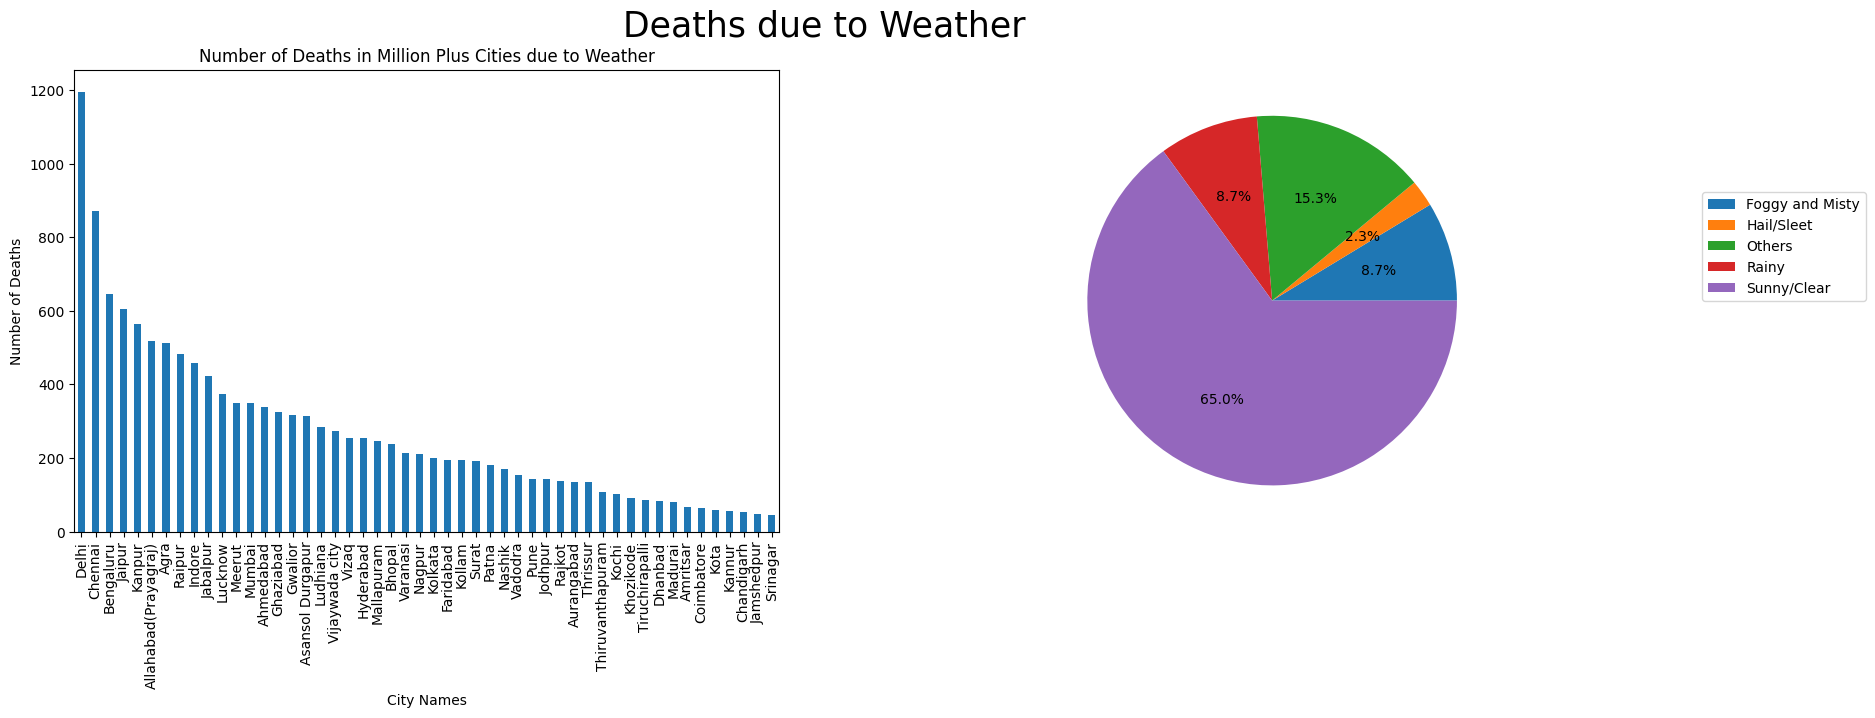

In [37]:
#Create a list of the unique cause subcategories for the outcome : 'Persons Killed'
killed_cat_labels = total_killed_mask['cause_category'].unique()

plt.figure(figsize=(50, 20))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

#for each cause category create plots
for label in killed_cat_labels:
    #Create a figure for each cause category with 2 axes
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    #Add title to the main figure
    plt.suptitle("Deaths due to "+label, fontsize=25, horizontalalignment='center')

    #Creata a mask to filter out the data for each cause category
    label_mask = total_killed_mask[total_killed_mask['cause_category'] == label]

    #Group by the locations and creata a bar chart based on each cause category
    cat_killed = label_mask.groupby(['million_plus_cities']).agg('sum')[['count']].sort_values(by='count', ascending=False)
    cat_killed.plot(kind='bar', legend=False, title="Number of Deaths in Million Plus Cities due to "+label, ax=axes[0], xlabel="City Names", ylabel="Number of Deaths")

    #Improve spacing of labels in the plotted bar chart
    plt.tick_params(pad=5, labelsize=6)

    #Group by related subcategories of the cause category and create a pie chart of the cause sub-category
    subcat_labels_grp = label_mask.groupby(['cause_subcategory']).agg('sum')[['count']]
    subcat_labels_grp.plot(kind='pie', subplots=True, ylabel='', labeldistance=None, ax=axes[1], autopct='%1.1f%%')

    #Adjust spacing og legends in the pie chart
    plt.legend(bbox_to_anchor=(1.8, .75), loc="upper right")
    plt.show()


List of Cause sub-categories with top 3 cities

In [38]:
cause_city_df = pd.DataFrame(columns=['cause_sub_category', 'top_cities'])
for label in killed_subcat_labels:
    label_mask = total_killed_mask[total_killed_mask['cause_subcategory']==label]
    
    subcat_label_mask = total_killed_mask[total_killed_mask['cause_subcategory']==label]
    subcat_killed = subcat_label_mask.groupby(['million_plus_cities']).agg('sum')[['count']].sort_values(by='count', ascending=False)

    #top 3 cities in subcategory
    top_3_cities = subcat_killed.head(3).reset_index()[['million_plus_cities']]
    cause_city_row = top_3_cities.apply(", ".join)
    data = pd.DataFrame({
            'cause_sub_category' : [label],
            'top_cities' : cause_city_row['million_plus_cities']
    })
    cause_city_df = pd.concat([cause_city_df, data])
cause_city_df

,cause_sub_category,top_cities
0,Flashing Signal/Blinker,"Chennai, Delhi, Ludhiana"
0,Others,"Delhi, Kanpur, Meerut"
0,Police Controlled,"Chennai, Allahabad(Prayagraj), Bengaluru"
0,Stop Sign,"Chennai, Allahabad(Prayagraj), Delhi"
0,Traffic Light Signal,"Delhi, Chennai, Jaipur"
0,Uncontrolled,"Mumbai, Delhi, Hyderabad"
0,Four arm Junction,"Delhi, Chennai, Allahabad(Prayagraj)"
0,Round about Junction,"Chennai, Allahabad(Prayagraj), Delhi"
0,Staggered Junction,"Chennai, Hyderabad, Delhi"
0,T,"Raipur, Jabalpur, Delhi"


Bar Chart for each SubCategory across cities

<Figure size 1200x400 with 0 Axes>

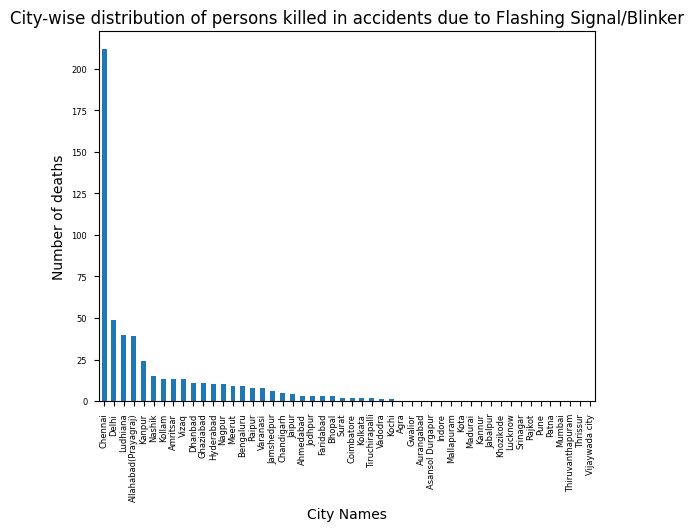

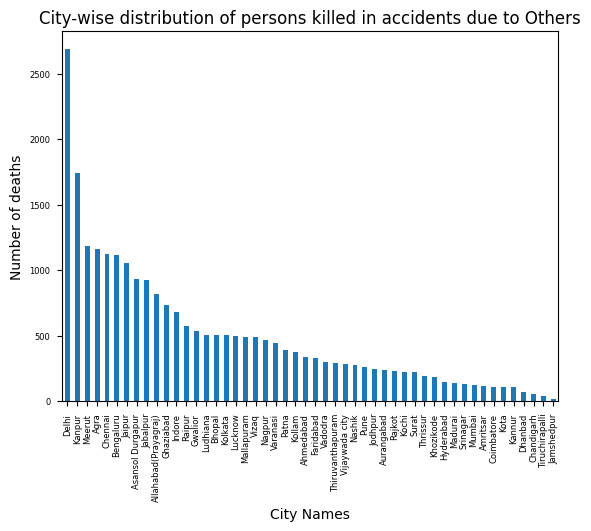

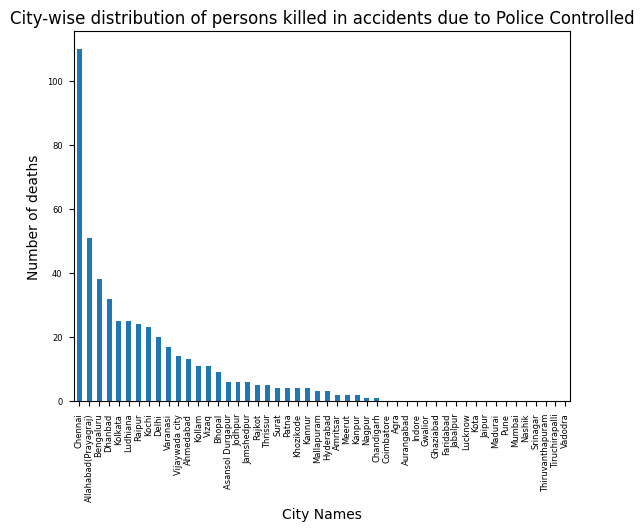

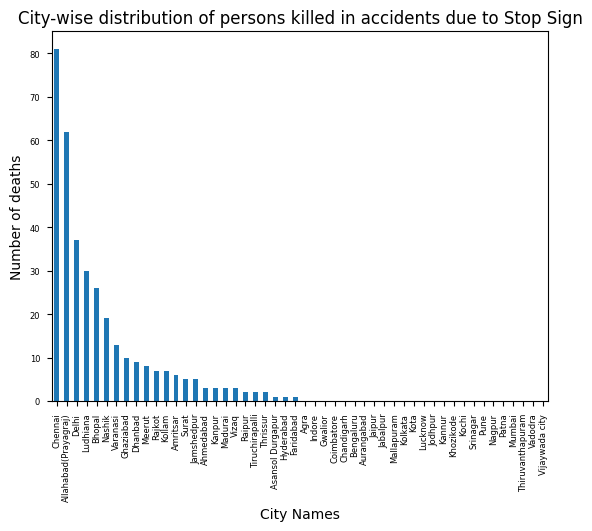

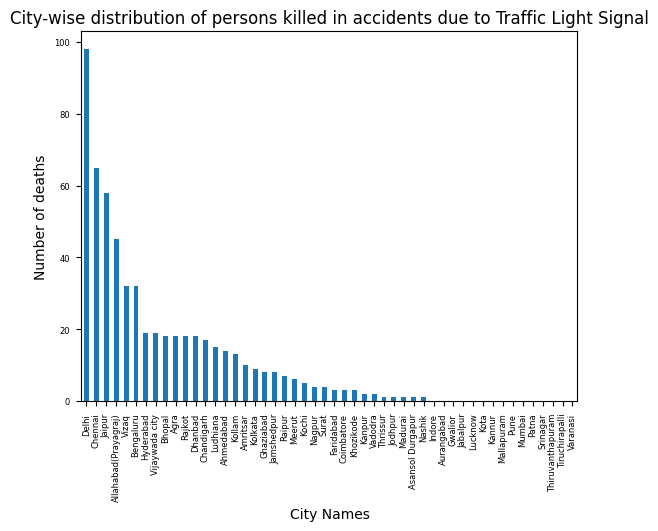

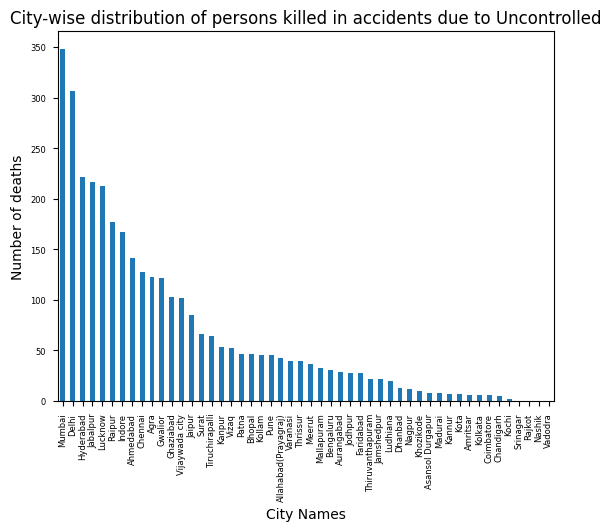

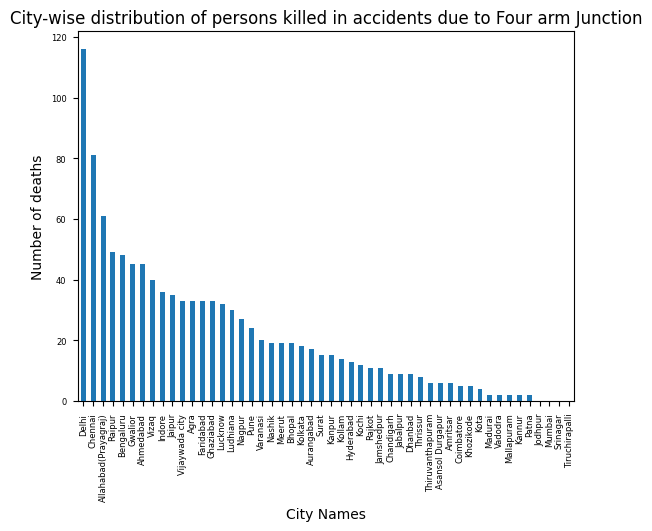

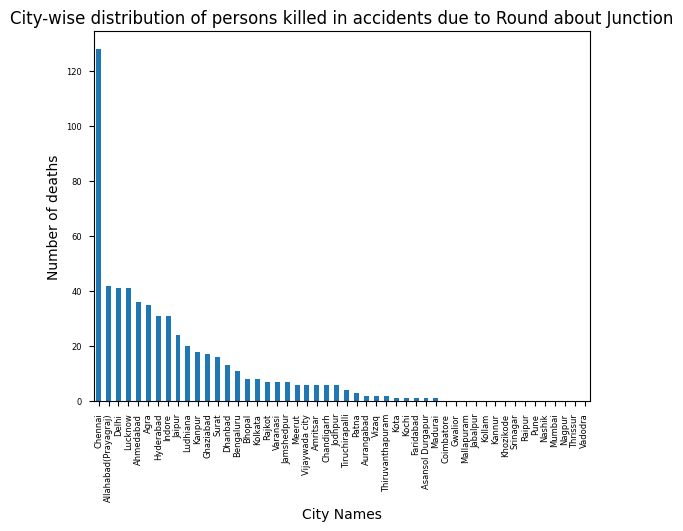

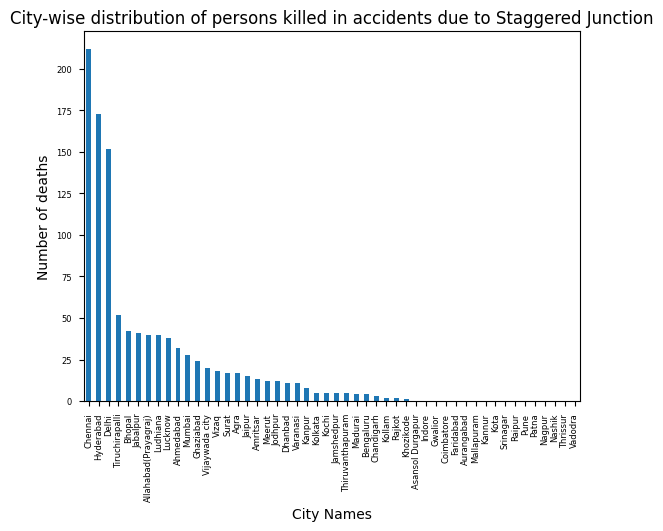

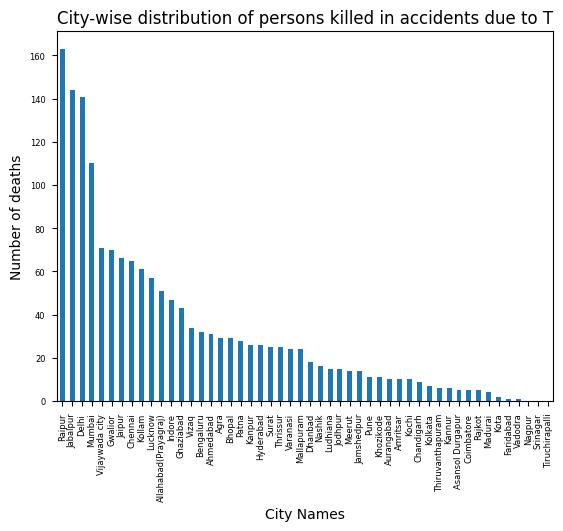

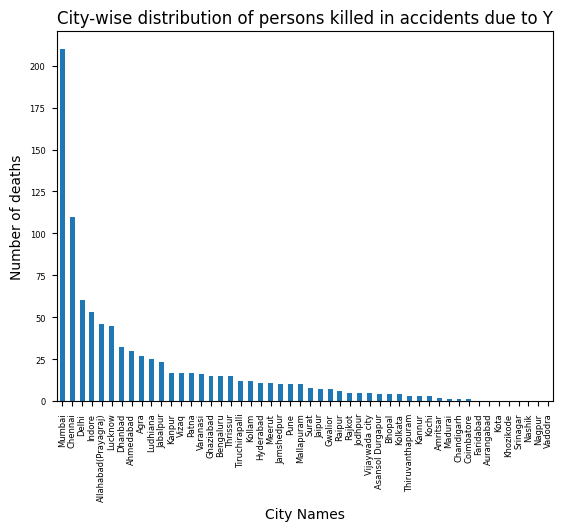

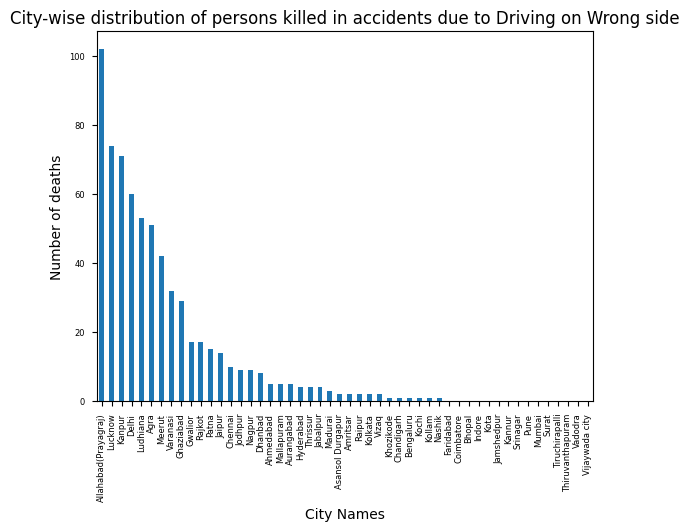

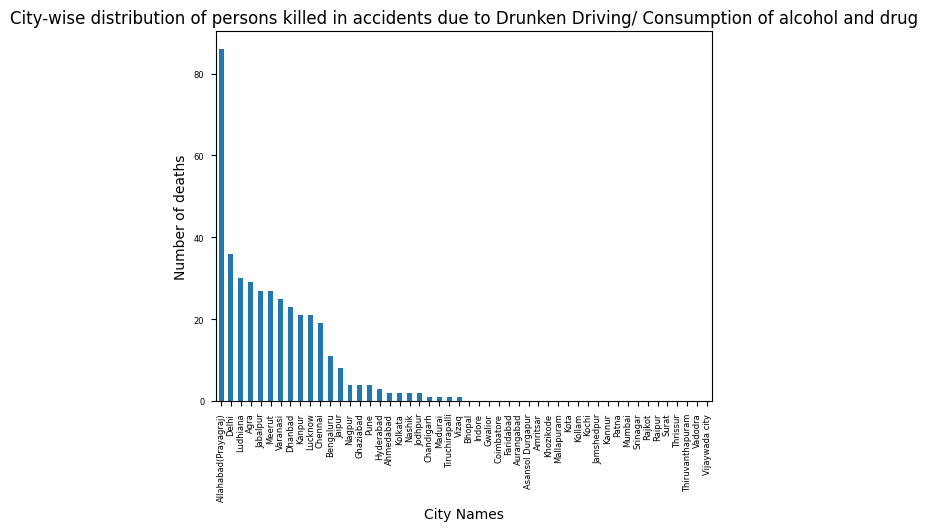

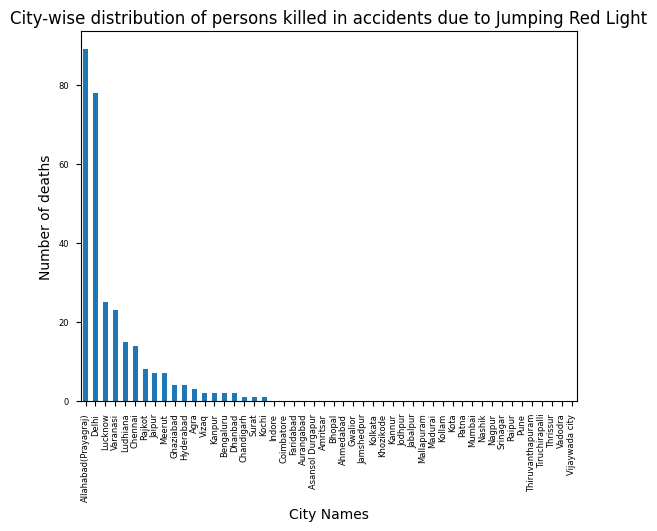

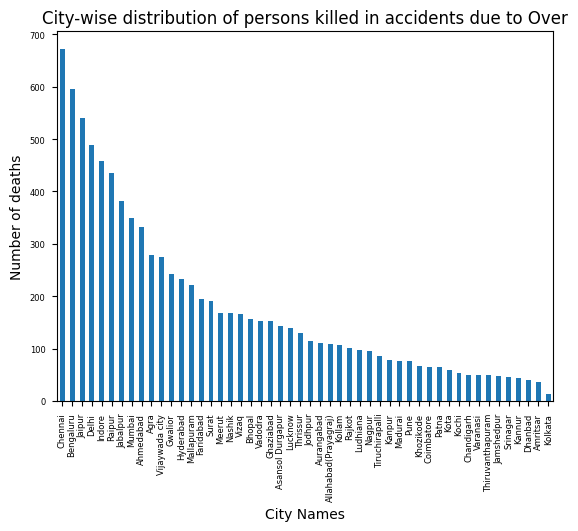

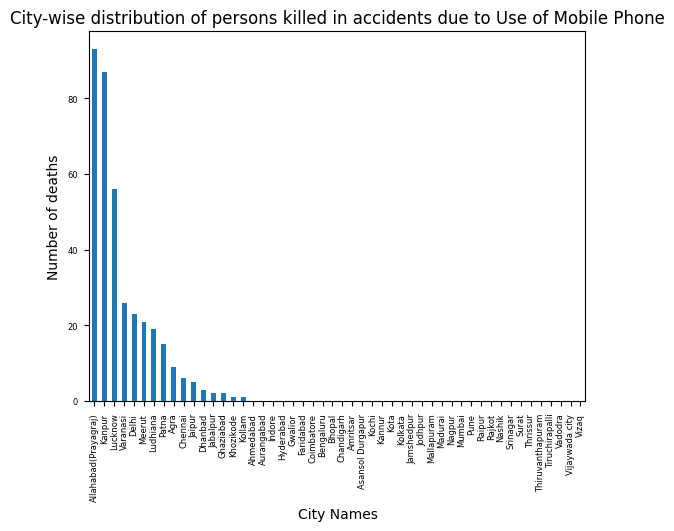

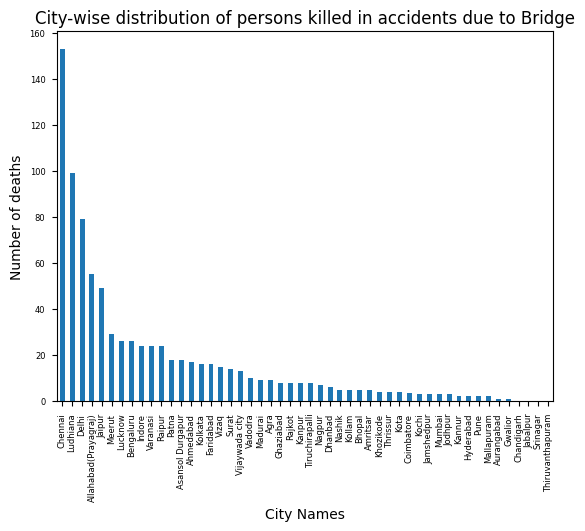

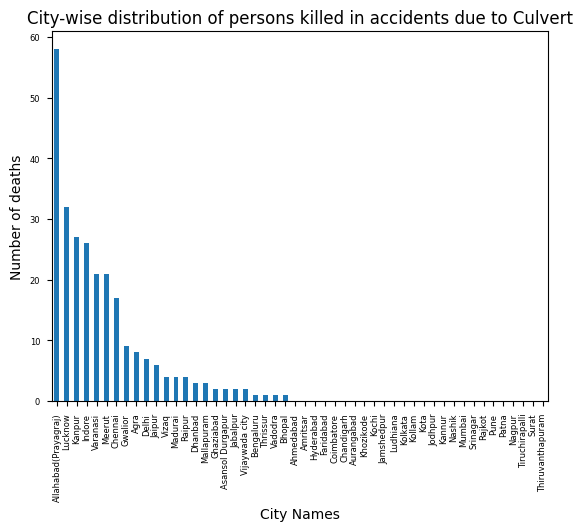

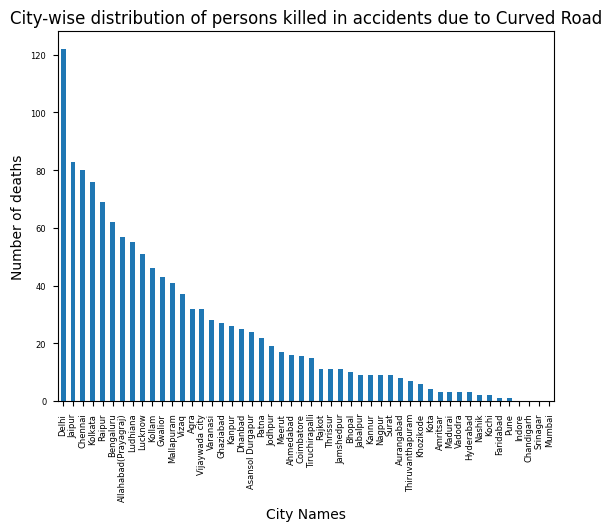

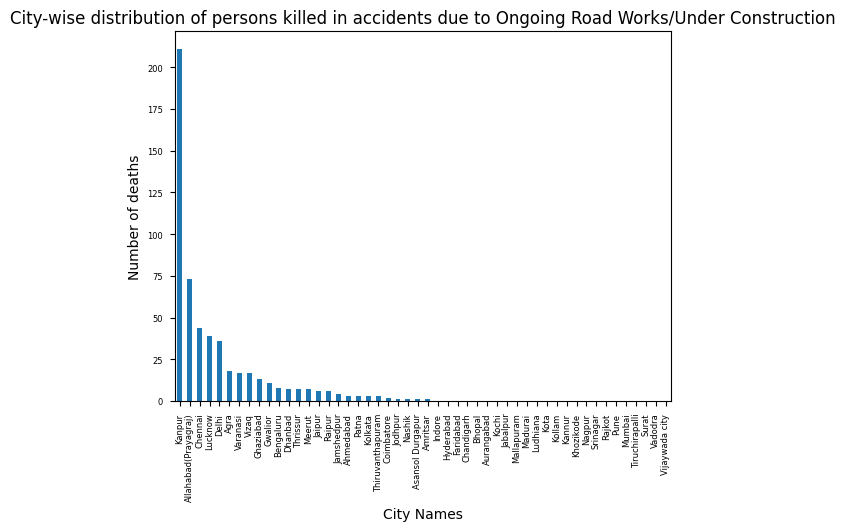

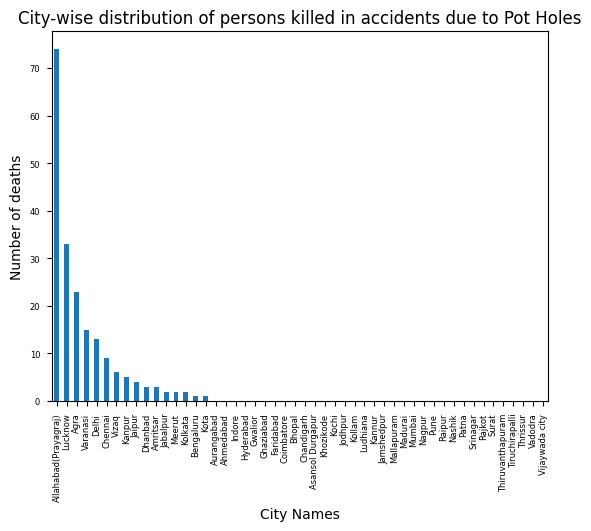

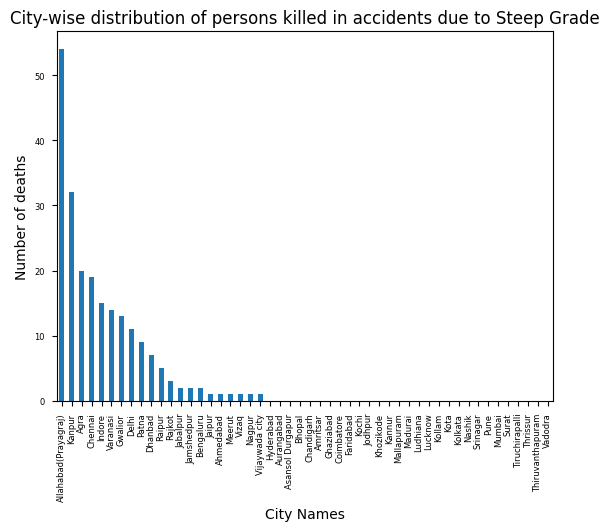

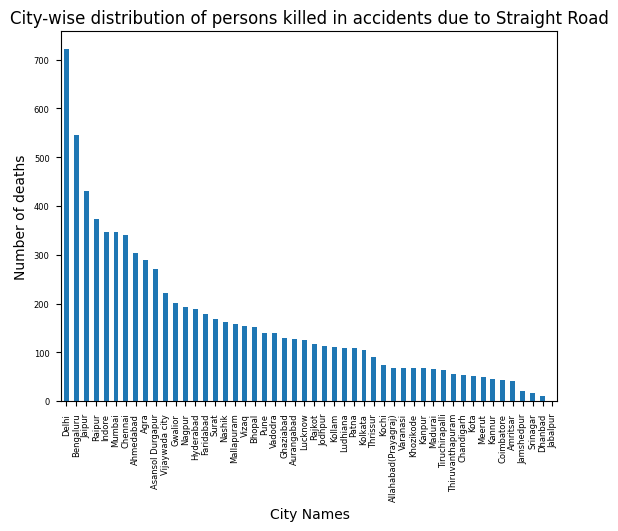

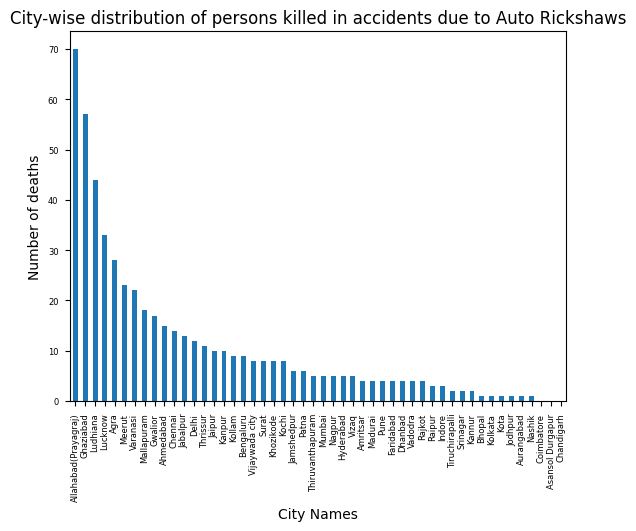

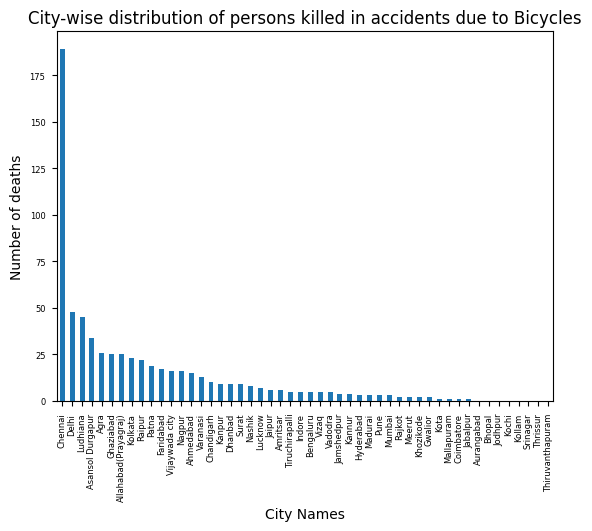

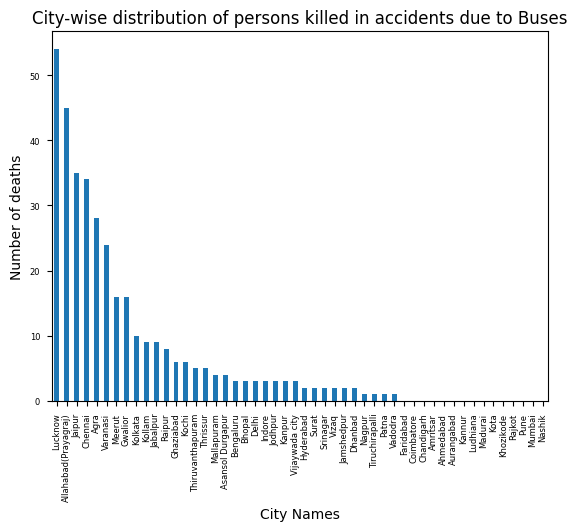

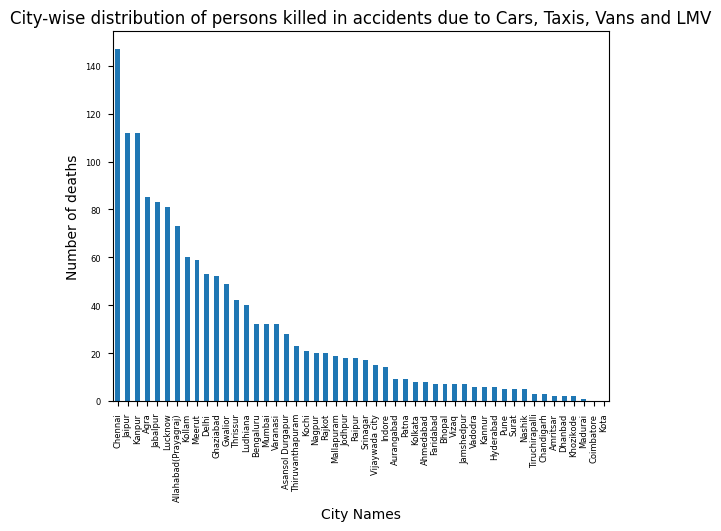

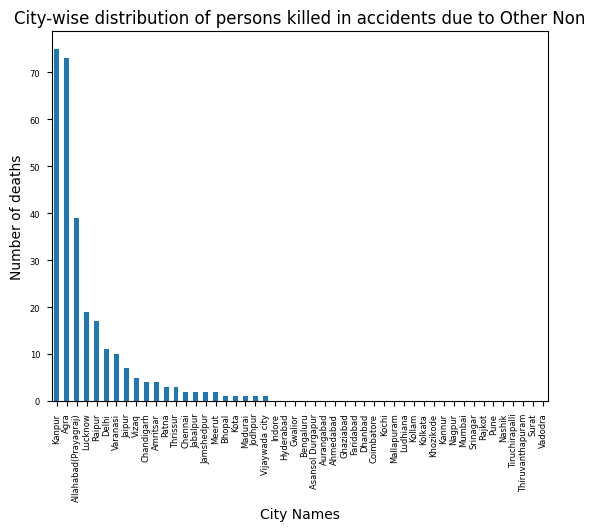

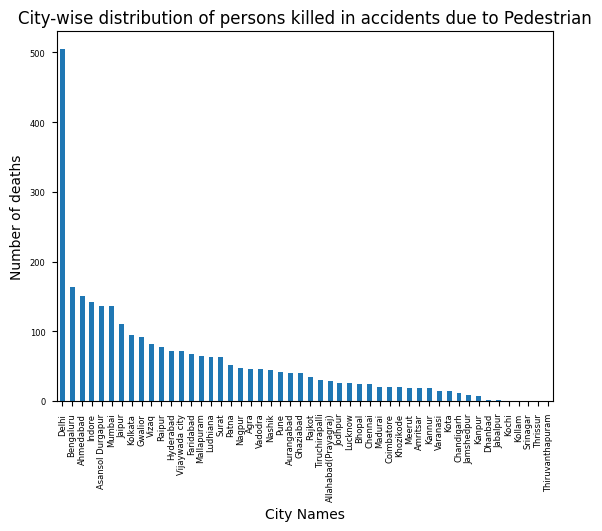

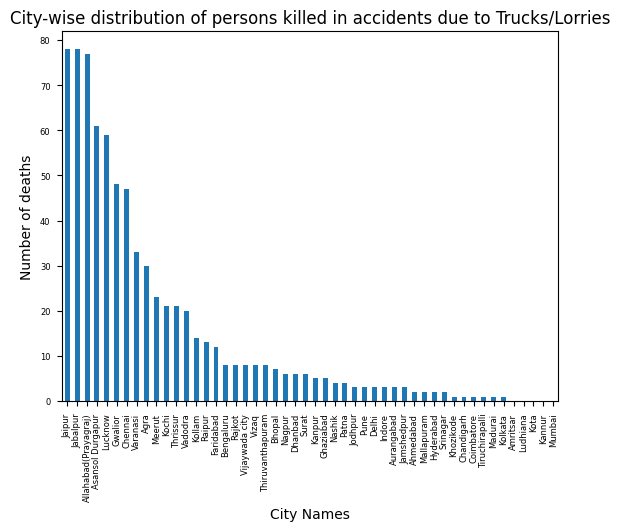

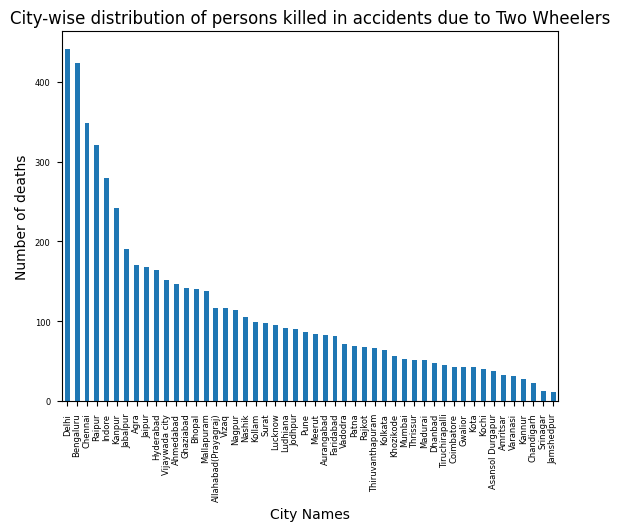

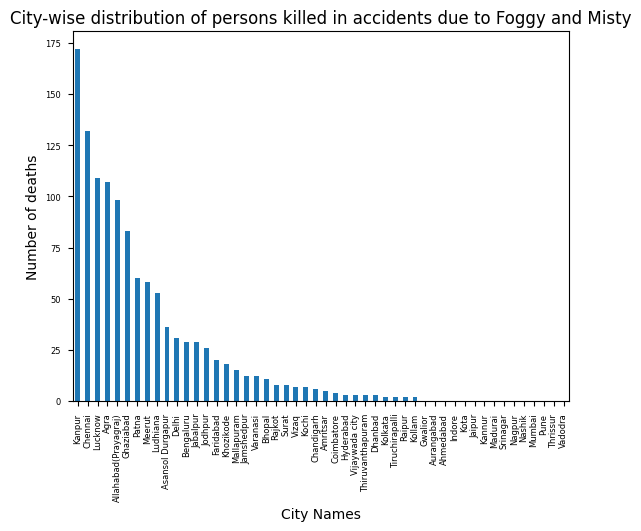

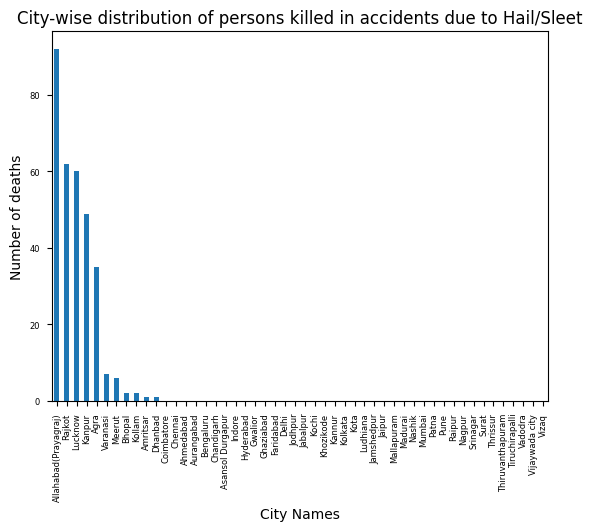

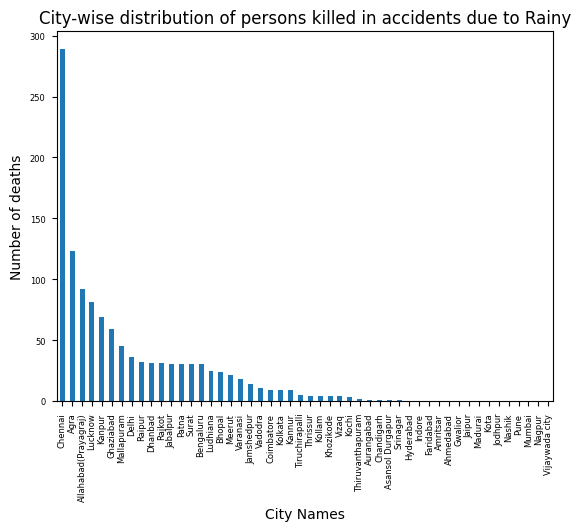

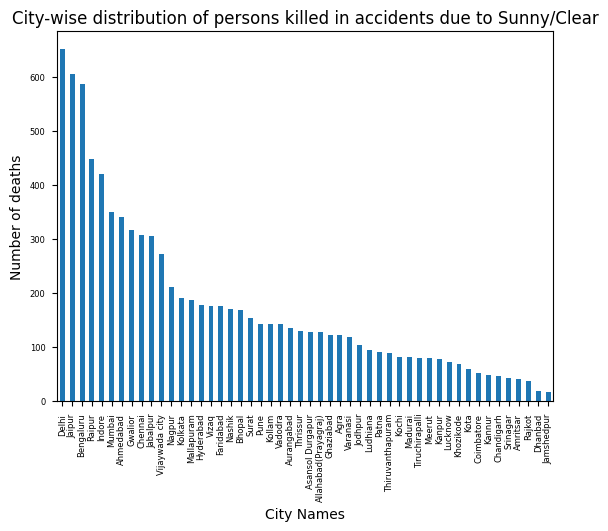

In [39]:
plt.figure(figsize=(12, 4))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

for label in killed_subcat_labels:

    #Create a maks to filter out the data for each cause subcategory
    label_mask = total_killed_mask[total_killed_mask['cause_subcategory'] == label]
    subcat_killed = label_mask.groupby(['million_plus_cities']).agg('sum')[['count']].sort_values(by='count', ascending=False)
    
    subcat_killed.plot(kind='bar', title="City-wise distribution of persons killed in accidents due to "+ label, legend=False, xlabel="City Names", ylabel="Number of deaths")
    plt.tick_params(pad=5, labelsize=6)
    plt.show()

City Fatality Rankings
When measured by the number of persons killed, the top five most fatal cities are:

Delhi (Most Fatal)

Chennai

Bangaluru

Jaipur

Kanpur

Conversely, Srinagar reports the least fatal accidents, followed by Jamshedpur and Chandigarh as the second and third least fatal, respectively.

Disproportionate Fatality Rates
Certain cities show a high fatality ranking despite a lower overall volume of accidents, indicating a higher severity per incident:

Jaipur is a clear example of highly fatal accidents. While ranking 8th in total accidents and 11th in total injured persons, it jumps to 4th place in terms of fatalities (Persons Killed).

Kanpur demonstrates an even more extreme difference. Ranked 18th in total accidents and 21st in total injured, its accidents are exceptionally severe, pushing it to the 5th position for persons killed.

Primary Causes and Conditions
The data highlights two key contributing factors to fatal accidents:

Vehicle Type: Two Wheelers are the most common vehicles involved in fatal accidents.

Driver Behavior: Overspeeding is noted as one of the most frequent causes.

Furthermore, fatal accidents are most prevalent under specific environmental conditions:

Weather: The majority of fatal incidents occur in Sunny/Clear weather.

Road Geometry: Accidents leading to the most deaths occur primarily on Straight Roads.

The highest number of fatalities under these clear weather/straight road conditions are recorded in Delhi, Jaipur, and Bangaluru.

City-Specific Fatality Drivers: A Detailed Breakdown

Cities with Broad Fatality Causes

Delhi : Weather: Sunny/Clear. Vehicle: Two Wheelers, Pedestrian. Road Geometry: Straight Road, Curved Road. Junction Type: Four-arm Junction, Traffic Light Signal.

Chennai: Weather: Rainy. Vehicle: Cars/Taxis/Vans/LMV, Bicycles. Road Features: Bridge, Staggered Junction, Roundabout, Stop Sign. Traffic Control: Police Controlled. Driver Action: Over (Overspeeding).

Allahabad (Prayagraj): Weather: Hail/Sleet. Vehicle: Auto Rickshaws. Road Features: Steep Grade, Pot Holes, Culvert. Driver Action: Use of Mobile Phone, Jumping Red Light, Drunken Driving/Drugs, Driving on Wrong Side.

Cities Known for Specific Fatality Factors: 

City	Top Ranking Fatality Cause

Mumbai	Junction Type: Y Junction. Traffic Control: Uncontrolled Traffic.

Raipur	Junction Type: T Junction.

Jaipur	Vehicle Type: Truck/Lorries.

Kanpur	Weather: Foggy/Misty. Road Condition: Ongoing Road Works/Under Construction.

Rajkot	Weather: Hail/Sleet.

Cities with Notable Fatality Trends

Bengaluru: Fatality is highly common due to Two Wheelers, incidents on Straight Roads, Overspeeding, and Pedestrian involvement, often occurring on Sunny/Clear days with Police Controlled traffic.

Lucknow: Notable for deaths involving Buses and accidents on roads with Pot Holes and Culverts. Driver negligence like Driving on Wrong Side, Mobile Phone Use, and Jumping Red Light are key factors, often in Hail/Sleet or Foggy/Misty weather.

Ludhiana: Most common fatal accidents involve Bicycles and Auto Rickshaws, often near a Bridge or at a Flashing Signal/Blinker, frequently linked to Drunken Driving.

Agra: High accident death rates on roads with Steep Grade and Pot Holes.

Jabalpur: Most deaths are linked to Truck/Lorries at T Junctions.

Ahmedabad: Highest deaths attributed to Pedestrian involvement.

Ghaziabad: Highest deaths attributed to Auto Rickshaws.

Hyderabad: High deaths are observed at Staggered Junctions and in situations with Uncontrolled traffic.